In [23]:
import warnings
warnings.simplefilter('ignore')
import pandas as pd
pd.options.display.max_rows = 10
import matplotlib.pyplot as plt
import scipy.signal as sp
import numpy as np
import neurokit2 as nk
import os
from sklearn.tree import plot_tree
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
import imblearn
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_recall_curve, f1_score
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

## Load Data

In [16]:
base = "C:/Users/lynde/Documents/EEC174"
ekgs = f"{base}/ekg_data"
muse_data = f"{base}/metadata_balanced.csv"
ekgs_unbalanced = f"{base}/ekg_data_unbalanced"
muse_data_unbalanced = f"{base}/metadata2.csv"    # contains all ecg metadata
muse_data_with_csv = f"{base}/metadata_with_ekg.csv"  # contains all ecg IDs for ekgs_unbalanced


lead_dataframes = {}
lead_dataframes2 = {}

files = sorted(os.listdir(ekgs))
for f in files:
  csv_path = f"{ekgs}/{f}"
  ID, _ = f.split('.')
  lead_dataframes[ID] = pd.read_csv(csv_path, header=0)

files2 = sorted(os.listdir(ekgs_unbalanced))
for f in files2:
  csv_path = f"{ekgs_unbalanced}/{f}"
  ID, _ = f.split('.')
  lead_dataframes2[ID] = pd.read_csv(csv_path, header=0)


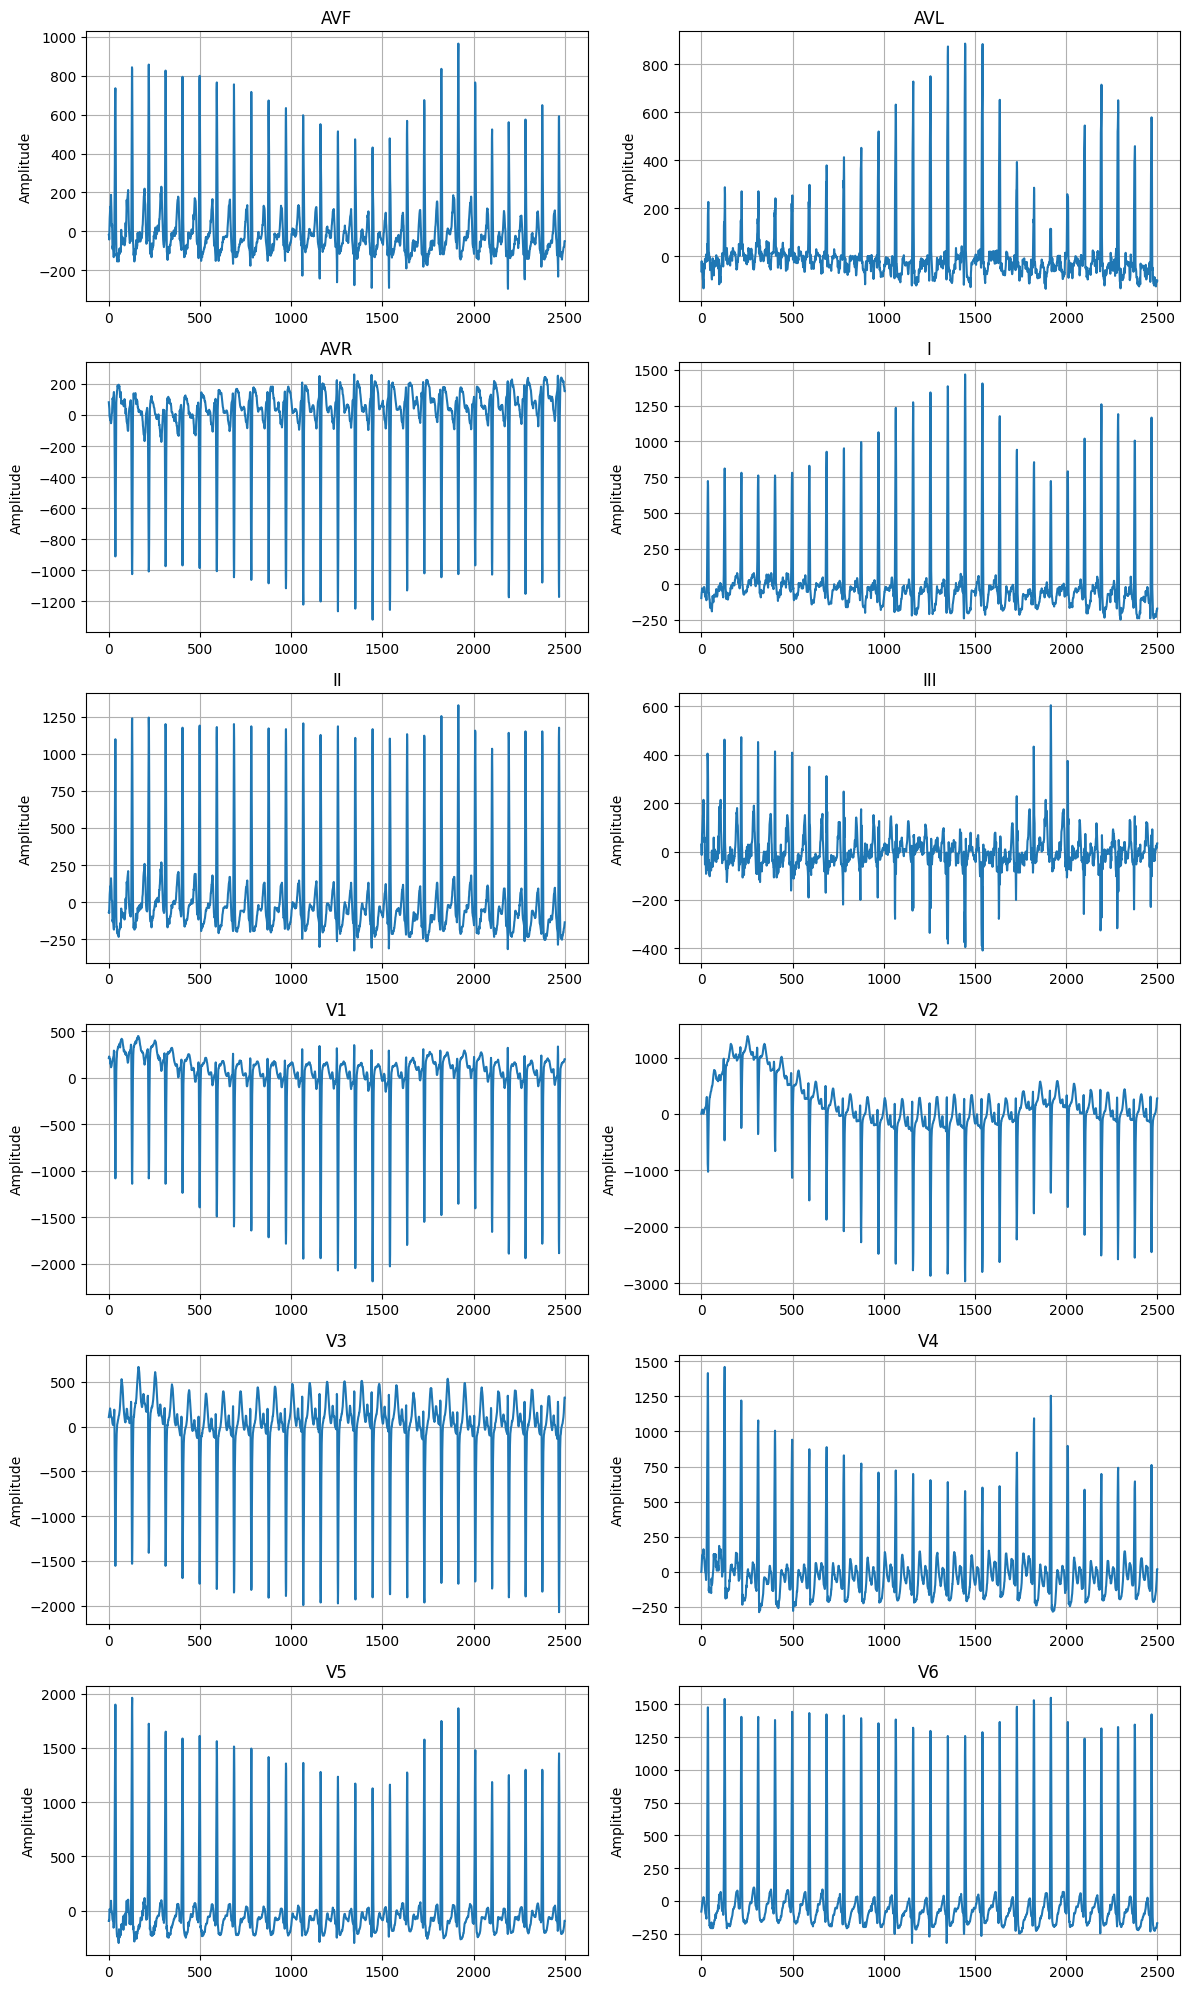

In [ ]:
def plot_waveforms(id):
  plt.figure(figsize=(12,20))

  # Get the x-axis values length of columns from one of the csv files
  x_values = np.arange(0, len(lead_dataframes[id]))

  # Get the amplitude values
  avf_waveform = lead_dataframes[id][' aVF']
  avl_waveform = lead_dataframes[id][' aVL']
  avr_waveform = lead_dataframes[id][' aVR']
  lead1_waveform = lead_dataframes[id]['I']
  lead2_waveform = lead_dataframes[id][' II']
  lead3_waveform = lead_dataframes[id][' III']
  v1_waveform = lead_dataframes[id][' V1']
  v2_waveform = lead_dataframes[id][' V2']
  v3_waveform = lead_dataframes[id][' V3']
  v4_waveform = lead_dataframes[id][' V4']
  v5_waveform = lead_dataframes[id][' V5']
  v6_waveform = lead_dataframes[id][' V6']

  # Plot each of the waveforms
  plt.subplot(6, 2, 1)
  plt.plot(x_values, avf_waveform)
  plt.title('AVF')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 2)
  plt.plot(x_values, avl_waveform)
  plt.title('AVL')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 3)
  plt.plot(x_values, avr_waveform)
  plt.title('AVR')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 4)
  plt.plot(x_values, lead1_waveform)
  plt.title('I')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 5)
  plt.plot(x_values, lead2_waveform)
  plt.title('II')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 6)
  plt.plot(x_values, lead3_waveform)
  plt.title('III')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 7)
  plt.plot(x_values, v1_waveform)
  plt.title('V1')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 8)
  plt.plot(x_values, v2_waveform)
  plt.title('V2')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 9)
  plt.plot(x_values, v3_waveform)
  plt.title('V3')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 10)
  plt.plot(x_values, v4_waveform)
  plt.title('V4')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 11)
  plt.plot(x_values, v5_waveform)
  plt.title('V5')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 12)
  plt.plot(x_values, v6_waveform)
  plt.title('V6')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.tight_layout()
  plt.show()

plot_waveforms("1674430")

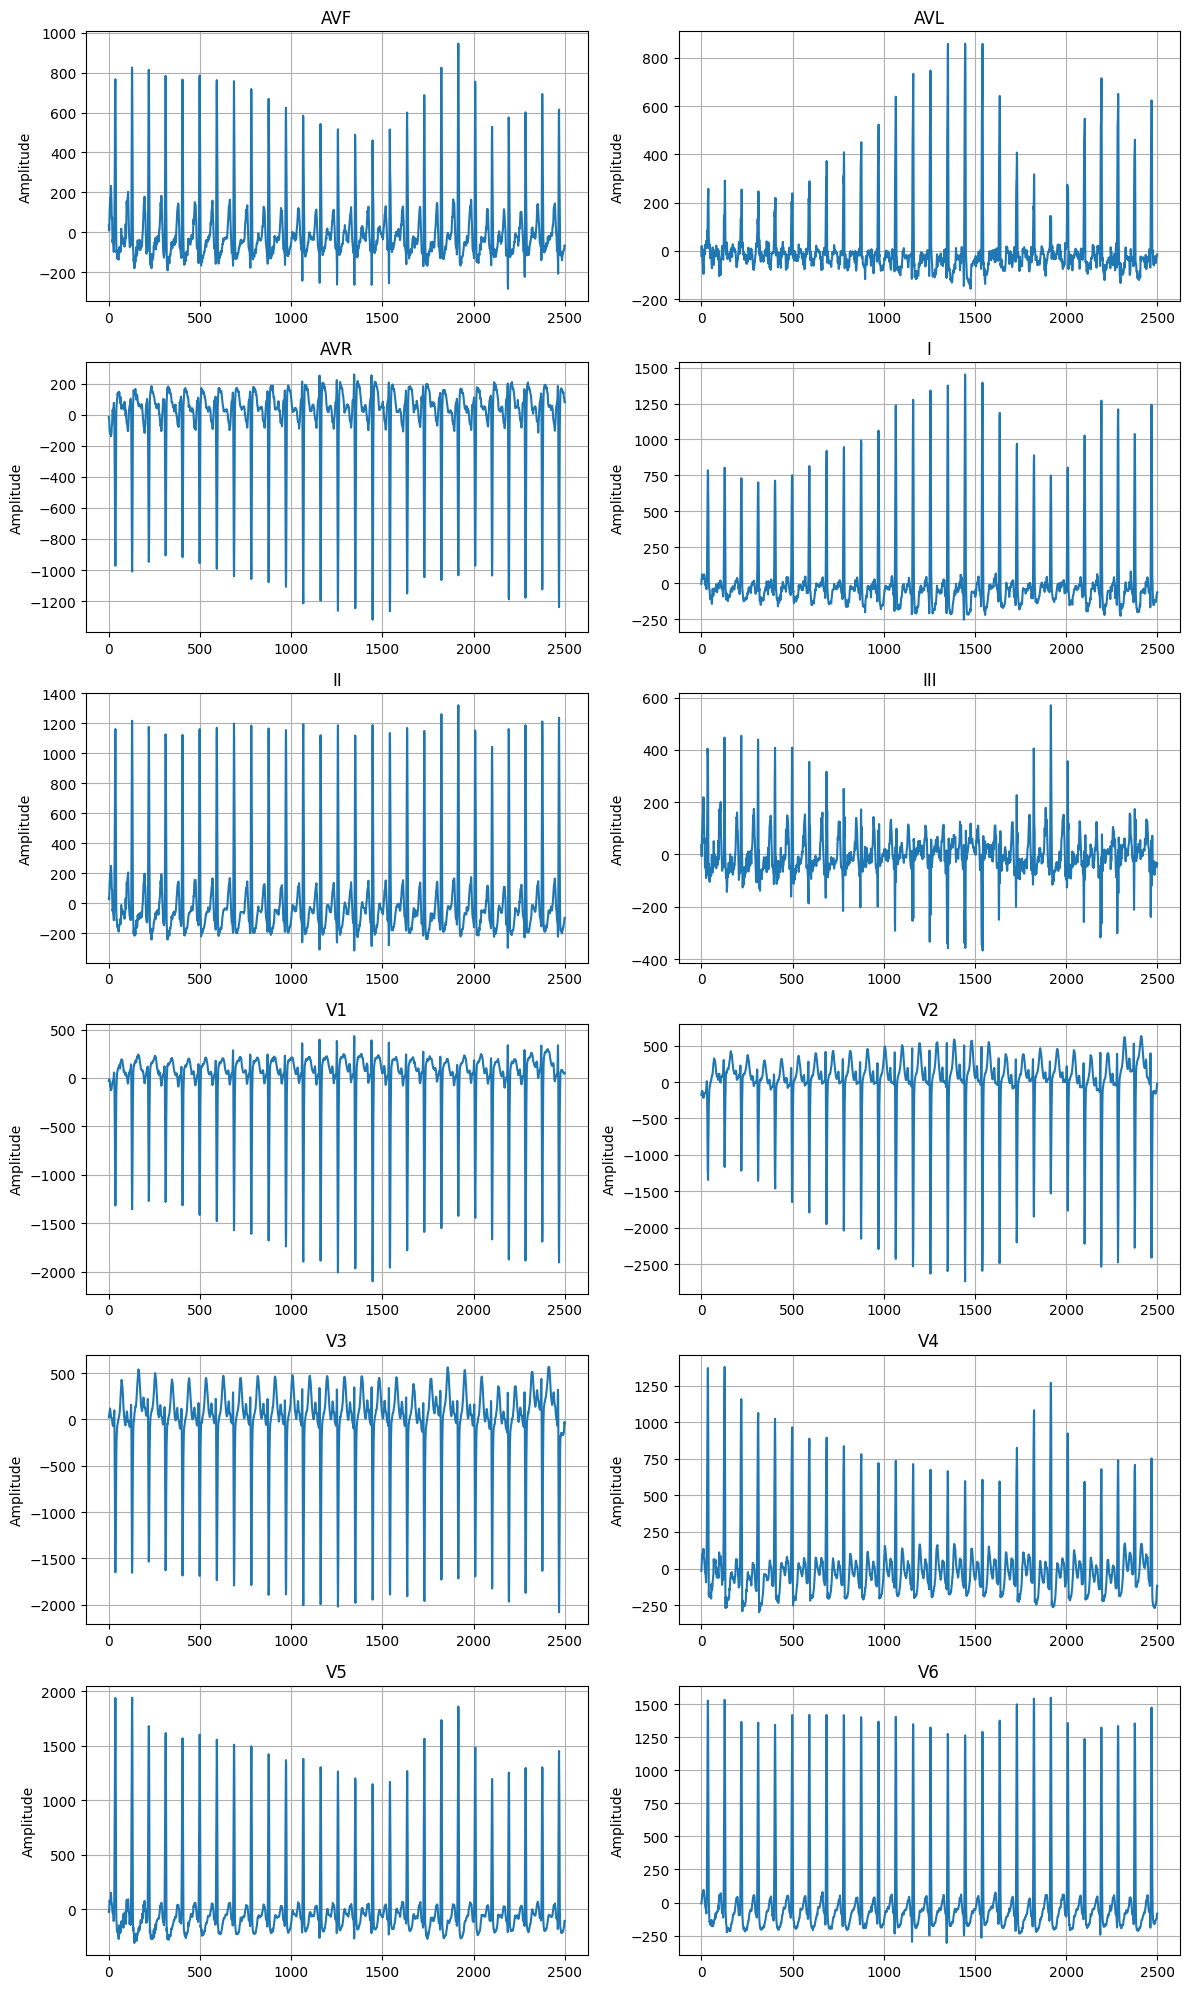

In [ ]:
def baseline_wander_filter(ecg_sample, sampling_frequency, filter_type="high_pass_filter"):

    if filter_type == "high_pass_filter":
        high_pass_filter = sp.butter(4, 0.5, btype='high', fs=sampling_frequency)
        filtered_ecg_data = sp.filtfilt(high_pass_filter[0], high_pass_filter[1], ecg_sample)
        return filtered_ecg_data
    elif filter_type == "baseline_removal":
        row,__ = ecg_sample.shape
        processed_data = np.zeros(ecg_sample.shape)
        for lead in range(0,row):
            # Baseline estimation
            win_size = int(np.round(0.2 * sampling_frequency)) + 1
            baseline = sp.medfilt(ecg_sample[lead,:], win_size)
            win_size = int(np.round(0.6 * sampling_frequency)) + 1
            baseline = sp.medfilt(baseline, win_size)
            # Removing baseline
            filt_data = ecg_sample[lead,:] - baseline
            processed_data[lead,:] = filt_data
        return processed_data

def pre_process_ecg_signal(ecg_sample, sampling_rate, baseline_wander_technique = "high_pass_filter"):
  return baseline_wander_filter(ecg_sample, sampling_rate, baseline_wander_technique)

def plot_waveforms_filtered(id):
  plt.figure(figsize=(12,20))

  avf_waveform = lead_dataframes[id][' aVF']
  avl_waveform = lead_dataframes[id][' aVL']
  avr_waveform = lead_dataframes[id][' aVR']
  lead1_waveform = lead_dataframes[id]['I']
  lead2_waveform = lead_dataframes[id][' II']
  lead3_waveform = lead_dataframes[id][' III']
  v1_waveform = lead_dataframes[id][' V1']
  v2_waveform = lead_dataframes[id][' V2']
  v3_waveform = lead_dataframes[id][' V3']
  v4_waveform = lead_dataframes[id][' V4']
  v5_waveform = lead_dataframes[id][' V5']
  v6_waveform = lead_dataframes[id][' V6']

  avf_filtered = pre_process_ecg_signal(avf_waveform, 250, "high_pass_filter")
  avl_filtered = pre_process_ecg_signal(avl_waveform, 250)
  avr_filtered = pre_process_ecg_signal(avr_waveform, 250)
  lead1_filtered = pre_process_ecg_signal(lead1_waveform, 250)
  lead2_filtered = pre_process_ecg_signal(lead2_waveform, 250)
  lead3_filtered = pre_process_ecg_signal(lead3_waveform, 250)
  v1_filtered = pre_process_ecg_signal(v1_waveform, 250)
  v2_filtered = pre_process_ecg_signal(v2_waveform, 250)
  v3_filtered = pre_process_ecg_signal(v3_waveform, 250)
  v4_filtered = pre_process_ecg_signal(v4_waveform, 250)
  v5_filtered = pre_process_ecg_signal(v5_waveform, 250)
  v6_filtered = pre_process_ecg_signal(v6_waveform, 250)

  # Get the x-axis values (row 0) from one of the csv files
  x_values = np.arange(0, len(avf_waveform))

  # Plot each of the waveforms
  plt.subplot(6, 2, 1)
  plt.plot(x_values, avf_filtered)
  plt.title('AVF')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 2)
  plt.plot(x_values, avl_filtered)
  plt.title('AVL')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 3)
  plt.plot(x_values, avr_filtered)
  plt.title('AVR')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 4)
  plt.plot(x_values, lead1_filtered)
  plt.title('I')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 5)
  plt.plot(x_values, lead2_filtered)
  plt.title('II')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 6)
  plt.plot(x_values, lead3_filtered)
  plt.title('III')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 7)
  plt.plot(x_values, v1_filtered)
  plt.title('V1')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 8)
  plt.plot(x_values, v2_filtered)
  plt.title('V2')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 9)
  plt.plot(x_values, v3_filtered)
  plt.title('V3')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 10)
  plt.plot(x_values, v4_filtered)
  plt.title('V4')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 11)
  plt.plot(x_values, v5_filtered)
  plt.title('V5')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.subplot(6, 2, 12)
  plt.plot(x_values, v6_filtered)
  plt.title('V6')
  plt.ylabel('Amplitude')
  plt.grid(True)

  plt.tight_layout()
  plt.show()

plot_waveforms_filtered('1674430')

## Test

In [ ]:
id = '1014508'
#sample_rate = 500
if len(lead_dataframes[id] == 2500):
  sample_rate = 250
else:
  sample_rate = 500

# Obtain the 12 waveforms for the current patient
avf_waveform = lead_dataframes[id][' aVF']
avl_waveform = lead_dataframes[id][' aVL']
avr_waveform = lead_dataframes[id][' aVR']
lead1_waveform = lead_dataframes[id]['I']
lead2_waveform = lead_dataframes[id][' II']
lead3_waveform = lead_dataframes[id][' III']

avf_waveform_filtered = pre_process_ecg_signal(avf_waveform, sample_rate)
avl_waveform_filtered = pre_process_ecg_signal(avl_waveform, sample_rate)
avr_waveform_filtered = pre_process_ecg_signal(avr_waveform, sample_rate)
lead1_waveform_filtered = pre_process_ecg_signal(lead1_waveform, sample_rate)
lead2_waveform_filtered = pre_process_ecg_signal(lead2_waveform, sample_rate)
lead3_waveform_filtered = pre_process_ecg_signal(lead3_waveform, sample_rate)

avf_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = avf_waveform_filtered, sampling_rate = sample_rate, method ='elgendi2010')
avl_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = avl_waveform_filtered, sampling_rate = sample_rate, method='biosppy')
avr_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = avr_waveform_filtered, sampling_rate = sample_rate, method='hamilton2002')
lead1_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = lead1_waveform_filtered, sampling_rate = sample_rate, method='hamilton2002')
lead2_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = lead2_waveform_filtered, sampling_rate = sample_rate, method='elgendi2010')
lead3_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = lead3_waveform_filtered, sampling_rate = sample_rate, method='hamilton2002')

_, avf_r_peaks2 = nk.ecg_peaks(ecg_cleaned = avf_waveform_cleaned_filtered, sampling_rate = sample_rate)
_, avl_r_peaks2 = nk.ecg_peaks(ecg_cleaned = avl_waveform_cleaned_filtered, sampling_rate = sample_rate)
_, avr_r_peaks2 = nk.ecg_peaks(ecg_cleaned = avr_waveform_cleaned_filtered, sampling_rate = sample_rate)
_, lead1_r_peaks2 = nk.ecg_peaks(ecg_cleaned = lead1_waveform_cleaned_filtered, sampling_rate = sample_rate)
_, lead2_r_peaks2 = nk.ecg_peaks(ecg_cleaned = lead2_waveform_cleaned_filtered, sampling_rate = sample_rate)
_, lead3_r_peaks2 = nk.ecg_peaks(ecg_cleaned = lead3_waveform_cleaned_filtered, sampling_rate = sample_rate)

_, avf_peaks2 = nk.ecg_delineate(ecg_cleaned = avf_waveform_cleaned_filtered, r_peaks = avf_r_peaks2, sampling_rate = sample_rate)
_, avl_peaks2 = nk.ecg_delineate(ecg_cleaned = avl_waveform_cleaned_filtered, r_peaks = avl_r_peaks2, sampling_rate = sample_rate)
_, avr_peaks2 = nk.ecg_delineate(ecg_cleaned = avr_waveform_cleaned_filtered, r_peaks = avr_r_peaks2, sampling_rate = sample_rate)
_, lead1_peaks2 = nk.ecg_delineate(ecg_cleaned = lead1_waveform_cleaned_filtered, r_peaks = lead1_r_peaks2, sampling_rate = sample_rate)
_, lead2_peaks2 = nk.ecg_delineate(ecg_cleaned = lead2_waveform_cleaned_filtered, r_peaks = lead2_r_peaks2, sampling_rate = sample_rate)
_, lead3_peaks2 = nk.ecg_delineate(ecg_cleaned = lead3_waveform_cleaned_filtered, r_peaks = lead3_r_peaks2, sampling_rate = sample_rate)

avf_r_onsets = np.array(avf_peaks2['ECG_R_Onsets'])
avf_r_offsets = np.array(avf_peaks2['ECG_R_Offsets'])
avf_r_net = 0
for i in range(0, len(avf_r_offsets)):
  if np.isnan(avf_r_onsets[i]) or np.isnan(avf_r_offsets[i]):
      continue
  avf_r_amps = avf_waveform_cleaned_filtered[int(avf_r_onsets[i]):int(avf_r_offsets[i])]
  avf_r_net += np.sum(avf_r_amps)

avf_t_onsets = np.array(avf_peaks2['ECG_T_Onsets'])
avf_t_offsets = np.array(avf_peaks2['ECG_T_Offsets'])
avf_t_net = 0
for i in range(0, len(avf_t_offsets)):
  if np.isnan(avf_t_onsets[i]) or np.isnan(avf_t_offsets[i]):
    continue
  avf_t_amps = avl_waveform_cleaned_filtered[int(avf_t_onsets[i]):int(avf_t_offsets[i])]
  avf_t_net += np.sum(avf_t_amps)


avl_r_onsets = np.array(avl_peaks2['ECG_R_Onsets'])
avl_r_offsets = np.array(avl_peaks2['ECG_R_Offsets'])
avl_r_net = 0
for i in range(0, len(avl_r_offsets)):
  if np.isnan(avl_r_onsets[i]) or np.isnan(avl_r_offsets[i]):
      continue
  avl_r_amps = avl_waveform_cleaned_filtered[int(avl_r_onsets[i]):int(avl_r_offsets[i])]
  avl_r_net += np.sum(avl_r_amps)

avl_t_onsets = np.array(avl_peaks2['ECG_T_Onsets'])
avl_t_offsets = np.array(avl_peaks2['ECG_T_Offsets'])
avl_t_net = 0
for i in range(0, len(avl_t_offsets)):
  if np.isnan(avl_t_onsets[i]) or np.isnan(avl_t_offsets[i]):
    continue
  avl_t_amps = lead3_waveform_cleaned_filtered[int(avl_t_onsets[i]):int(avl_t_offsets[i])]
  avl_t_net += np.sum(avl_t_amps)


avr_r_onsets = np.array(avr_peaks2['ECG_R_Onsets'])
avr_r_offsets = np.array(avr_peaks2['ECG_R_Offsets'])
avr_r_net = 0
for i in range(0, len(avr_r_offsets)):
  if np.isnan(avr_r_onsets[i]) or np.isnan(avr_r_offsets[i]):
      continue
  avr_r_amps = avr_waveform_cleaned_filtered[int(avr_r_onsets[i]):int(avr_r_offsets[i])]
  avr_r_net += np.sum(avr_r_amps)

avr_t_onsets = np.array(avr_peaks2['ECG_T_Onsets'])
avr_t_offsets = np.array(avr_peaks2['ECG_T_Offsets'])
avr_t_net = 0
for i in range(0, len(avr_t_offsets)):
  if np.isnan(avr_t_onsets[i]) or np.isnan(avr_t_offsets[i]):
    continue
  avr_t_amps = lead3_waveform_cleaned_filtered[int(avr_t_onsets[i]):int(avr_t_offsets[i])]
  avr_t_net += np.sum(avr_t_amps)


lead1_r_onsets = np.array(lead1_peaks2['ECG_R_Onsets'])
lead1_r_offsets = np.array(lead1_peaks2['ECG_R_Offsets'])
lead1_r_net = 0
for i in range(0, len(lead1_r_offsets)):
  if np.isnan(lead1_r_onsets[i]) or np.isnan(lead1_r_offsets[i]):
      continue
  lead1_r_amps = lead1_waveform_cleaned_filtered[int(lead1_r_onsets[i]):int(lead1_r_offsets[i])]
  lead1_r_net += np.sum(lead1_r_amps)

lead1_t_onsets = np.array(lead1_peaks2['ECG_T_Onsets'])
lead1_t_offsets = np.array(lead1_peaks2['ECG_T_Offsets'])
lead1_t_net = 0
for i in range(0, len(lead1_t_offsets)):
  if np.isnan(lead1_t_onsets[i]) or np.isnan(lead1_t_offsets[i]):
    continue
  lead1_t_amps = lead3_waveform_cleaned_filtered[int(lead1_t_onsets[i]):int(lead1_t_offsets[i])]
  lead1_t_net += np.sum(lead1_t_amps)


lead2_r_onsets = np.array(lead2_peaks2['ECG_R_Onsets'])
lead2_r_offsets = np.array(lead2_peaks2['ECG_R_Offsets'])
lead2_r_net = 0
for i in range(0, len(lead2_r_offsets)):
  if np.isnan(lead2_r_onsets[i]) or np.isnan(lead2_r_offsets[i]):
      continue
  lead2_r_amps = lead2_waveform_cleaned_filtered[int(lead2_r_onsets[i]):int(lead2_r_offsets[i])]
  lead2_r_net += np.sum(lead2_r_amps)

lead2_t_onsets = np.array(lead2_peaks2['ECG_T_Onsets'])
lead2_t_offsets = np.array(lead2_peaks2['ECG_T_Offsets'])
lead2_t_net = 0
for i in range(0, len(lead2_t_offsets)):
  if np.isnan(lead2_t_onsets[i]) or np.isnan(lead2_t_offsets[i]):
    continue
  lead2_t_amps = lead3_waveform_cleaned_filtered[int(lead2_t_onsets[i]):int(lead2_t_offsets[i])]
  lead2_t_net += np.sum(lead2_t_amps)


lead3_r_onsets = np.array(lead3_peaks2['ECG_R_Onsets'])
lead3_r_offsets = np.array(lead3_peaks2['ECG_R_Offsets'])
lead3_r_net = 0
for i in range(0, len(lead3_r_offsets)):
  if np.isnan(lead3_r_onsets[i]) or np.isnan(lead3_r_offsets[i]):
      continue
  lead3_r_amps = lead3_waveform_cleaned_filtered[int(lead3_r_onsets[i]):int(lead3_r_offsets[i])]
  lead3_r_net += np.sum(lead3_r_amps)

lead3_t_onsets = np.array(lead3_peaks2['ECG_T_Onsets'])
lead3_t_offsets = np.array(lead3_peaks2['ECG_T_Offsets'])
lead3_t_net = 0
for i in range(0, len(lead3_t_offsets)):
  if np.isnan(lead3_t_onsets[i]) or np.isnan(lead3_t_offsets[i]):
    continue
  lead3_t_amps = lead3_waveform_cleaned_filtered[int(lead3_t_onsets[i]):int(lead3_t_offsets[i])]
  lead3_t_net += np.sum(lead3_t_amps)


# get absolute value to prepare for comparison
avf_qrs_abs = abs(avf_r_net)
avl_qrs_abs = abs(avl_r_net)
avr_qrs_abs = abs(avr_r_net)
lead1_qrs_abs = abs(lead1_r_net)
lead2_qrs_abs = abs(lead2_r_net)
lead3_qrs_abs = abs(lead3_r_net)

avf_t_abs = abs(avf_t_net)
avl_t_abs = abs(avl_t_net)
avr_t_abs = abs(avr_t_net)
lead1_t_abs = abs(lead1_t_net)
lead2_t_abs = abs(lead2_t_net)
lead3_t_abs = abs(lead3_t_net)

isoelectric_qrs = min(avf_qrs_abs, avl_qrs_abs, avr_qrs_abs, lead1_qrs_abs,
                      lead2_qrs_abs, lead3_qrs_abs)

isoelectric_t = min(avf_t_abs, avl_t_abs, avr_t_abs, lead1_t_abs, lead2_t_abs,
                    lead3_t_abs)

# going to use perpendicular pairs to determine if +90 or -90
if (isoelectric_qrs == avf_qrs_abs):
  if (lead1_r_net < 0):
    qrs_axis = 180
  else:
    qrs_axis = 0
elif (isoelectric_qrs == avl_qrs_abs):
  if (lead2_r_net < 0):
    qrs_axis = -120
  else:
    qrs_axis = 60
elif (isoelectric_qrs == avr_qrs_abs):
  if (lead3_r_net < 0):
    qrs_axis = -60
  else:
    qrs_axis = 120
elif (isoelectric_qrs == lead1_qrs_abs):
  if (avf_r_net < 0):
    qrs_axis = -90
  else:
    qrs_axis = 90
elif (isoelectric_qrs == lead2_qrs_abs):
  if (avl_r_net < 0):
    qrs_axis = 150
  else:
    qrs_axis = -30
else:
  if (avr_r_net < 0):
    qrs_axis = 30
  else:
    qrs_axis = -150

if (isoelectric_t == avf_t_abs):
  if (lead1_r_net < 0):
    t_axis = 180
  else:
    t_axis = 0
elif (isoelectric_t == avl_t_abs):
  if (lead2_r_net < 0):
    t_axis = -120
  else:
    t_axis = 60
elif (isoelectric_t == avr_t_abs):
  if (lead3_r_net < 0):
    t_axis = -60
  else:
    t_axis = 120
elif (isoelectric_t == lead1_t_abs):
  if (avf_r_net < 0):
    t_axis = -90
  else:
    t_axis = 90
elif (isoelectric_t == lead2_t_abs):
  if (avl_r_net < 0):
    t_axis = 150
  else:
    t_axis = -30
else:
  if (avr_r_net < 0):
    t_axis = 30
  else:
    t_axis = -150

print(avf_r_net)
print(avr_r_net)
print(avl_r_net)
print(lead1_r_net)
print(lead2_r_net)
print(lead3_r_net)
print(isoelectric_qrs)
print(qrs_axis)
print(avf_t_net)
print(avr_t_net)
print(avl_t_net)
print(lead1_t_net)
print(lead2_t_net)
print(lead3_t_net)
print(isoelectric_t)
print(t_axis)

-881.0459584850789
-3533.3958386843574
7897.777596720408
-1387.2122874287302
0
779.8628865655397
0
-30
-499.70994967766774
99.75878638209834
-140.86375005388197
-82.04511838280153
-138.12758124197666
-339.3990500148826
82.04511838280153
-90


In [ ]:
sample_rate = 500
v3_waveform = lead_dataframes['1014507'][' V3']
v3_waveform_filtered = pre_process_ecg_signal(v3_waveform, sample_rate)
v3_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = v3_waveform_filtered, sampling_rate = sample_rate, method='elgendi2010')
_, v3_r_peaks2 = nk.ecg_peaks(ecg_cleaned = v3_waveform_cleaned_filtered, sampling_rate = sample_rate)
_, v3_peaks2 = nk.ecg_delineate(ecg_cleaned = v3_waveform_cleaned_filtered, r_peaks = v3_r_peaks2, sampling_rate = sample_rate)

v3_p_offsets2 = np.array(v3_peaks2['ECG_P_Offsets'])
v3_r_onsets2 = np.array(v3_peaks2['ECG_R_Onsets'])
v3_r_offsets2 = np.array(v3_peaks2['ECG_R_Offsets'])
v3_t_onsets2 = np.array(v3_peaks2['ECG_T_Onsets'])
#v3_valid_mask = ~np.isnan(v3_p_offsets2) & ~np.isnan(v3_r_onsets2) & ~np.isnan(v3_r_offsets2) & ~np.isnan(v3_t_onsets2)
#v3_p_offsets2 = v3_p_offsets2[v3_valid_mask]
#v3_r_onsets2 = v3_r_onsets2[v3_valid_mask]
#v3_r_offsets2 = v3_r_offsets2[v3_valid_mask]
#v3_t_onsets2 = v3_t_onsets2[v3_valid_mask]
v3_pr_midpoints = ((v3_p_offsets2 + v3_r_onsets2) // 2).astype(int)
v3_st_midpoints = ((v3_r_offsets2 + v3_t_onsets2) // 2).astype(int)
print()
"""v3_pr_amplitudes = v3_waveform_filtered[v3_pr_midpoints]
v3_st_amplitudes = v3_waveform_filtered[v3_st_midpoints]
v3_differentials = v3_st_amplitudes - v3_pr_amplitudes
v3_elevation = 0
v3_depression = 0
v3_threshold = len(v3_differentials) / 2
v3_above_200 = np.sum(v3_differentials > 200)
v3_below_neg_50 = np.sum(v3_differentials < -50)
if v3_above_200 > v3_threshold:
  v3_elevation = 1
elif v3_below_neg_50 > v3_threshold:
  v3_depression = 1
avg_v3_diff = np.nanmean(v3_differentials)
med_v3_diff = np.nanmedian(v3_differentials)
#max_v3_diff = np.nanmax(v3_differentials)
#min_v3_diff = np.nanmin(v3_differentials)"""

[  nan   nan  726.   nan 1088.   nan   nan 1649.   nan 2029.   nan 2408.]


'v3_pr_amplitudes = v3_waveform_filtered[v3_pr_midpoints]\nv3_st_amplitudes = v3_waveform_filtered[v3_st_midpoints]\nv3_differentials = v3_st_amplitudes - v3_pr_amplitudes\nv3_elevation = 0\nv3_depression = 0\nv3_threshold = len(v3_differentials) / 2\nv3_above_200 = np.sum(v3_differentials > 200)\nv3_below_neg_50 = np.sum(v3_differentials < -50)\nif v3_above_200 > v3_threshold:\n  v3_elevation = 1\nelif v3_below_neg_50 > v3_threshold:\n  v3_depression = 1\navg_v3_diff = np.nanmean(v3_differentials)\nmed_v3_diff = np.nanmedian(v3_differentials)\n#max_v3_diff = np.nanmax(v3_differentials)\n#min_v3_diff = np.nanmin(v3_differentials)'

## Featurization


*   Pmax, Pmin, Pwave Dispersion
*   QT Dispersion
*   Tp-e Interval
*   Tp-e/QT and Tp-e/QTc
*   ST-T Abnormalities
*   QRS and T axes
*   Frontal QRS-T Angle





In [3]:
drop_list = ['1520898', '1562170', '1200137', '1674430', '1797535', '2024217',
             '2114643', '1013718', '1015135', '1084709', '1118297', '1156235',
             '1235691', '1235692', '1235693', '1291135', '1369585', '1370402',
             '1462210', '1462211', '1483898', '1602676', '1635945', '1635946',
             '1709758', '1765763', '1933991', '2010841', '2084217', '2104025',
             '2186303', '2201365']

for key in drop_list:
    lead_dataframes.pop(key, None)
    lead_dataframes2.pop(key, None)

"""
Balanced + Unbalanced               6P/1N dropped
1520898: V5 -> 0's                       P
1562170: V6 -> 0's                       P
1200137: V6 -> Differentials empty       N
1674430: V3 -> Differentials empty       P
1797535: V3 -> Differentials empty       P
2024217: V5 -> Differentials empty       P
2114643: V6 -> Differentials empty       P

Unbalanced                           2P/23N dropped
1013718: V6 -> Differentials empty       N
1015135: V6 -> Differentials empty       N
1084709: V3 -> Differentials empty       N
1118297: V2 -> Differentials empty       N
1156235: V3 -> Differentials empty       N
1235691: V3 -> Differentials empty       N
1235692: V3 -> Differentials empty       N
1235693: V3 -> Differentials empty       N
1291135: V5 -> Failed delineation        N
1369585: V6 -> Failed delineation        N
1370402: V6 -> Failed delineation        N
1462210: V5 -> Differentials empty       P
1462211: V5 -> Differentials empty       P
1483898: V4 -> Failed delineation        N
1602676: V5 -> Differentials empty       N
1635945: V3 -> Differentials empty       N
1635946: V3 -> Differentials empty       N
1709758: V3 -> Differentials empty       N
1765763: V3 -> Failed delineation        N
1933991: V2 -> Differentials empty       N
2010841: V3 -> Differentials empty       N
2084217: V5 -> Differentials empty       N
2104025: V3 -> Differentials empty       N
2186303: V5 -> Differentials empty       N
2201365: V4 -> Failed delineation        N

"""

"\nBalanced + Unbalanced               6P/1N dropped\n1520898: V5 -> 0's                       P\n1562170: V6 -> 0's                       P\n1200137: V6 -> Differentials empty       N\n1674430: V3 -> Differentials empty       P\n1797535: V3 -> Differentials empty       P\n2024217: V5 -> Differentials empty       P\n2114643: V6 -> Differentials empty       P\n\nUnbalanced                           2P/23N dropped\n1013718: V6 -> Differentials empty       N\n1015135: V6 -> Differentials empty       N\n1084709: V3 -> Differentials empty       N\n1118297: V2 -> Differentials empty       N\n1156235: V3 -> Differentials empty       N\n1235691: V3 -> Differentials empty       N\n1235692: V3 -> Differentials empty       N\n1235693: V3 -> Differentials empty       N\n1291135: V5 -> Failed delineation        N\n1369585: V6 -> Failed delineation        N\n1370402: V6 -> Failed delineation        N\n1462210: V5 -> Differentials empty       P\n1462211: V5 -> Differentials empty       P\n1483898: V4

### Balanced Featurization

In [ ]:
features = []

for id, df in lead_dataframes.items():
  patient_features = {}
  #sample_rate = 500
  if len(lead_dataframes[id]) == 2500:
    sample_rate = 250
  else:
    sample_rate = 500

  # Obtain the 12 waveforms for the current patient
  avf_waveform = lead_dataframes[id][' aVF']
  avl_waveform = lead_dataframes[id][' aVL']
  avr_waveform = lead_dataframes[id][' aVR']
  lead1_waveform = lead_dataframes[id]['I']
  lead2_waveform = lead_dataframes[id][' II']
  lead3_waveform = lead_dataframes[id][' III']
  v1_waveform = lead_dataframes[id][' V1']
  v2_waveform = lead_dataframes[id][' V2']
  v3_waveform = lead_dataframes[id][' V3']
  v4_waveform = lead_dataframes[id][' V4']
  v5_waveform = lead_dataframes[id][' V5']
  v6_waveform = lead_dataframes[id][' V6']

  avf_waveform_filtered = pre_process_ecg_signal(avf_waveform, sample_rate)
  avl_waveform_filtered = pre_process_ecg_signal(avl_waveform, sample_rate)
  avr_waveform_filtered = pre_process_ecg_signal(avr_waveform, sample_rate)
  lead1_waveform_filtered = pre_process_ecg_signal(lead1_waveform, sample_rate)
  lead2_waveform_filtered = pre_process_ecg_signal(lead2_waveform, sample_rate)
  lead3_waveform_filtered = pre_process_ecg_signal(lead3_waveform, sample_rate)
  v1_waveform_filtered = pre_process_ecg_signal(v1_waveform, sample_rate)
  v2_waveform_filtered = pre_process_ecg_signal(v2_waveform, sample_rate)
  v3_waveform_filtered = pre_process_ecg_signal(v3_waveform, sample_rate)
  v4_waveform_filtered = pre_process_ecg_signal(v4_waveform, sample_rate)
  v5_waveform_filtered = pre_process_ecg_signal(v5_waveform, sample_rate)
  v6_waveform_filtered = pre_process_ecg_signal(v6_waveform, sample_rate)

  avf_waveform_cleaned = nk.ecg_clean(ecg_signal = avf_waveform, sampling_rate = sample_rate, method='vg')
  avl_waveform_cleaned = nk.ecg_clean(ecg_signal = avl_waveform, sampling_rate = sample_rate, method='elgendi2010')
  avr_waveform_cleaned = nk.ecg_clean(ecg_signal = avr_waveform, sampling_rate = sample_rate, method='hamilton2002')
  lead1_waveform_cleaned = nk.ecg_clean(ecg_signal = lead1_waveform, sampling_rate = sample_rate, method='elgendi2010')
  lead2_waveform_cleaned = nk.ecg_clean(ecg_signal = lead2_waveform, sampling_rate = sample_rate, method='vg')
  lead3_waveform_cleaned = nk.ecg_clean(ecg_signal = lead3_waveform, sampling_rate = sample_rate, method='hamilton2002')
  v1_waveform_cleaned = nk.ecg_clean(ecg_signal = v1_waveform, sampling_rate = sample_rate, method='hamilton2002')
  v2_waveform_cleaned = nk.ecg_clean(ecg_signal = v2_waveform, sampling_rate = sample_rate, method='elgendi2010')
  v3_waveform_cleaned = nk.ecg_clean(ecg_signal = v3_waveform, sampling_rate = sample_rate, method='elgendi2010')
  v4_waveform_cleaned = nk.ecg_clean(ecg_signal = v4_waveform, sampling_rate = sample_rate, method='vg')
  v5_waveform_cleaned = nk.ecg_clean(ecg_signal = v5_waveform, sampling_rate = sample_rate, method='biosppy')
  v6_waveform_cleaned = nk.ecg_clean(ecg_signal = v6_waveform, sampling_rate = sample_rate, method='biosppy')

  avf_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = avf_waveform_filtered, sampling_rate = sample_rate, method ='vg')
  avl_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = avl_waveform_filtered, sampling_rate = sample_rate, method='elgendi2010')
  avr_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = avr_waveform_filtered, sampling_rate = sample_rate, method='hamilton2002')
  lead1_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = lead1_waveform_filtered, sampling_rate = sample_rate, method='elgendi2010')
  lead2_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = lead2_waveform_filtered, sampling_rate = sample_rate, method='vg')
  lead3_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = lead3_waveform_filtered, sampling_rate = sample_rate, method='hamilton2002')
  v1_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = v1_waveform_filtered, sampling_rate = sample_rate, method='hamilton2002')
  v2_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = v2_waveform_filtered, sampling_rate = sample_rate, method='elgendi2010')
  v3_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = v3_waveform_filtered, sampling_rate = sample_rate, method='elgendi2010')
  v4_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = v4_waveform_filtered, sampling_rate = sample_rate, method='vg')
  v5_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = v5_waveform_filtered, sampling_rate = sample_rate, method='biosppy')
  v6_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = v6_waveform_filtered, sampling_rate = sample_rate, method='biosppy')

  _, avf_r_peaks = nk.ecg_peaks(ecg_cleaned = avf_waveform_cleaned, sampling_rate = sample_rate)
  _, avl_r_peaks = nk.ecg_peaks(ecg_cleaned = avl_waveform_cleaned, sampling_rate = sample_rate)
  _, avr_r_peaks= nk.ecg_peaks(ecg_cleaned = avr_waveform_cleaned, sampling_rate = sample_rate)
  _, lead1_r_peaks = nk.ecg_peaks(ecg_cleaned = lead1_waveform_cleaned, sampling_rate = sample_rate)
  _, lead2_r_peaks = nk.ecg_peaks(ecg_cleaned = lead2_waveform_cleaned, sampling_rate = sample_rate)
  _, lead3_r_peaks = nk.ecg_peaks(ecg_cleaned = lead3_waveform_cleaned, sampling_rate = sample_rate)
  _, v1_r_peaks = nk.ecg_peaks(ecg_cleaned = v1_waveform_cleaned, sampling_rate = sample_rate)
  _, v2_r_peaks = nk.ecg_peaks(ecg_cleaned = v2_waveform_cleaned, sampling_rate = sample_rate)
  _, v3_r_peaks = nk.ecg_peaks(ecg_cleaned = v3_waveform_cleaned, sampling_rate = sample_rate)
  _, v4_r_peaks = nk.ecg_peaks(ecg_cleaned = v4_waveform_cleaned, sampling_rate = sample_rate)
  _, v5_r_peaks = nk.ecg_peaks(ecg_cleaned = v5_waveform_cleaned, sampling_rate = sample_rate)
  _, v6_r_peaks = nk.ecg_peaks(ecg_cleaned = v6_waveform_cleaned, sampling_rate = sample_rate)

  _, avf_r_peaks2 = nk.ecg_peaks(ecg_cleaned = avf_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, avl_r_peaks2 = nk.ecg_peaks(ecg_cleaned = avl_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, avr_r_peaks2 = nk.ecg_peaks(ecg_cleaned = avr_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, lead1_r_peaks2 = nk.ecg_peaks(ecg_cleaned = lead1_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, lead2_r_peaks2 = nk.ecg_peaks(ecg_cleaned = lead2_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, lead3_r_peaks2 = nk.ecg_peaks(ecg_cleaned = lead3_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, v1_r_peaks2 = nk.ecg_peaks(ecg_cleaned = v1_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, v2_r_peaks2 = nk.ecg_peaks(ecg_cleaned = v2_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, v3_r_peaks2 = nk.ecg_peaks(ecg_cleaned = v3_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, v4_r_peaks2 = nk.ecg_peaks(ecg_cleaned = v4_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, v5_r_peaks2 = nk.ecg_peaks(ecg_cleaned = v5_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, v6_r_peaks2 = nk.ecg_peaks(ecg_cleaned = v6_waveform_cleaned_filtered, sampling_rate = sample_rate)

  _, avf_peaks = nk.ecg_delineate(ecg_cleaned = avf_waveform_cleaned, r_peaks = avf_r_peaks, sampling_rate = sample_rate)
  _, avl_peaks = nk.ecg_delineate(ecg_cleaned = avl_waveform_cleaned, r_peaks = avl_r_peaks, sampling_rate = sample_rate)
  _, avr_peaks = nk.ecg_delineate(ecg_cleaned = avr_waveform_cleaned, r_peaks = avr_r_peaks, sampling_rate = sample_rate)
  _, lead1_peaks = nk.ecg_delineate(ecg_cleaned = lead1_waveform_cleaned, r_peaks = lead1_r_peaks, sampling_rate = sample_rate)
  _, lead2_peaks = nk.ecg_delineate(ecg_cleaned = lead2_waveform_cleaned, r_peaks = lead2_r_peaks, sampling_rate = sample_rate)
  _, lead3_peaks = nk.ecg_delineate(ecg_cleaned = lead3_waveform_cleaned, r_peaks = lead3_r_peaks, sampling_rate = sample_rate)
  _, v1_peaks = nk.ecg_delineate(ecg_cleaned = v1_waveform_cleaned, r_peaks = v1_r_peaks, sampling_rate = sample_rate)
  _, v2_peaks = nk.ecg_delineate(ecg_cleaned = v2_waveform_cleaned, r_peaks = v2_r_peaks, sampling_rate = sample_rate)
  _, v3_peaks = nk.ecg_delineate(ecg_cleaned = v3_waveform_cleaned, r_peaks = v3_r_peaks, sampling_rate = sample_rate)
  _, v4_peaks = nk.ecg_delineate(ecg_cleaned = v4_waveform_cleaned, r_peaks = v4_r_peaks, sampling_rate = sample_rate)
  _, v5_peaks = nk.ecg_delineate(ecg_cleaned = v5_waveform_cleaned, r_peaks = v5_r_peaks, sampling_rate = sample_rate)
  _, v6_peaks = nk.ecg_delineate(ecg_cleaned = v6_waveform_cleaned, r_peaks = v6_r_peaks, sampling_rate = sample_rate)

  _, avf_peaks2 = nk.ecg_delineate(ecg_cleaned = avf_waveform_cleaned_filtered, r_peaks = avf_r_peaks2, sampling_rate = sample_rate)
  _, avl_peaks2 = nk.ecg_delineate(ecg_cleaned = avl_waveform_cleaned_filtered, r_peaks = avl_r_peaks2, sampling_rate = sample_rate)
  _, avr_peaks2 = nk.ecg_delineate(ecg_cleaned = avr_waveform_cleaned_filtered, r_peaks = avr_r_peaks2, sampling_rate = sample_rate)
  _, lead1_peaks2 = nk.ecg_delineate(ecg_cleaned = lead1_waveform_cleaned_filtered, r_peaks = lead1_r_peaks2, sampling_rate = sample_rate)
  _, lead2_peaks2 = nk.ecg_delineate(ecg_cleaned = lead2_waveform_cleaned_filtered, r_peaks = lead2_r_peaks2, sampling_rate = sample_rate)
  _, lead3_peaks2 = nk.ecg_delineate(ecg_cleaned = lead3_waveform_cleaned_filtered, r_peaks = lead3_r_peaks2, sampling_rate = sample_rate)
  _, v1_peaks2 = nk.ecg_delineate(ecg_cleaned = v1_waveform_cleaned_filtered, r_peaks = v1_r_peaks2, sampling_rate = sample_rate)
  _, v2_peaks2 = nk.ecg_delineate(ecg_cleaned = v2_waveform_cleaned_filtered, r_peaks = v2_r_peaks2, sampling_rate = sample_rate)
  _, v3_peaks2 = nk.ecg_delineate(ecg_cleaned = v3_waveform_cleaned_filtered, r_peaks = v3_r_peaks2, sampling_rate = sample_rate)
  _, v4_peaks2 = nk.ecg_delineate(ecg_cleaned = v4_waveform_cleaned_filtered, r_peaks = v4_r_peaks2, sampling_rate = sample_rate)
  _, v5_peaks2 = nk.ecg_delineate(ecg_cleaned = v5_waveform_cleaned_filtered, r_peaks = v5_r_peaks2, sampling_rate = sample_rate)
  _, v6_peaks2 = nk.ecg_delineate(ecg_cleaned = v6_waveform_cleaned_filtered, r_peaks = v6_r_peaks2, sampling_rate = sample_rate)

  # AVF
  avf_p_peaks = np.array(avf_peaks['ECG_P_Peaks'])
  avf_p_onsets = np.array(avf_peaks['ECG_P_Onsets'])
  avf_p_offsets = np.array(avf_peaks['ECG_P_Offsets'])
  avf_p_duration = (avf_p_offsets - avf_p_onsets) * 1/sample_rate   # in seconds
  avf_max_p_duration = np.nanmax(avf_p_duration)
  avf_min_p_duration = np.nanmin(avf_p_duration)

  avf_r_onsets = np.array(avf_peaks['ECG_R_Onsets'])
  avf_t_offsets = np.array(avf_peaks['ECG_T_Offsets'])
  avf_qt_duration = (avf_t_offsets - avf_r_onsets) * 1/sample_rate
  avf_max_qt_duration = np.nanmax(avf_qt_duration)
  avf_min_qt_duration = np.nanmin(avf_qt_duration)

  avf_t_peaks = np.array(avf_peaks['ECG_T_Peaks'])
  avf_t_offsets = np.array(avf_peaks['ECG_T_Offsets'])
  avf_tpe_duration = np.nanmean(avf_t_offsets - avf_t_peaks) * 1/sample_rate

  avf_tpe_qt = avf_tpe_duration / np.nanmean(avf_qt_duration)
  avf_r_peaks_list = np.array(avf_r_peaks['ECG_R_Peaks'])
  avf_r_peaks_diff = np.diff(avf_r_peaks_list) * 1/sample_rate
  avf_r_peaks_mean = np.nanmean(avf_r_peaks_diff)
  avf_r_peaks_sqrt = np.sqrt(avf_r_peaks_mean)
  avf_tpe_qtc = avf_tpe_qt * avf_r_peaks_sqrt

  avf_r_onsets2 = np.array(avf_peaks2['ECG_R_Onsets'])
  avf_r_offsets2 = np.array(avf_peaks2['ECG_R_Offsets'])
  avf_r_net = 0
  for i in range(0, len(avf_r_offsets2)):
    if np.isnan(avf_r_onsets2[i]) or np.isnan(avf_r_offsets2[i]):
        continue
    avf_r_amps = avf_waveform_cleaned_filtered[int(avf_r_onsets2[i]):int(avf_r_offsets2[i])]
    avf_r_net += np.sum(avf_r_amps)

  avf_t_onsets2 = np.array(avf_peaks2['ECG_T_Onsets'])
  avf_t_offsets2 = np.array(avf_peaks2['ECG_T_Offsets'])
  avf_t_net = 0
  for i in range(0, len(avf_t_offsets2)):
    if np.isnan(avf_t_onsets2[i]) or np.isnan(avf_t_offsets2[i]):
      continue
    avf_t_amps = avl_waveform_cleaned_filtered[int(avf_t_onsets2[i]):int(avf_t_offsets2[i])]
    avf_t_net += np.sum(avf_t_amps)

  avf_p_offsets2 = np.array(avf_peaks2['ECG_P_Offsets'])
  avf_valid_mask = ~np.isnan(avf_p_offsets2) & ~np.isnan(avf_r_onsets2) & ~np.isnan(avf_r_offsets2) & ~np.isnan(avf_t_onsets2)
  avf_p_offsets2 = avf_p_offsets2[avf_valid_mask]
  avf_r_onsets2 = avf_r_onsets2[avf_valid_mask]
  avf_r_offsets2 = avf_r_offsets2[avf_valid_mask]
  avf_t_onsets2 = avf_t_onsets2[avf_valid_mask]
  avf_pr_midpoints = ((avf_p_offsets2 + avf_r_onsets2) // 2).astype(int)
  avf_st_midpoints = ((avf_r_offsets2 + avf_t_onsets2) // 2).astype(int)
  avf_pr_amplitudes = avf_waveform_filtered[avf_pr_midpoints]
  avf_st_amplitudes = avf_waveform_filtered[avf_st_midpoints]
  avf_differentials = avf_st_amplitudes - avf_pr_amplitudes
  avf_elevation = 0
  avf_depression = 0
  avf_threshold = len(avf_differentials) / 2
  avf_above_100 = np.sum(avf_differentials > 100)
  avf_below_neg_50 = np.sum(avf_differentials < -50)
  if avf_above_100 > avf_threshold:
    avf_elevation = 1
  elif avf_below_neg_50 > avf_threshold:
    avf_depression = 1
  avg_avf_diff = np.nanmean(avf_differentials)
  med_avf_diff = np.nanmedian(avf_differentials)
  max_avf_diff = np.nanmax(avf_differentials)
  min_avf_diff = np.nanmin(avf_differentials)

  # AVL
  avl_p_peaks = np.array(avl_peaks['ECG_P_Peaks'])
  avl_p_onsets = np.array(avl_peaks['ECG_P_Onsets'])
  avl_p_offsets = np.array(avl_peaks['ECG_P_Offsets'])
  avl_p_duration = (avl_p_offsets - avl_p_onsets) * 1/sample_rate    # in seconds
  avl_max_p_duration = np.nanmax(avl_p_duration)
  avl_min_p_duration = np.nanmin(avl_p_duration)

  avl_r_onsets = np.array(avl_peaks['ECG_R_Onsets'])
  avl_t_offsets = np.array(avl_peaks['ECG_T_Offsets'])
  avl_qt_duration = (avl_t_offsets - avl_r_onsets) * 1/sample_rate
  avl_max_qt_duration = np.nanmax(avl_qt_duration)
  avl_min_qt_duration = np.nanmin(avl_qt_duration)

  avl_t_peaks = np.array(avl_peaks['ECG_T_Peaks'])
  avl_t_offsets = np.array(avl_peaks['ECG_T_Offsets'])
  avl_tpe_duration = np.nanmean(avl_t_offsets - avl_t_peaks) * 1/sample_rate

  avl_tpe_qt = avl_tpe_duration / np.nanmean(avl_qt_duration)
  avl_r_peaks_list = np.array(avl_r_peaks['ECG_R_Peaks'])
  avl_r_peaks_diff = np.diff(avl_r_peaks_list) * 1/sample_rate
  avl_r_peaks_mean = np.nanmean(avl_r_peaks_diff)
  avl_r_peaks_sqrt = np.sqrt(avl_r_peaks_mean)
  avl_tpe_qtc = avl_tpe_qt * avl_r_peaks_sqrt

  avl_r_onsets2 = np.array(avl_peaks2['ECG_R_Onsets'])
  avl_r_offsets2 = np.array(avl_peaks2['ECG_R_Offsets'])
  avl_r_net = 0
  for i in range(0, len(avl_r_offsets2)):
    if np.isnan(avl_r_onsets2[i]) or np.isnan(avl_r_offsets2[i]):
        continue
    avl_r_amps = avl_waveform_cleaned_filtered[int(avl_r_onsets2[i]):int(avl_r_offsets2[i])]
    avl_r_net += np.sum(avl_r_amps)

  avl_t_onsets2 = np.array(avl_peaks2['ECG_T_Onsets'])
  avl_t_offsets2 = np.array(avl_peaks2['ECG_T_Offsets'])
  avl_t_net = 0
  for i in range(0, len(avl_t_offsets2)):
    if np.isnan(avl_t_onsets2[i]) or np.isnan(avl_t_offsets2[i]):
      continue
    avl_t_amps = lead3_waveform_cleaned_filtered[int(avl_t_onsets2[i]):int(avl_t_offsets2[i])]
    avl_t_net += np.sum(avl_t_amps)

  avl_p_offsets2 = np.array(avl_peaks2['ECG_P_Offsets'])
  avl_valid_mask = ~np.isnan(avl_p_offsets2) & ~np.isnan(avl_r_onsets2) & ~np.isnan(avl_r_offsets2) & ~np.isnan(avl_t_onsets2)
  avl_p_offsets2 = avl_p_offsets2[avl_valid_mask]
  avl_r_onsets2 = avl_r_onsets2[avl_valid_mask]
  avl_r_offsets2 = avl_r_offsets2[avl_valid_mask]
  avl_t_onsets2 = avl_t_onsets2[avl_valid_mask]
  avl_pr_midpoints = ((avl_p_offsets2 + avl_r_onsets2) // 2).astype(int)
  avl_st_midpoints = ((avl_r_offsets2 + avl_t_onsets2) // 2).astype(int)
  avl_pr_amplitudes = avl_waveform_filtered[avl_pr_midpoints]
  avl_st_amplitudes = avl_waveform_filtered[avl_st_midpoints]
  avl_differentials = avl_st_amplitudes - avl_pr_amplitudes
  avl_elevation = 0
  avl_depression = 0
  avl_threshold = len(avl_differentials) / 2
  avl_above_100 = np.sum(avl_differentials > 100)
  avl_below_neg_50 = np.sum(avl_differentials < -50)
  if avl_above_100 > avl_threshold:
    avl_elevation = 1
  elif avl_below_neg_50 > avl_threshold:
    avl_depression = 1
  avg_avl_diff = np.nanmean(avl_differentials)
  med_avl_diff = np.nanmedian(avl_differentials)
  max_avl_diff = np.nanmax(avl_differentials)
  min_avl_diff = np.nanmin(avl_differentials)

  # AVR
  avr_p_peaks = np.array(avr_peaks['ECG_P_Peaks'])
  avr_p_onsets = np.array(avr_peaks['ECG_P_Onsets'])
  avr_p_offsets = np.array(avr_peaks['ECG_P_Offsets'])
  avr_p_duration = (avr_p_offsets - avr_p_onsets) * 1/sample_rate       # in seconds
  avr_max_p_duration = np.nanmax(avr_p_duration)
  avr_min_p_duration = np.nanmin(avr_p_duration)

  avr_r_onsets = np.array(avr_peaks['ECG_R_Onsets'])
  avr_t_offsets = np.array(avr_peaks['ECG_T_Offsets'])
  avr_qt_duration = (avr_t_offsets - avr_r_onsets) * 1/sample_rate
  avr_max_qt_duration = np.nanmax(avr_qt_duration)
  avr_min_qt_duration = np.nanmin(avr_qt_duration)

  avr_t_peaks = np.array(avr_peaks['ECG_T_Peaks'])
  avr_t_offsets = np.array(avr_peaks['ECG_T_Offsets'])
  avr_tpe_duration = np.nanmean(avr_t_offsets - avr_t_peaks) * 1/sample_rate

  avr_tpe_qt = avr_tpe_duration / np.nanmean(avr_qt_duration)
  avr_r_peaks_list = np.array(avr_r_peaks['ECG_R_Peaks'])
  avr_r_peaks_diff = np.diff(avr_r_peaks_list) * 1/sample_rate
  avr_r_peaks_mean = np.nanmean(avr_r_peaks_diff)
  avr_r_peaks_sqrt = np.sqrt(avr_r_peaks_mean)
  avr_tpe_qtc = avr_tpe_qt * avr_r_peaks_sqrt

  avr_r_onsets2 = np.array(avr_peaks2['ECG_R_Onsets'])
  avr_r_offsets2 = np.array(avr_peaks2['ECG_R_Offsets'])
  avr_r_net = 0
  for i in range(0, len(avr_r_offsets2)):
    if np.isnan(avr_r_onsets2[i]) or np.isnan(avr_r_offsets2[i]):
        continue
    avr_r_amps = avr_waveform_cleaned_filtered[int(avr_r_onsets2[i]):int(avr_r_offsets2[i])]
    avr_r_net += np.sum(avr_r_amps)

  avr_t_onsets2 = np.array(avr_peaks2['ECG_T_Onsets'])
  avr_t_offsets2 = np.array(avr_peaks2['ECG_T_Offsets'])
  avr_t_net = 0
  for i in range(0, len(avr_t_offsets2)):
    if np.isnan(avr_t_onsets2[i]) or np.isnan(avr_t_offsets2[i]):
      continue
    avr_t_amps = lead3_waveform_cleaned_filtered[int(avr_t_onsets2[i]):int(avr_t_offsets2[i])]
    avr_t_net += np.sum(avr_t_amps)

  avr_p_offsets2 = np.array(avr_peaks2['ECG_P_Offsets'])
  avr_valid_mask = ~np.isnan(avr_p_offsets2) & ~np.isnan(avr_r_onsets2) & ~np.isnan(avr_r_offsets2) & ~np.isnan(avr_t_onsets2)
  avr_p_offsets2 = avr_p_offsets2[avr_valid_mask]
  avr_r_onsets2 = avr_r_onsets2[avr_valid_mask]
  avr_r_offsets2 = avr_r_offsets2[avr_valid_mask]
  avr_t_onsets2 = avr_t_onsets2[avr_valid_mask]
  avr_pr_midpoints = ((avr_p_offsets2 + avr_r_onsets2) // 2).astype(int)
  avr_st_midpoints = ((avr_r_offsets2 + avr_t_onsets2) // 2).astype(int)
  avr_pr_amplitudes = avr_waveform_filtered[avr_pr_midpoints]
  avr_st_amplitudes = avr_waveform_filtered[avr_st_midpoints]
  avr_differentials = avr_st_amplitudes - avr_pr_amplitudes
  avr_elevation = 0
  avr_depression = 0
  avr_threshold = len(avr_differentials) / 2
  avr_above_100 = np.sum(avr_differentials > 100)
  avr_below_neg_50 = np.sum(avr_differentials < -50)
  if avr_above_100 > avr_threshold:
    avr_elevation = 1
  elif avr_below_neg_50 > avr_threshold:
    avr_depression = 1
  avg_avr_diff = np.nanmean(avr_differentials)
  med_avr_diff = np.nanmedian(avr_differentials)
  max_avr_diff = np.nanmax(avr_differentials)
  min_avr_diff = np.nanmin(avr_differentials)

  # I
  lead1_p_peaks = np.array(lead1_peaks['ECG_P_Peaks'])
  lead1_p_onsets = np.array(lead1_peaks['ECG_P_Onsets'])
  lead1_p_offsets = np.array(lead1_peaks['ECG_P_Offsets'])
  lead1_p_duration = (lead1_p_offsets - lead1_p_onsets) * 1/sample_rate       # in seconds
  lead1_max_p_duration = np.nanmax(lead1_p_duration)
  lead1_min_p_duration = np.nanmin(lead1_p_duration)

  lead1_r_onsets = np.array(lead1_peaks['ECG_R_Onsets'])
  lead1_t_offsets = np.array(lead1_peaks['ECG_T_Offsets'])
  lead1_qt_duration = (lead1_t_offsets - lead1_r_onsets) * 1/sample_rate
  lead1_max_qt_duration = np.nanmax(lead1_qt_duration)
  lead1_min_qt_duration = np.nanmin(lead1_qt_duration)

  lead1_t_peaks = np.array(lead1_peaks['ECG_T_Peaks'])
  lead1_t_offsets = np.array(lead1_peaks['ECG_T_Offsets'])
  lead1_tpe_duration = np.nanmean(lead1_t_offsets - lead1_t_peaks) * 1/sample_rate

  lead1_tpe_qt = lead1_tpe_duration / np.nanmean(lead1_qt_duration)
  lead1_r_peaks_list = np.array(lead1_r_peaks['ECG_R_Peaks'])
  lead1_r_peaks_diff = np.diff(lead1_r_peaks_list) * 1/sample_rate
  lead1_r_peaks_mean = np.nanmean(lead1_r_peaks_diff)
  lead1_r_peaks_sqrt = np.sqrt(lead1_r_peaks_mean)
  lead1_tpe_qtc = lead1_tpe_qt * lead1_r_peaks_sqrt

  lead1_r_onsets2 = np.array(lead1_peaks2['ECG_R_Onsets'])
  lead1_r_offsets2 = np.array(lead1_peaks2['ECG_R_Offsets'])
  lead1_r_net = 0
  for i in range(0, len(lead1_r_offsets2)):
    if np.isnan(lead1_r_onsets2[i]) or np.isnan(lead1_r_offsets2[i]):
        continue
    lead1_r_amps = lead1_waveform_cleaned_filtered[int(lead1_r_onsets2[i]):int(lead1_r_offsets2[i])]
    lead1_r_net += np.sum(lead1_r_amps)

  lead1_t_onsets2 = np.array(lead1_peaks2['ECG_T_Onsets'])
  lead1_t_offsets2 = np.array(lead1_peaks2['ECG_T_Offsets'])
  lead1_t_net = 0
  for i in range(0, len(lead1_t_offsets2)):
    if np.isnan(lead1_t_onsets2[i]) or np.isnan(lead1_t_offsets2[i]):
      continue
    lead1_t_amps = lead3_waveform_cleaned_filtered[int(lead1_t_onsets2[i]):int(lead1_t_offsets2[i])]
    lead1_t_net += np.sum(lead1_t_amps)

  lead1_p_offsets2 = np.array(lead1_peaks2['ECG_P_Offsets'])
  lead1_valid_mask = ~np.isnan(lead1_p_offsets2) & ~np.isnan(lead1_r_onsets2) & ~np.isnan(lead1_r_offsets2) & ~np.isnan(lead1_t_onsets2)
  lead1_p_offsets2 = lead1_p_offsets2[lead1_valid_mask]
  lead1_r_onsets2 = lead1_r_onsets2[lead1_valid_mask]
  lead1_r_offsets2 = lead1_r_offsets2[lead1_valid_mask]
  lead1_t_onsets2 = lead1_t_onsets2[lead1_valid_mask]
  lead1_pr_midpoints = ((lead1_p_offsets2 + lead1_r_onsets2) // 2).astype(int)
  lead1_st_midpoints = ((lead1_r_offsets2 + lead1_t_onsets2) // 2).astype(int)
  lead1_pr_amplitudes = lead1_waveform_filtered[lead1_pr_midpoints]
  lead1_st_amplitudes = lead1_waveform_filtered[lead1_st_midpoints]
  lead1_differentials = lead1_st_amplitudes - lead1_pr_amplitudes
  lead1_elevation = 0
  lead1_depression = 0
  lead1_threshold = len(lead1_differentials) / 2
  lead1_above_100 = np.sum(lead1_differentials > 100)
  lead1_below_neg_50 = np.sum(lead1_differentials < -50)
  if lead1_above_100 > lead1_threshold:
    lead1_elevation = 1
  elif lead1_below_neg_50 > lead1_threshold:
    lead1_depression = 1
  avg_lead1_diff = np.nanmean(lead1_differentials)
  med_lead1_diff = np.nanmedian(lead1_differentials)
  max_lead1_diff = np.nanmax(lead1_differentials)
  min_lead1_diff = np.nanmin(lead1_differentials)

  # II
  lead2_p_peaks = np.array(lead2_peaks['ECG_P_Peaks'])
  lead2_p_onsets = np.array(lead2_peaks['ECG_P_Onsets'])
  lead2_p_offsets = np.array(lead2_peaks['ECG_P_Offsets'])
  lead2_p_duration = (lead2_p_offsets - lead2_p_onsets) * 1/sample_rate       # in seconds
  lead2_max_p_duration = np.nanmax(lead2_p_duration)
  lead2_min_p_duration = np.nanmin(lead2_p_duration)

  lead2_r_onsets = np.array(lead2_peaks['ECG_R_Onsets'])
  lead2_t_offsets = np.array(lead2_peaks['ECG_T_Offsets'])
  lead2_qt_duration = (lead2_t_offsets - lead2_r_onsets) * 1/sample_rate
  lead2_max_qt_duration = np.nanmax(lead2_qt_duration)
  lead2_min_qt_duration = np.nanmin(lead2_qt_duration)

  lead2_t_peaks = np.array(lead2_peaks['ECG_T_Peaks'])
  lead2_t_offsets = np.array(lead2_peaks['ECG_T_Offsets'])
  lead2_tpe_duration = np.nanmean(lead2_t_offsets - lead2_t_peaks) * 1/sample_rate

  lead2_tpe_qt = lead2_tpe_duration / np.nanmean(lead2_qt_duration)
  lead2_r_peaks_list = np.array(lead2_r_peaks['ECG_R_Peaks'])
  lead2_r_peaks_diff = np.diff(lead2_r_peaks_list) * 1/sample_rate
  lead2_r_peaks_mean = np.nanmean(lead2_r_peaks_diff)
  lead2_r_peaks_sqrt = np.sqrt(lead2_r_peaks_mean)
  lead2_tpe_qtc = lead2_tpe_qt * lead2_r_peaks_sqrt

  lead2_r_onsets2 = np.array(lead2_peaks2['ECG_R_Onsets'])
  lead2_r_offsets2 = np.array(lead2_peaks2['ECG_R_Offsets'])
  lead2_r_net = 0
  for i in range(0, len(lead2_r_offsets2)):
    if np.isnan(lead2_r_onsets2[i]) or np.isnan(lead2_r_offsets2[i]):
        continue
    lead2_r_amps = lead2_waveform_cleaned_filtered[int(lead2_r_onsets2[i]):int(lead2_r_offsets2[i])]
    lead2_r_net += np.sum(lead2_r_amps)

  lead2_t_onsets2 = np.array(lead2_peaks2['ECG_T_Onsets'])
  lead2_t_offsets2 = np.array(lead2_peaks2['ECG_T_Offsets'])
  lead2_t_net = 0
  for i in range(0, len(lead2_t_offsets2)):
    if np.isnan(lead2_t_onsets2[i]) or np.isnan(lead2_t_offsets2[i]):
      continue
    lead2_t_amps = lead3_waveform_cleaned_filtered[int(lead2_t_onsets2[i]):int(lead2_t_offsets2[i])]
    lead2_t_net += np.sum(lead2_t_amps)

  lead2_p_offsets2 = np.array(lead2_peaks2['ECG_P_Offsets'])
  lead2_valid_mask = ~np.isnan(lead2_p_offsets2) & ~np.isnan(lead2_r_onsets2) & ~np.isnan(lead2_r_offsets2) & ~np.isnan(lead2_t_onsets2)
  lead2_p_offsets2 = lead2_p_offsets2[lead2_valid_mask]
  lead2_r_onsets2 = lead2_r_onsets2[lead2_valid_mask]
  lead2_r_offsets2 = lead2_r_offsets2[lead2_valid_mask]
  lead2_t_onsets2 = lead2_t_onsets2[lead2_valid_mask]
  lead2_pr_midpoints = ((lead2_p_offsets2 + lead2_r_onsets2) // 2).astype(int)
  lead2_st_midpoints = ((lead2_r_offsets2 + lead2_t_onsets2) // 2).astype(int)
  lead2_pr_amplitudes = lead2_waveform_filtered[lead2_pr_midpoints]
  lead2_st_amplitudes = lead2_waveform_filtered[lead2_st_midpoints]
  lead2_differentials = lead2_st_amplitudes - lead2_pr_amplitudes
  lead2_elevation = 0
  lead2_depression = 0
  lead2_threshold = len(lead2_differentials) / 2
  lead2_above_100 = np.sum(lead2_differentials > 100)
  lead2_below_neg_50 = np.sum(lead2_differentials < -50)
  if lead2_above_100 > lead2_threshold:
    lead2_elevation = 1
  elif lead2_below_neg_50 > lead2_threshold:
    lead2_depression = 1
  avg_lead2_diff = np.nanmean(lead2_differentials)
  med_lead2_diff = np.nanmedian(lead2_differentials)
  max_lead2_diff = np.nanmax(lead2_differentials)
  min_lead2_diff = np.nanmin(lead2_differentials)

  # III
  lead3_p_peaks = np.array(lead3_peaks['ECG_P_Peaks'])
  lead3_p_onsets = np.array(lead3_peaks['ECG_P_Onsets'])
  lead3_p_offsets = np.array(lead3_peaks['ECG_P_Offsets'])
  lead3_p_duration = (lead3_p_offsets - lead3_p_onsets) * 1/sample_rate       # in seconds
  lead3_max_p_duration = np.nanmax(lead3_p_duration)
  lead3_min_p_duration = np.nanmin(lead3_p_duration)

  lead3_r_onsets = np.array(lead3_peaks['ECG_R_Onsets'])
  lead3_t_offsets = np.array(lead3_peaks['ECG_T_Offsets'])
  lead3_qt_duration = (lead3_t_offsets - lead3_r_onsets) * 1/sample_rate
  lead3_max_qt_duration = np.nanmax(lead3_qt_duration)
  lead3_min_qt_duration = np.nanmin(lead3_qt_duration)

  lead3_t_peaks = np.array(lead3_peaks['ECG_T_Peaks'])
  lead3_t_offsets = np.array(lead3_peaks['ECG_T_Offsets'])
  lead3_tpe_duration = np.nanmean(lead3_t_offsets - lead3_t_peaks) * 1/sample_rate

  lead3_tpe_qt = lead3_tpe_duration / np.nanmean(lead3_qt_duration)
  lead3_r_peaks_list = np.array(lead3_r_peaks['ECG_R_Peaks'])
  lead3_r_peaks_diff = np.diff(lead3_r_peaks_list) * 1/sample_rate
  lead3_r_peaks_mean = np.nanmean(lead3_r_peaks_diff)
  lead3_r_peaks_sqrt = np.sqrt(lead3_r_peaks_mean)
  lead3_tpe_qtc = lead3_tpe_qt * lead3_r_peaks_sqrt

  lead3_r_onsets2 = np.array(lead3_peaks2['ECG_R_Onsets'])
  lead3_r_offsets2 = np.array(lead3_peaks2['ECG_R_Offsets'])
  lead3_r_net = 0
  for i in range(0, len(lead3_r_offsets2)):
    if np.isnan(lead3_r_onsets2[i]) or np.isnan(lead3_r_offsets2[i]):
        continue
    lead3_r_amps = lead3_waveform_cleaned_filtered[int(lead3_r_onsets2[i]):int(lead3_r_offsets2[i])]
    lead3_r_net += np.sum(lead3_r_amps)

  lead3_t_onsets2 = np.array(lead3_peaks2['ECG_T_Onsets'])
  lead3_t_offsets2 = np.array(lead3_peaks2['ECG_T_Offsets'])
  lead3_t_net = 0
  for i in range(0, len(lead3_t_offsets2)):
    if np.isnan(lead3_t_onsets2[i]) or np.isnan(lead3_t_offsets2[i]):
      continue
    lead3_t_amps = lead3_waveform_cleaned_filtered[int(lead3_t_onsets2[i]):int(lead3_t_offsets2[i])]
    lead3_t_net += np.sum(lead3_t_amps)

  lead3_p_offsets2 = np.array(lead3_peaks2['ECG_P_Offsets'])
  lead3_valid_mask = ~np.isnan(lead3_p_offsets2) & ~np.isnan(lead3_r_onsets2) & ~np.isnan(lead3_r_offsets2) & ~np.isnan(lead3_t_onsets2)
  lead3_p_offsets2 = lead3_p_offsets2[lead3_valid_mask]
  lead3_r_onsets2 = lead3_r_onsets2[lead3_valid_mask]
  lead3_r_offsets2 = lead3_r_offsets2[lead3_valid_mask]
  lead3_t_onsets2 = lead3_t_onsets2[lead3_valid_mask]
  lead3_pr_midpoints = ((lead3_p_offsets2 + lead3_r_onsets2) // 2).astype(int)
  lead3_st_midpoints = ((lead3_r_offsets2 + lead3_t_onsets2) // 2).astype(int)
  lead3_pr_amplitudes = lead3_waveform_filtered[lead3_pr_midpoints]
  lead3_st_amplitudes = lead3_waveform_filtered[lead3_st_midpoints]
  lead3_differentials = lead3_st_amplitudes - lead3_pr_amplitudes
  lead3_elevation = 0
  lead3_depression = 0
  lead3_threshold = len(lead3_differentials) / 2
  lead3_above_100 = np.sum(lead3_differentials > 100)
  lead3_below_neg_50 = np.sum(lead3_differentials < -50)
  if lead3_above_100 > lead3_threshold:
    lead3_elevation = 1
  elif lead3_below_neg_50 > lead3_threshold:
    lead3_depression = 1
  avg_lead3_diff = np.nanmean(lead3_differentials)
  med_lead3_diff = np.nanmedian(lead3_differentials)
  max_lead3_diff = np.nanmax(lead3_differentials)
  min_lead3_diff = np.nanmin(lead3_differentials)

  # V1
  v1_p_peaks = np.array(v1_peaks['ECG_P_Peaks'])
  v1_p_onsets = np.array(v1_peaks['ECG_P_Onsets'])
  v1_p_offsets = np.array(v1_peaks['ECG_P_Offsets'])
  v1_p_duration = (v1_p_offsets - v1_p_onsets) * 1/sample_rate      # in seconds
  v1_max_p_duration = np.nanmax(v1_p_duration)
  v1_min_p_duration = np.nanmin(v1_p_duration)

  v1_r_onsets = np.array(v1_peaks['ECG_R_Onsets'])
  v1_t_offsets = np.array(v1_peaks['ECG_T_Offsets'])
  v1_qt_duration = (v1_t_offsets - v1_r_onsets) * 1/sample_rate
  v1_max_qt_duration = np.nanmax(v1_qt_duration)
  v1_min_qt_duration = np.nanmin(v1_qt_duration)

  v1_t_peaks = np.array(v1_peaks['ECG_T_Peaks'])
  v1_t_offsets = np.array(v1_peaks['ECG_T_Offsets'])
  v1_tpe_duration = np.nanmean(v1_t_offsets - v1_t_peaks) * 1/sample_rate

  v1_tpe_qt = v1_tpe_duration / np.nanmean(v1_qt_duration)
  v1_r_peaks_list = np.array(v1_r_peaks['ECG_R_Peaks'])
  v1_r_peaks_diff = np.diff(v1_r_peaks_list) * 1/sample_rate
  v1_r_peaks_mean = np.nanmean(v1_r_peaks_diff)
  v1_r_peaks_sqrt = np.sqrt(v1_r_peaks_mean)
  v1_tpe_qtc = v1_tpe_qt * v1_r_peaks_sqrt

  v1_p_offsets2 = np.array(v1_peaks2['ECG_P_Offsets'])
  v1_r_onsets2 = np.array(v1_peaks2['ECG_R_Onsets'])
  v1_r_offsets2 = np.array(v1_peaks2['ECG_R_Offsets'])
  v1_t_onsets2 = np.array(v1_peaks2['ECG_T_Onsets'])
  v1_valid_mask = ~np.isnan(v1_p_offsets2) & ~np.isnan(v1_r_onsets2) & ~np.isnan(v1_r_offsets2) & ~np.isnan(v1_t_onsets2)
  v1_p_offsets2 = v1_p_offsets2[v1_valid_mask]
  v1_r_onsets2 = v1_r_onsets2[v1_valid_mask]
  v1_r_offsets2 = v1_r_offsets2[v1_valid_mask]
  v1_t_onsets2 = v1_t_onsets2[v1_valid_mask]
  v1_pr_midpoints = ((v1_p_offsets2 + v1_r_onsets2) // 2).astype(int)
  v1_st_midpoints = ((v1_r_offsets2 + v1_t_onsets2) // 2).astype(int)
  v1_pr_amplitudes = v1_waveform_filtered[v1_pr_midpoints]
  v1_st_amplitudes = v1_waveform_filtered[v1_st_midpoints]
  v1_differentials = v1_st_amplitudes - v1_pr_amplitudes
  v1_elevation = 0
  v1_depression = 0
  v1_threshold = len(v1_differentials) / 2
  v1_above_200 = np.sum(v1_differentials > 200)
  v1_below_neg_50 = np.sum(v1_differentials < -50)
  if v1_above_200 > v1_threshold:
    v1_elevation = 1
  elif v1_below_neg_50 > v1_threshold:
    v1_depression = 1
  avg_v1_diff = np.nanmean(v1_differentials)
  med_v1_diff = np.nanmedian(v1_differentials)
  max_v1_diff = np.nanmax(v1_differentials)
  min_v1_diff = np.nanmin(v1_differentials)

  # V2
  v2_p_peaks = np.array(v2_peaks['ECG_P_Peaks'])
  v2_p_onsets = np.array(v2_peaks['ECG_P_Onsets'])
  v2_p_offsets = np.array(v2_peaks['ECG_P_Offsets'])
  v2_p_duration = (v2_p_offsets - v2_p_onsets) * 1/sample_rate       # in seconds
  v2_max_p_duration = np.nanmax(v2_p_duration)
  v2_min_p_duration = np.nanmin(v2_p_duration)

  v2_r_onsets = np.array(v2_peaks['ECG_R_Onsets'])
  v2_t_offsets = np.array(v2_peaks['ECG_T_Offsets'])
  v2_qt_duration = (v2_t_offsets - v2_r_onsets) * 1/sample_rate
  v2_max_qt_duration = np.nanmax(v2_qt_duration)
  v2_min_qt_duration = np.nanmin(v2_qt_duration)

  v2_t_peaks = np.array(v2_peaks['ECG_T_Peaks'])
  v2_t_offsets = np.array(v2_peaks['ECG_T_Offsets'])
  v2_tpe_duration = np.nanmean(v2_t_offsets - v2_t_peaks) * 1/sample_rate

  v2_tpe_qt = v2_tpe_duration / np.nanmean(v2_qt_duration)
  v2_r_peaks_list = np.array(v2_r_peaks['ECG_R_Peaks'])
  v2_r_peaks_diff = np.diff(v2_r_peaks_list) * 1/sample_rate
  v2_r_peaks_mean = np.nanmean(v2_r_peaks_diff)
  v2_r_peaks_sqrt = np.sqrt(v2_r_peaks_mean)
  v2_tpe_qtc = v2_tpe_qt * v2_r_peaks_sqrt

  v2_p_offsets2 = np.array(v2_peaks2['ECG_P_Offsets'])
  v2_r_onsets2 = np.array(v2_peaks2['ECG_R_Onsets'])
  v2_r_offsets2 = np.array(v2_peaks2['ECG_R_Offsets'])
  v2_t_onsets2 = np.array(v2_peaks2['ECG_T_Onsets'])
  v2_valid_mask = ~np.isnan(v2_p_offsets2) & ~np.isnan(v2_r_onsets2) & ~np.isnan(v2_r_offsets2) & ~np.isnan(v2_t_onsets2)
  v2_p_offsets2 = v2_p_offsets2[v2_valid_mask]
  v2_r_onsets2 = v2_r_onsets2[v2_valid_mask]
  v2_r_offsets2 = v2_r_offsets2[v2_valid_mask]
  v2_t_onsets2 = v2_t_onsets2[v2_valid_mask]
  v2_pr_midpoints = ((v2_p_offsets2 + v2_r_onsets2) // 2).astype(int)
  v2_st_midpoints = ((v2_r_offsets2 + v2_t_onsets2) // 2).astype(int)
  v2_pr_amplitudes = v2_waveform_filtered[v2_pr_midpoints]
  v2_st_amplitudes = v2_waveform_filtered[v2_st_midpoints]
  v2_differentials = v2_st_amplitudes - v2_pr_amplitudes
  v2_elevation = 0
  v2_depression = 0
  v2_threshold = len(v2_differentials) / 2
  v2_above_200 = np.sum(v2_differentials > 200)
  v2_below_neg_50 = np.sum(v2_differentials < -50)
  if v2_above_200 > v2_threshold:
    v2_elevation = 1
  elif v2_below_neg_50 > v2_threshold:
    v2_depression = 1
  avg_v2_diff = np.nanmean(v2_differentials)
  med_v2_diff = np.nanmedian(v2_differentials)
  max_v2_diff = np.nanmax(v2_differentials)
  min_v2_diff = np.nanmin(v2_differentials)

  # V3
  v3_p_peaks = np.array(v3_peaks['ECG_P_Peaks'])
  v3_p_onsets = np.array(v3_peaks['ECG_P_Onsets'])
  v3_p_offsets = np.array(v3_peaks['ECG_P_Offsets'])
  v3_p_duration = (v3_p_offsets - v3_p_onsets) * 1/sample_rate       # in seconds
  v3_max_p_duration = np.nanmax(v3_p_duration)
  v3_min_p_duration = np.nanmin(v3_p_duration)

  v3_r_onsets = np.array(v3_peaks['ECG_R_Onsets'])
  v3_t_offsets = np.array(v3_peaks['ECG_T_Offsets'])
  v3_qt_duration = (v3_t_offsets - v3_r_onsets) * 1/sample_rate
  v3_max_qt_duration = np.nanmax(v3_qt_duration)
  v3_min_qt_duration = np.nanmin(v3_qt_duration)

  v3_t_peaks = np.array(v3_peaks['ECG_T_Peaks'])
  v3_t_offsets = np.array(v3_peaks['ECG_T_Offsets'])
  v3_tpe_duration = np.nanmean(v3_t_offsets - v3_t_peaks) * 1/sample_rate

  v3_tpe_qt = v3_tpe_duration / np.nanmean(v3_qt_duration)
  v3_r_peaks_list = np.array(v3_r_peaks['ECG_R_Peaks'])
  v3_r_peaks_diff = np.diff(v3_r_peaks_list) * 1/sample_rate
  v3_r_peaks_mean = np.nanmean(v3_r_peaks_diff)
  v3_r_peaks_sqrt = np.sqrt(v3_r_peaks_mean)
  v3_tpe_qtc = v3_tpe_qt * v3_r_peaks_sqrt

  v3_p_offsets2 = np.array(v3_peaks2['ECG_P_Offsets'])
  v3_r_onsets2 = np.array(v3_peaks2['ECG_R_Onsets'])
  v3_r_offsets2 = np.array(v3_peaks2['ECG_R_Offsets'])
  v3_t_onsets2 = np.array(v3_peaks2['ECG_T_Onsets'])
  v3_valid_mask = ~np.isnan(v3_p_offsets2) & ~np.isnan(v3_r_onsets2) & ~np.isnan(v3_r_offsets2) & ~np.isnan(v3_t_onsets2)
  v3_p_offsets2 = v3_p_offsets2[v3_valid_mask]
  v3_r_onsets2 = v3_r_onsets2[v3_valid_mask]
  v3_r_offsets2 = v3_r_offsets2[v3_valid_mask]
  v3_t_onsets2 = v3_t_onsets2[v3_valid_mask]
  v3_pr_midpoints = ((v3_p_offsets2 + v3_r_onsets2) // 2).astype(int)
  v3_st_midpoints = ((v3_r_offsets2 + v3_t_onsets2) // 2).astype(int)
  v3_pr_amplitudes = v3_waveform_filtered[v3_pr_midpoints]
  v3_st_amplitudes = v3_waveform_filtered[v3_st_midpoints]
  v3_differentials = v3_st_amplitudes - v3_pr_amplitudes
  v3_elevation = 0
  v3_depression = 0
  v3_threshold = len(v3_differentials) / 2
  v3_above_200 = np.sum(v3_differentials > 200)
  v3_below_neg_50 = np.sum(v3_differentials < -50)
  if v3_above_200 > v3_threshold:
    v3_elevation = 1
  elif v3_below_neg_50 > v3_threshold:
    v3_depression = 1
  avg_v3_diff = np.nanmean(v3_differentials)
  med_v3_diff = np.nanmedian(v3_differentials)
  max_v3_diff = np.nanmax(v3_differentials)
  min_v3_diff = np.nanmin(v3_differentials)

  # V4
  v4_p_peaks = np.array(v4_peaks['ECG_P_Peaks'])
  v4_p_onsets = np.array(v4_peaks['ECG_P_Onsets'])
  v4_p_offsets = np.array(v4_peaks['ECG_P_Offsets'])
  v4_p_duration = (v4_p_offsets - v4_p_onsets) * 1/sample_rate       # in seconds
  v4_max_p_duration = np.nanmax(v4_p_duration)
  v4_min_p_duration = np.nanmin(v4_p_duration)

  v4_r_onsets = np.array(v4_peaks['ECG_R_Onsets'])
  v4_t_offsets = np.array(v4_peaks['ECG_T_Offsets'])
  v4_qt_duration = (v4_t_offsets - v4_r_onsets) * 1/sample_rate
  v4_max_qt_duration = np.nanmax(v4_qt_duration)
  v4_min_qt_duration = np.nanmin(v4_qt_duration)

  v4_t_peaks = np.array(v4_peaks['ECG_T_Peaks'])
  v4_t_offsets = np.array(v4_peaks['ECG_T_Offsets'])
  v4_tpe_duration = np.nanmean(v4_t_offsets - v4_t_peaks) * 1/sample_rate

  v4_tpe_qt = v4_tpe_duration / np.nanmean(v4_qt_duration)
  v4_r_peaks_list = np.array(v4_r_peaks['ECG_R_Peaks'])
  v4_r_peaks_diff = np.diff(v4_r_peaks_list) * 1/sample_rate
  v4_r_peaks_mean = np.nanmean(v4_r_peaks_diff)
  v4_r_peaks_sqrt = np.sqrt(v4_r_peaks_mean)
  v4_tpe_qtc = v4_tpe_qt * v4_r_peaks_sqrt

  v4_p_offsets2 = np.array(v4_peaks2['ECG_P_Offsets'])
  v4_r_onsets2 = np.array(v4_peaks2['ECG_R_Onsets'])
  v4_r_offsets2 = np.array(v4_peaks2['ECG_R_Offsets'])
  v4_t_onsets2 = np.array(v4_peaks2['ECG_T_Onsets'])
  v4_valid_mask = ~np.isnan(v4_p_offsets2) & ~np.isnan(v4_r_onsets2) & ~np.isnan(v4_r_offsets2) & ~np.isnan(v4_t_onsets2)
  v4_p_offsets2 = v4_p_offsets2[v4_valid_mask]
  v4_r_onsets2 = v4_r_onsets2[v4_valid_mask]
  v4_r_offsets2 = v4_r_offsets2[v4_valid_mask]
  v4_t_onsets2 = v4_t_onsets2[v4_valid_mask]
  v4_pr_midpoints = ((v4_p_offsets2 + v4_r_onsets2) // 2).astype(int)
  v4_st_midpoints = ((v4_r_offsets2 + v4_t_onsets2) // 2).astype(int)
  v4_pr_amplitudes = v4_waveform_filtered[v4_pr_midpoints]
  v4_st_amplitudes = v4_waveform_filtered[v4_st_midpoints]
  v4_differentials = v4_st_amplitudes - v4_pr_amplitudes
  v4_elevation = 0
  v4_depression = 0
  v4_threshold = len(v4_differentials) / 2
  v4_above_200 = np.sum(v4_differentials > 200)
  v4_below_neg_50 = np.sum(v4_differentials < -50)
  if v4_above_200 > v4_threshold:
    v4_elevation = 1
  elif v4_below_neg_50 > v4_threshold:
    v4_depression = 1
  avg_v4_diff = np.nanmean(v4_differentials)
  med_v4_diff = np.nanmedian(v4_differentials)
  max_v4_diff = np.nanmax(v4_differentials)
  min_v4_diff = np.nanmin(v4_differentials)

  # V5
  v5_p_peaks = np.array(v5_peaks['ECG_P_Peaks'])
  v5_p_onsets = np.array(v5_peaks['ECG_P_Onsets'])
  v5_p_offsets = np.array(v5_peaks['ECG_P_Offsets'])
  v5_p_duration = (v5_p_offsets - v5_p_onsets) * 1/sample_rate       # in seconds
  v5_max_p_duration = np.nanmax(v5_p_duration)
  v5_min_p_duration = np.nanmin(v5_p_duration)

  v5_r_onsets = np.array(v5_peaks['ECG_R_Onsets'])
  v5_t_offsets = np.array(v5_peaks['ECG_T_Offsets'])
  v5_qt_duration = (v5_t_offsets - v5_r_onsets) * 1/sample_rate
  v5_max_qt_duration = np.nanmax(v5_qt_duration)
  v5_min_qt_duration = np.nanmin(v5_qt_duration)

  v5_t_peaks = np.array(v5_peaks['ECG_T_Peaks'])
  v5_t_offsets = np.array(v5_peaks['ECG_T_Offsets'])
  v5_tpe_duration = np.nanmean(v5_t_offsets - v5_t_peaks) * 1/sample_rate

  v5_tpe_qt = v5_tpe_duration / np.nanmean(v5_qt_duration)
  v5_r_peaks_list = np.array(v5_r_peaks['ECG_R_Peaks'])
  v5_r_peaks_diff = np.diff(v5_r_peaks_list) * 1/sample_rate
  v5_r_peaks_mean = np.nanmean(v5_r_peaks_diff)
  v5_r_peaks_sqrt = np.sqrt(v5_r_peaks_mean)
  v5_tpe_qtc = v5_tpe_qt * v5_r_peaks_sqrt

  v5_p_offsets2 = np.array(v5_peaks2['ECG_P_Offsets'])
  v5_r_onsets2 = np.array(v5_peaks2['ECG_R_Onsets'])
  v5_r_offsets2 = np.array(v5_peaks2['ECG_R_Offsets'])
  v5_t_onsets2 = np.array(v5_peaks2['ECG_T_Onsets'])
  v5_valid_mask = ~np.isnan(v5_p_offsets2) & ~np.isnan(v5_r_onsets2) & ~np.isnan(v5_r_offsets2) & ~np.isnan(v5_t_onsets2)
  v5_p_offsets2 = v5_p_offsets2[v5_valid_mask]
  v5_r_onsets2 = v5_r_onsets2[v5_valid_mask]
  v5_r_offsets2 = v5_r_offsets2[v5_valid_mask]
  v5_t_onsets2 = v5_t_onsets2[v5_valid_mask]
  v5_pr_midpoints = ((v5_p_offsets2 + v5_r_onsets2) // 2).astype(int)
  v5_st_midpoints = ((v5_r_offsets2 + v5_t_onsets2) // 2).astype(int)
  v5_pr_amplitudes = v5_waveform_filtered[v5_pr_midpoints]
  v5_st_amplitudes = v5_waveform_filtered[v5_st_midpoints]
  v5_differentials = v5_st_amplitudes - v5_pr_amplitudes
  v5_elevation = 0
  v5_depression = 0
  v5_threshold = len(v5_differentials) / 2
  v5_above_200 = np.sum(v5_differentials > 200)
  v5_below_neg_50 = np.sum(v5_differentials < -50)
  if v5_above_200 > v5_threshold:
    v5_elevation = 1
  elif v5_below_neg_50 > v5_threshold:
    v5_depression = 1
  avg_v5_diff = np.nanmean(v5_differentials)
  med_v5_diff = np.nanmedian(v5_differentials)
  max_v5_diff = np.nanmax(v5_differentials)
  min_v5_diff = np.nanmin(v5_differentials)

  # V6
  v6_p_peaks = np.array(v6_peaks['ECG_P_Peaks'])
  v6_p_onsets = np.array(v6_peaks['ECG_P_Onsets'])
  v6_p_offsets = np.array(v6_peaks['ECG_P_Offsets'])
  v6_p_duration = (v6_p_offsets - v6_p_onsets) * 1/sample_rate       # in seconds
  v6_max_p_duration = np.nanmax(v6_p_duration)
  v6_min_p_duration = np.nanmin(v6_p_duration)

  v6_r_onsets = np.array(v6_peaks['ECG_R_Onsets'])
  v6_t_offsets = np.array(v6_peaks['ECG_T_Offsets'])
  v6_qt_duration = (v6_t_offsets - v6_r_onsets) * 1/sample_rate
  v6_max_qt_duration = np.nanmax(v6_qt_duration)
  v6_min_qt_duration = np.nanmin(v6_qt_duration)

  v6_t_peaks = np.array(v6_peaks['ECG_T_Peaks'])
  v6_t_offsets = np.array(v6_peaks['ECG_T_Offsets'])
  v6_tpe_duration = np.nanmean(v6_t_offsets - v6_t_peaks) * 1/sample_rate

  v6_tpe_qt = v6_tpe_duration / np.nanmean(v6_qt_duration)
  v6_r_peaks_list = np.array(v6_r_peaks['ECG_R_Peaks'])
  v6_r_peaks_diff = np.diff(v6_r_peaks_list) * 1/sample_rate
  v6_r_peaks_mean = np.nanmean(v6_r_peaks_diff)
  v6_r_peaks_sqrt = np.sqrt(v6_r_peaks_mean)
  v6_tpe_qtc = v6_tpe_qt * v6_r_peaks_sqrt

  v6_p_offsets2 = np.array(v6_peaks2['ECG_P_Offsets'])
  v6_r_onsets2 = np.array(v6_peaks2['ECG_R_Onsets'])
  v6_r_offsets2 = np.array(v6_peaks2['ECG_R_Offsets'])
  v6_t_onsets2 = np.array(v6_peaks2['ECG_T_Onsets'])
  v6_valid_mask = ~np.isnan(v6_p_offsets2) & ~np.isnan(v6_r_onsets2) & ~np.isnan(v6_r_offsets2) & ~np.isnan(v6_t_onsets2)
  v6_p_offsets2 = v6_p_offsets2[v6_valid_mask]
  v6_r_onsets2 = v6_r_onsets2[v6_valid_mask]
  v6_r_offsets2 = v6_r_offsets2[v6_valid_mask]
  v6_t_onsets2 = v6_t_onsets2[v6_valid_mask]
  v6_pr_midpoints = ((v6_p_offsets2 + v6_r_onsets2) // 2).astype(int)
  v6_st_midpoints = ((v6_r_offsets2 + v6_t_onsets2) // 2).astype(int)
  v6_pr_amplitudes = v6_waveform_filtered[v6_pr_midpoints]
  v6_st_amplitudes = v6_waveform_filtered[v6_st_midpoints]
  v6_differentials = v6_st_amplitudes - v6_pr_amplitudes
  v6_elevation = 0
  v6_depression = 0
  v6_threshold = len(v6_differentials) / 2
  v6_above_200 = np.sum(v6_differentials > 200)
  v6_below_neg_50 = np.sum(v6_differentials < -50)
  if v6_above_200 > v6_threshold:
    v6_elevation = 1
  elif v6_below_neg_50 > v6_threshold:
    v6_depression = 1
  avg_v6_diff = np.nanmean(v6_differentials)
  med_v6_diff = np.nanmedian(v6_differentials)
  max_v6_diff = np.nanmax(v6_differentials)
  min_v6_diff = np.nanmin(v6_differentials)

  # Final calculations
  pmax = max(avf_max_p_duration, avl_max_p_duration, avr_max_p_duration,
             lead1_max_p_duration, lead2_max_p_duration, lead3_max_p_duration,
             v1_max_p_duration, v2_max_p_duration, v3_max_p_duration,
             v4_max_p_duration, v5_max_p_duration, v6_max_p_duration)
  pmin = min(avf_min_p_duration, avl_min_p_duration, avr_min_p_duration,
             lead1_min_p_duration, lead2_min_p_duration, lead3_min_p_duration,
             v1_min_p_duration, v2_min_p_duration, v3_min_p_duration,
             v4_min_p_duration, v5_min_p_duration, v6_min_p_duration)
  p_dispersion = pmax - pmin

  qtmax = max(avf_max_qt_duration, avl_max_qt_duration, avr_max_qt_duration,
              lead1_max_qt_duration, lead2_max_qt_duration, lead3_max_qt_duration,
              v1_max_qt_duration, v2_max_qt_duration, v3_max_qt_duration,
              v4_max_qt_duration, v5_max_qt_duration, v6_max_qt_duration)
  qtmin = min(avf_min_qt_duration, avl_min_qt_duration, avr_min_qt_duration,
              lead1_min_qt_duration, lead2_min_qt_duration, lead3_min_qt_duration,
              v1_min_qt_duration, v2_min_qt_duration, v3_min_qt_duration,
              v4_min_qt_duration, v5_min_qt_duration, v6_min_qt_duration)
  qt_dispersion = qtmax - qtmin

  # get absolute value to prepare for comparison
  avf_qrs_abs = abs(avf_r_net)
  avl_qrs_abs = abs(avl_r_net)
  avr_qrs_abs = abs(avr_r_net)
  lead1_qrs_abs = abs(lead1_r_net)
  lead2_qrs_abs = abs(lead2_r_net)
  lead3_qrs_abs = abs(lead3_r_net)

  avf_t_abs = abs(avf_t_net)
  avl_t_abs = abs(avl_t_net)
  avr_t_abs = abs(avr_t_net)
  lead1_t_abs = abs(lead1_t_net)
  lead2_t_abs = abs(lead2_t_net)
  lead3_t_abs = abs(lead3_t_net)

  isoelectric_qrs = min(avf_qrs_abs, avl_qrs_abs, avr_qrs_abs, lead1_qrs_abs,
                        lead2_qrs_abs, lead3_qrs_abs)

  isoelectric_t = min(avf_t_abs, avl_t_abs, avr_t_abs, lead1_t_abs, lead2_t_abs,
                      lead3_t_abs)

  # going to use perpendicular pairs to determine if +90 or -90
  if (isoelectric_qrs == avf_qrs_abs):
    if (lead1_r_net < 0):
      qrs_axis = 180
    else:
      qrs_axis = 0
  elif (isoelectric_qrs == avl_qrs_abs):
    if (lead2_r_net < 0):
      qrs_axis = -120
    else:
      qrs_axis = 60
  elif (isoelectric_qrs == avr_qrs_abs):
    if (lead3_r_net < 0):
      qrs_axis = -60
    else:
      qrs_axis = 120
  elif (isoelectric_qrs == lead1_qrs_abs):
    if (avf_r_net < 0):
      qrs_axis = -90
    else:
      qrs_axis = 90
  elif (isoelectric_qrs == lead2_qrs_abs):
    if (avl_r_net < 0):
      qrs_axis = 150
    else:
      qrs_axis = -30
  else:
    if (avr_r_net < 0):
      qrs_axis = 30
    else:
      qrs_axis = -150

  if (isoelectric_t == avf_t_abs):
    if (lead1_r_net < 0):
      t_axis = 180
    else:
      t_axis = 0
  elif (isoelectric_t == avl_t_abs):
    if (lead2_r_net < 0):
      t_axis = -120
    else:
      t_axis = 60
  elif (isoelectric_t == avr_t_abs):
    if (lead3_r_net < 0):
      t_axis = -60
    else:
      t_axis = 120
  elif (isoelectric_t == lead1_t_abs):
    if (avf_r_net < 0):
      t_axis = -90
    else:
      t_axis = 90
  elif (isoelectric_t == lead2_t_abs):
    if (avl_r_net < 0):
      t_axis = 150
    else:
      t_axis = -30
  else:
    if (avr_r_net < 0):
      t_axis = 30
    else:
      t_axis = -150

  t_angle = abs(qrs_axis - t_axis)
  if t_angle > 180:
    t_angle = t_angle - 180

  # DF Creation
  patient_features['ECGTestID'] = id
  patient_features['Pmax'] = pmax
  patient_features['Pmin'] = pmin
  patient_features['P-wave Dispersion'] = p_dispersion
  patient_features['QT Dispersion'] = qt_dispersion
  patient_features['AVF Tp-e'] = avf_tpe_duration
  patient_features['AVL Tp-e'] = avl_tpe_duration
  patient_features['AVR Tp-e'] = avr_tpe_duration
  patient_features['I Tp-e'] = lead1_tpe_duration
  patient_features['II Tp-e'] = lead2_tpe_duration
  patient_features['III Tp-e'] = lead3_tpe_duration
  patient_features['V1 Tp-e'] = v1_tpe_duration
  patient_features['V2 Tp-e'] = v2_tpe_duration
  patient_features['V3 Tp-e'] = v3_tpe_duration
  patient_features['V4 Tp-e'] = v4_tpe_duration
  patient_features['V5 Tp-e'] = v5_tpe_duration
  patient_features['V6 Tp-e'] = v6_tpe_duration
  patient_features['AVF Tp-e/QT'] = avf_tpe_qt
  patient_features['AVL Tp-e/QT'] = avl_tpe_qt
  patient_features['AVR Tp-e/QT'] = avr_tpe_qt
  patient_features['I Tp-e/QT'] = lead1_tpe_qt
  patient_features['II Tp-e/QT'] = lead2_tpe_qt
  patient_features['III Tp-e/QT'] = lead3_tpe_qt
  patient_features['V1 Tp-e/QT'] = v1_tpe_qt
  patient_features['V2 Tp-e/QT'] = v2_tpe_qt
  patient_features['V3 Tp-e/QT'] = v3_tpe_qt
  patient_features['V4 Tp-e/QT'] = v4_tpe_qt
  patient_features['V5 Tp-e/QT'] = v5_tpe_qt
  patient_features['V6 Tp-e/QT'] = v6_tpe_qt
  patient_features['AVF Tp-e/QTc'] = avf_tpe_qtc
  patient_features['AVL Tp-e/QTc'] = avl_tpe_qtc
  patient_features['AVR Tp-e/QTc'] = avr_tpe_qtc
  patient_features['I Tp-e/QTc'] = lead1_tpe_qtc
  patient_features['II Tp-e/QTc'] = lead2_tpe_qtc
  patient_features['III Tp-e/QTc'] = lead3_tpe_qtc
  patient_features['V1 Tp-e/QTc'] = v1_tpe_qtc
  patient_features['V2 Tp-e/QTc'] = v2_tpe_qtc
  patient_features['V3 Tp-e/QTc'] = v3_tpe_qtc
  patient_features['V4 Tp-e/QTc'] = v4_tpe_qtc
  patient_features['V5 Tp-e/QTc'] = v5_tpe_qtc
  patient_features['V6 Tp-e/QTc'] = v6_tpe_qtc
  patient_features['QRS Axis'] = qrs_axis
  patient_features['T Axis'] = t_axis
  patient_features['Frontal QRS-T Angle'] = t_angle
  patient_features['AVF ST Elevation'] = avf_elevation
  patient_features['AVF ST Depression'] = avf_depression
  patient_features['AVF Avg Differential'] = avg_avf_diff
  patient_features['AVF Med Differential'] = med_avf_diff
  patient_features['AVF Max Differential'] = max_avf_diff
  patient_features['AVF Min Differential'] = min_avf_diff
  patient_features['AVL ST Elevation'] = avl_elevation
  patient_features['AVL ST Depression'] = avl_depression
  patient_features['AVL Avg Differential'] = avg_avl_diff
  patient_features['AVL Med Differential'] = med_avl_diff
  patient_features['AVL Max Differential'] = max_avl_diff
  patient_features['AVL Min Differential'] = min_avl_diff
  patient_features['AVR ST Elevation'] = avr_elevation
  patient_features['AVR ST Depression'] = avr_depression
  patient_features['AVR Avg Differential'] = avg_avr_diff
  patient_features['AVR Med Differential'] = med_avr_diff
  patient_features['AVR Max Differential'] = max_avr_diff
  patient_features['AVR Min Differential'] = min_avr_diff
  patient_features['Lead 1 ST Elevation'] = lead1_elevation
  patient_features['Lead 1 ST Depression'] = lead1_depression
  patient_features['Lead 1 Avg Differential'] = avg_lead1_diff
  patient_features['Lead 1 Med Differential'] = med_lead1_diff
  patient_features['Lead 1 Max Differential'] = max_lead1_diff
  patient_features['Lead 1 Min Differential'] = min_lead1_diff
  patient_features['Lead 2 ST Elevation'] = lead2_elevation
  patient_features['Lead 2 ST Depression'] = lead2_depression
  patient_features['Lead 2 Avg Differential'] = avg_lead2_diff
  patient_features['Lead 2 Med Differential'] = med_lead2_diff
  patient_features['Lead 2 Max Differential'] = max_lead2_diff
  patient_features['Lead 2 Min Differential'] = min_lead2_diff
  patient_features['Lead 3 ST Elevation'] = lead3_elevation
  patient_features['Lead 3 ST Depression'] = lead3_depression
  patient_features['Lead 3 Avg Differential'] = avg_lead3_diff
  patient_features['Lead 3 Med Differential'] = med_lead3_diff
  patient_features['Lead 3 Max Differential'] = max_lead3_diff
  patient_features['Lead 3 Min Differential'] = min_lead3_diff
  patient_features['V1 ST Elevation'] = v1_elevation
  patient_features['V1 ST Depression'] = v1_depression
  patient_features['V1 Avg Differential'] = avg_v1_diff
  patient_features['V1 Med Differential'] = med_v1_diff
  patient_features['V1 Max Differential'] = max_v1_diff
  patient_features['V1 Min Differential'] = min_v1_diff
  patient_features['V2 ST Elevation'] = v2_elevation
  patient_features['V2 ST Depression'] = v2_depression
  patient_features['V2 Avg Differential'] = avg_v2_diff
  patient_features['V2 Med Differential'] = med_v2_diff
  patient_features['V2 Max Differential'] = max_v2_diff
  patient_features['V2 Min Differential'] = min_v2_diff
  patient_features['V3 ST Elevation'] = v3_elevation
  patient_features['V3 ST Depression'] = v3_depression
  patient_features['V3 Avg Differential'] = avg_v3_diff
  patient_features['V3 Med Differential'] = med_v3_diff
  patient_features['V3 Max Differential'] = max_v3_diff
  patient_features['V3 Min Differential'] = min_v3_diff
  patient_features['V4 ST Elevation'] = v4_elevation
  patient_features['V4 ST Depression'] = v4_depression
  patient_features['V4 Avg Differential'] = avg_v4_diff
  patient_features['V4 Med Differential'] = med_v4_diff
  patient_features['V4 Max Differential'] = max_v4_diff
  patient_features['V4 Min Differential'] = min_v4_diff
  patient_features['V5 ST Elevation'] = v5_elevation
  patient_features['V5 ST Depression'] = v5_depression
  patient_features['V5 Avg Differential'] = avg_v5_diff
  patient_features['V5 Med Differential'] = med_v5_diff
  patient_features['V5 Max Differential'] = max_v5_diff
  patient_features['V5 Min Differential'] = min_v5_diff
  patient_features['V6 ST Elevation'] = v6_elevation
  patient_features['V6 ST Depression'] = v6_depression
  patient_features['V6 Avg Differential'] = avg_v6_diff
  patient_features['V6 Med Differential'] = med_v6_diff
  patient_features['V6 Max Differential'] = max_v6_diff
  patient_features['V6 Min Differential'] = min_v6_diff

  features.append(patient_features)
  print("Completed featurization for ECG", id)

Completed featurization for ECG 1014507
Completed featurization for ECG 1014508
Completed featurization for ECG 1023185
Completed featurization for ECG 1026129
Completed featurization for ECG 1038502


KeyboardInterrupt: 

In [ ]:
features_DF = pd.DataFrame(features)
features_DF.to_csv('C:/Users/lynde/Documents/EEC174/PreEfeatures_balanced.csv', index=False)
features_DF

,ECGTestID,Pmax,Pmin,P-wave Dispersion,QT Dispersion,AVF Tp-e,AVL Tp-e,AVR Tp-e,I Tp-e,II Tp-e,...,V5 Avg Differential,V5 Med Differential,V5 Max Differential,V5 Min Differential,V6 ST Elevation,V6 ST Depression,V6 Avg Differential,V6 Med Differential,V6 Max Differential,V6 Min Differential
0,1014507,0.144,0.024,0.120,0.320,0.045846,0.032000,0.045538,0.034769,0.053231,...,-0.884534,-2.666311,26.669447,-20.345757,0,0,-0.334726,-0.386262,28.881873,-20.945671
1,1014508,0.156,0.016,0.140,0.368,0.046667,0.032667,0.046333,0.034333,0.054000,...,2.543372,3.885160,24.046260,-15.960307,0,0,4.751854,6.343636,18.496978,-14.281042
2,1023185,0.108,0.024,0.084,0.264,0.023200,0.034933,0.046933,0.037067,0.054933,...,67.325868,75.519033,99.746816,23.997866,0,0,38.334517,35.599773,78.380128,-0.541626
3,1026129,0.124,0.020,0.104,0.184,0.020400,0.050800,0.045600,0.043000,0.046200,...,33.586885,32.059806,65.540453,2.808993,0,0,30.451989,29.457101,69.892732,9.307486
4,1038502,0.164,0.010,0.154,0.218,0.017238,0.034091,0.040435,0.039333,0.015091,...,-54.130866,-23.106168,126.663023,-320.161358,0,0,-72.957207,-37.025516,128.361370,-385.201629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,2282968,0.104,0.020,0.084,0.322,0.033000,0.034833,0.051500,0.044500,0.050167,...,0.675064,-7.874234,38.009206,-17.944813,0,0,3.216026,11.917217,42.604509,-60.041749
358,2286418,0.102,0.018,0.084,0.296,0.038286,0.037286,0.045429,0.038667,0.053000,...,-2.929932,3.987169,22.401463,-43.281587,0,0,0.773518,-0.986794,27.638091,-35.214312
359,2286844,0.114,0.018,0.096,0.300,0.028533,0.032429,0.042400,0.038000,0.033333,...,33.546070,40.976629,89.066983,-45.917874,0,0,35.775151,31.247687,120.153450,-64.285198
360,2286845,0.128,0.020,0.108,0.280,0.034364,0.035091,0.046727,0.041273,0.046000,...,32.731030,27.270349,95.928103,0.580953,0,0,31.264215,30.482455,60.986932,-1.678838


### Unbalanced Featurization

In [ ]:
features = []

for id, df in lead_dataframes2.items():
  patient_features = {}
  #sample_rate = 500
  if len(lead_dataframes2[id]) == 2500:
    sample_rate = 250
  else:
    sample_rate = 500

  # Obtain the 12 waveforms for the current patient
  avf_waveform = lead_dataframes2[id][' aVF']
  avl_waveform = lead_dataframes2[id][' aVL']
  avr_waveform = lead_dataframes2[id][' aVR']
  lead1_waveform = lead_dataframes2[id]['I']
  lead2_waveform = lead_dataframes2[id][' II']
  lead3_waveform = lead_dataframes2[id][' III']
  v1_waveform = lead_dataframes2[id][' V1']
  v2_waveform = lead_dataframes2[id][' V2']
  v3_waveform = lead_dataframes2[id][' V3']
  v4_waveform = lead_dataframes2[id][' V4']
  v5_waveform = lead_dataframes2[id][' V5']
  v6_waveform = lead_dataframes2[id][' V6']

  avf_waveform_filtered = pre_process_ecg_signal(avf_waveform, sample_rate)
  avl_waveform_filtered = pre_process_ecg_signal(avl_waveform, sample_rate)
  avr_waveform_filtered = pre_process_ecg_signal(avr_waveform, sample_rate)
  lead1_waveform_filtered = pre_process_ecg_signal(lead1_waveform, sample_rate)
  lead2_waveform_filtered = pre_process_ecg_signal(lead2_waveform, sample_rate)
  lead3_waveform_filtered = pre_process_ecg_signal(lead3_waveform, sample_rate)
  v1_waveform_filtered = pre_process_ecg_signal(v1_waveform, sample_rate)
  v2_waveform_filtered = pre_process_ecg_signal(v2_waveform, sample_rate)
  v3_waveform_filtered = pre_process_ecg_signal(v3_waveform, sample_rate)
  v4_waveform_filtered = pre_process_ecg_signal(v4_waveform, sample_rate)
  v5_waveform_filtered = pre_process_ecg_signal(v5_waveform, sample_rate)
  v6_waveform_filtered = pre_process_ecg_signal(v6_waveform, sample_rate)

  avf_waveform_cleaned = nk.ecg_clean(ecg_signal = avf_waveform, sampling_rate = sample_rate, method='vg')
  avl_waveform_cleaned = nk.ecg_clean(ecg_signal = avl_waveform, sampling_rate = sample_rate, method='elgendi2010')
  avr_waveform_cleaned = nk.ecg_clean(ecg_signal = avr_waveform, sampling_rate = sample_rate, method='hamilton2002')
  lead1_waveform_cleaned = nk.ecg_clean(ecg_signal = lead1_waveform, sampling_rate = sample_rate, method='elgendi2010')
  lead2_waveform_cleaned = nk.ecg_clean(ecg_signal = lead2_waveform, sampling_rate = sample_rate, method='vg')
  lead3_waveform_cleaned = nk.ecg_clean(ecg_signal = lead3_waveform, sampling_rate = sample_rate, method='hamilton2002')
  v1_waveform_cleaned = nk.ecg_clean(ecg_signal = v1_waveform, sampling_rate = sample_rate, method='hamilton2002')
  v2_waveform_cleaned = nk.ecg_clean(ecg_signal = v2_waveform, sampling_rate = sample_rate, method='elgendi2010')
  v3_waveform_cleaned = nk.ecg_clean(ecg_signal = v3_waveform, sampling_rate = sample_rate, method='elgendi2010')
  v4_waveform_cleaned = nk.ecg_clean(ecg_signal = v4_waveform, sampling_rate = sample_rate, method='vg')
  v5_waveform_cleaned = nk.ecg_clean(ecg_signal = v5_waveform, sampling_rate = sample_rate, method='biosppy')
  v6_waveform_cleaned = nk.ecg_clean(ecg_signal = v6_waveform, sampling_rate = sample_rate, method='biosppy')

  avf_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = avf_waveform_filtered, sampling_rate = sample_rate, method ='vg')
  avl_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = avl_waveform_filtered, sampling_rate = sample_rate, method='elgendi2010')
  avr_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = avr_waveform_filtered, sampling_rate = sample_rate, method='hamilton2002')
  lead1_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = lead1_waveform_filtered, sampling_rate = sample_rate, method='elgendi2010')
  lead2_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = lead2_waveform_filtered, sampling_rate = sample_rate, method='vg')
  lead3_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = lead3_waveform_filtered, sampling_rate = sample_rate, method='hamilton2002')
  v1_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = v1_waveform_filtered, sampling_rate = sample_rate, method='hamilton2002')
  v2_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = v2_waveform_filtered, sampling_rate = sample_rate, method='elgendi2010')
  v3_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = v3_waveform_filtered, sampling_rate = sample_rate, method='elgendi2010')
  v4_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = v4_waveform_filtered, sampling_rate = sample_rate, method='vg')
  v5_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = v5_waveform_filtered, sampling_rate = sample_rate, method='biosppy')
  v6_waveform_cleaned_filtered = nk.ecg_clean(ecg_signal = v6_waveform_filtered, sampling_rate = sample_rate, method='biosppy')

  _, avf_r_peaks = nk.ecg_peaks(ecg_cleaned = avf_waveform_cleaned, sampling_rate = sample_rate)
  _, avl_r_peaks = nk.ecg_peaks(ecg_cleaned = avl_waveform_cleaned, sampling_rate = sample_rate)
  _, avr_r_peaks= nk.ecg_peaks(ecg_cleaned = avr_waveform_cleaned, sampling_rate = sample_rate)
  _, lead1_r_peaks = nk.ecg_peaks(ecg_cleaned = lead1_waveform_cleaned, sampling_rate = sample_rate)
  _, lead2_r_peaks = nk.ecg_peaks(ecg_cleaned = lead2_waveform_cleaned, sampling_rate = sample_rate)
  _, lead3_r_peaks = nk.ecg_peaks(ecg_cleaned = lead3_waveform_cleaned, sampling_rate = sample_rate)
  _, v1_r_peaks = nk.ecg_peaks(ecg_cleaned = v1_waveform_cleaned, sampling_rate = sample_rate)
  _, v2_r_peaks = nk.ecg_peaks(ecg_cleaned = v2_waveform_cleaned, sampling_rate = sample_rate)
  _, v3_r_peaks = nk.ecg_peaks(ecg_cleaned = v3_waveform_cleaned, sampling_rate = sample_rate)
  _, v4_r_peaks = nk.ecg_peaks(ecg_cleaned = v4_waveform_cleaned, sampling_rate = sample_rate)
  _, v5_r_peaks = nk.ecg_peaks(ecg_cleaned = v5_waveform_cleaned, sampling_rate = sample_rate)
  _, v6_r_peaks = nk.ecg_peaks(ecg_cleaned = v6_waveform_cleaned, sampling_rate = sample_rate)

  _, avf_r_peaks2 = nk.ecg_peaks(ecg_cleaned = avf_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, avl_r_peaks2 = nk.ecg_peaks(ecg_cleaned = avl_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, avr_r_peaks2 = nk.ecg_peaks(ecg_cleaned = avr_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, lead1_r_peaks2 = nk.ecg_peaks(ecg_cleaned = lead1_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, lead2_r_peaks2 = nk.ecg_peaks(ecg_cleaned = lead2_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, lead3_r_peaks2 = nk.ecg_peaks(ecg_cleaned = lead3_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, v1_r_peaks2 = nk.ecg_peaks(ecg_cleaned = v1_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, v2_r_peaks2 = nk.ecg_peaks(ecg_cleaned = v2_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, v3_r_peaks2 = nk.ecg_peaks(ecg_cleaned = v3_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, v4_r_peaks2 = nk.ecg_peaks(ecg_cleaned = v4_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, v5_r_peaks2 = nk.ecg_peaks(ecg_cleaned = v5_waveform_cleaned_filtered, sampling_rate = sample_rate)
  _, v6_r_peaks2 = nk.ecg_peaks(ecg_cleaned = v6_waveform_cleaned_filtered, sampling_rate = sample_rate)

  _, avf_peaks = nk.ecg_delineate(ecg_cleaned = avf_waveform_cleaned, r_peaks = avf_r_peaks, sampling_rate = sample_rate)
  _, avl_peaks = nk.ecg_delineate(ecg_cleaned = avl_waveform_cleaned, r_peaks = avl_r_peaks, sampling_rate = sample_rate)
  _, avr_peaks = nk.ecg_delineate(ecg_cleaned = avr_waveform_cleaned, r_peaks = avr_r_peaks, sampling_rate = sample_rate)
  _, lead1_peaks = nk.ecg_delineate(ecg_cleaned = lead1_waveform_cleaned, r_peaks = lead1_r_peaks, sampling_rate = sample_rate)
  _, lead2_peaks = nk.ecg_delineate(ecg_cleaned = lead2_waveform_cleaned, r_peaks = lead2_r_peaks, sampling_rate = sample_rate)
  _, lead3_peaks = nk.ecg_delineate(ecg_cleaned = lead3_waveform_cleaned, r_peaks = lead3_r_peaks, sampling_rate = sample_rate)
  _, v1_peaks = nk.ecg_delineate(ecg_cleaned = v1_waveform_cleaned, r_peaks = v1_r_peaks, sampling_rate = sample_rate)
  _, v2_peaks = nk.ecg_delineate(ecg_cleaned = v2_waveform_cleaned, r_peaks = v2_r_peaks, sampling_rate = sample_rate)
  _, v3_peaks = nk.ecg_delineate(ecg_cleaned = v3_waveform_cleaned, r_peaks = v3_r_peaks, sampling_rate = sample_rate)
  _, v4_peaks = nk.ecg_delineate(ecg_cleaned = v4_waveform_cleaned, r_peaks = v4_r_peaks, sampling_rate = sample_rate)
  _, v5_peaks = nk.ecg_delineate(ecg_cleaned = v5_waveform_cleaned, r_peaks = v5_r_peaks, sampling_rate = sample_rate)
  _, v6_peaks = nk.ecg_delineate(ecg_cleaned = v6_waveform_cleaned, r_peaks = v6_r_peaks, sampling_rate = sample_rate)

  _, avf_peaks2 = nk.ecg_delineate(ecg_cleaned = avf_waveform_cleaned_filtered, r_peaks = avf_r_peaks2, sampling_rate = sample_rate)
  _, avl_peaks2 = nk.ecg_delineate(ecg_cleaned = avl_waveform_cleaned_filtered, r_peaks = avl_r_peaks2, sampling_rate = sample_rate)
  _, avr_peaks2 = nk.ecg_delineate(ecg_cleaned = avr_waveform_cleaned_filtered, r_peaks = avr_r_peaks2, sampling_rate = sample_rate)
  _, lead1_peaks2 = nk.ecg_delineate(ecg_cleaned = lead1_waveform_cleaned_filtered, r_peaks = lead1_r_peaks2, sampling_rate = sample_rate)
  _, lead2_peaks2 = nk.ecg_delineate(ecg_cleaned = lead2_waveform_cleaned_filtered, r_peaks = lead2_r_peaks2, sampling_rate = sample_rate)
  _, lead3_peaks2 = nk.ecg_delineate(ecg_cleaned = lead3_waveform_cleaned_filtered, r_peaks = lead3_r_peaks2, sampling_rate = sample_rate)
  _, v1_peaks2 = nk.ecg_delineate(ecg_cleaned = v1_waveform_cleaned_filtered, r_peaks = v1_r_peaks2, sampling_rate = sample_rate)
  _, v2_peaks2 = nk.ecg_delineate(ecg_cleaned = v2_waveform_cleaned_filtered, r_peaks = v2_r_peaks2, sampling_rate = sample_rate)
  _, v3_peaks2 = nk.ecg_delineate(ecg_cleaned = v3_waveform_cleaned_filtered, r_peaks = v3_r_peaks2, sampling_rate = sample_rate)
  _, v4_peaks2 = nk.ecg_delineate(ecg_cleaned = v4_waveform_cleaned_filtered, r_peaks = v4_r_peaks2, sampling_rate = sample_rate)
  _, v5_peaks2 = nk.ecg_delineate(ecg_cleaned = v5_waveform_cleaned_filtered, r_peaks = v5_r_peaks2, sampling_rate = sample_rate)
  _, v6_peaks2 = nk.ecg_delineate(ecg_cleaned = v6_waveform_cleaned_filtered, r_peaks = v6_r_peaks2, sampling_rate = sample_rate)

  # AVF
  avf_p_peaks = np.array(avf_peaks['ECG_P_Peaks'])
  avf_p_onsets = np.array(avf_peaks['ECG_P_Onsets'])
  avf_p_offsets = np.array(avf_peaks['ECG_P_Offsets'])
  avf_p_duration = (avf_p_offsets - avf_p_onsets) * 1/sample_rate   # in seconds
  avf_max_p_duration = np.nanmax(avf_p_duration)
  avf_min_p_duration = np.nanmin(avf_p_duration)

  avf_r_onsets = np.array(avf_peaks['ECG_R_Onsets'])
  avf_t_offsets = np.array(avf_peaks['ECG_T_Offsets'])
  avf_qt_duration = (avf_t_offsets - avf_r_onsets) * 1/sample_rate
  avf_max_qt_duration = np.nanmax(avf_qt_duration)
  avf_min_qt_duration = np.nanmin(avf_qt_duration)

  avf_t_peaks = np.array(avf_peaks['ECG_T_Peaks'])
  avf_t_offsets = np.array(avf_peaks['ECG_T_Offsets'])
  avf_tpe_duration = np.nanmean(avf_t_offsets - avf_t_peaks) * 1/sample_rate

  avf_tpe_qt = avf_tpe_duration / np.nanmean(avf_qt_duration)
  avf_r_peaks_list = np.array(avf_r_peaks['ECG_R_Peaks'])
  avf_r_peaks_diff = np.diff(avf_r_peaks_list) * 1/sample_rate
  avf_r_peaks_mean = np.nanmean(avf_r_peaks_diff)
  avf_r_peaks_sqrt = np.sqrt(avf_r_peaks_mean)
  avf_tpe_qtc = avf_tpe_qt * avf_r_peaks_sqrt

  avf_r_onsets2 = np.array(avf_peaks2['ECG_R_Onsets'])
  avf_r_offsets2 = np.array(avf_peaks2['ECG_R_Offsets'])
  avf_r_net = 0
  for i in range(0, len(avf_r_offsets2)):
    if np.isnan(avf_r_onsets2[i]) or np.isnan(avf_r_offsets2[i]):
        continue
    avf_r_amps = avf_waveform_cleaned_filtered[int(avf_r_onsets2[i]):int(avf_r_offsets2[i])]
    avf_r_net += np.sum(avf_r_amps)

  avf_t_onsets2 = np.array(avf_peaks2['ECG_T_Onsets'])
  avf_t_offsets2 = np.array(avf_peaks2['ECG_T_Offsets'])
  avf_t_net = 0
  for i in range(0, len(avf_t_offsets2)):
    if np.isnan(avf_t_onsets2[i]) or np.isnan(avf_t_offsets2[i]):
      continue
    avf_t_amps = avl_waveform_cleaned_filtered[int(avf_t_onsets2[i]):int(avf_t_offsets2[i])]
    avf_t_net += np.sum(avf_t_amps)

  avf_p_offsets2 = np.array(avf_peaks2['ECG_P_Offsets'])
  avf_valid_mask = ~np.isnan(avf_p_offsets2) & ~np.isnan(avf_r_onsets2) & ~np.isnan(avf_r_offsets2) & ~np.isnan(avf_t_onsets2)
  avf_p_offsets2 = avf_p_offsets2[avf_valid_mask]
  avf_r_onsets2 = avf_r_onsets2[avf_valid_mask]
  avf_r_offsets2 = avf_r_offsets2[avf_valid_mask]
  avf_t_onsets2 = avf_t_onsets2[avf_valid_mask]
  avf_pr_midpoints = ((avf_p_offsets2 + avf_r_onsets2) // 2).astype(int)
  avf_st_midpoints = ((avf_r_offsets2 + avf_t_onsets2) // 2).astype(int)
  avf_pr_amplitudes = avf_waveform_filtered[avf_pr_midpoints]
  avf_st_amplitudes = avf_waveform_filtered[avf_st_midpoints]
  avf_differentials = avf_st_amplitudes - avf_pr_amplitudes
  avf_elevation = 0
  avf_depression = 0
  avf_threshold = len(avf_differentials) / 2
  avf_above_100 = np.sum(avf_differentials > 100)
  avf_below_neg_50 = np.sum(avf_differentials < -50)
  if avf_above_100 > avf_threshold:
    avf_elevation = 1
  elif avf_below_neg_50 > avf_threshold:
    avf_depression = 1
  avg_avf_diff = np.nanmean(avf_differentials)
  med_avf_diff = np.nanmedian(avf_differentials)
  max_avf_diff = np.nanmax(avf_differentials)
  min_avf_diff = np.nanmin(avf_differentials)

  # AVL
  avl_p_peaks = np.array(avl_peaks['ECG_P_Peaks'])
  avl_p_onsets = np.array(avl_peaks['ECG_P_Onsets'])
  avl_p_offsets = np.array(avl_peaks['ECG_P_Offsets'])
  avl_p_duration = (avl_p_offsets - avl_p_onsets) * 1/sample_rate    # in seconds
  avl_max_p_duration = np.nanmax(avl_p_duration)
  avl_min_p_duration = np.nanmin(avl_p_duration)

  avl_r_onsets = np.array(avl_peaks['ECG_R_Onsets'])
  avl_t_offsets = np.array(avl_peaks['ECG_T_Offsets'])
  avl_qt_duration = (avl_t_offsets - avl_r_onsets) * 1/sample_rate
  avl_max_qt_duration = np.nanmax(avl_qt_duration)
  avl_min_qt_duration = np.nanmin(avl_qt_duration)

  avl_t_peaks = np.array(avl_peaks['ECG_T_Peaks'])
  avl_t_offsets = np.array(avl_peaks['ECG_T_Offsets'])
  avl_tpe_duration = np.nanmean(avl_t_offsets - avl_t_peaks) * 1/sample_rate

  avl_tpe_qt = avl_tpe_duration / np.nanmean(avl_qt_duration)
  avl_r_peaks_list = np.array(avl_r_peaks['ECG_R_Peaks'])
  avl_r_peaks_diff = np.diff(avl_r_peaks_list) * 1/sample_rate
  avl_r_peaks_mean = np.nanmean(avl_r_peaks_diff)
  avl_r_peaks_sqrt = np.sqrt(avl_r_peaks_mean)
  avl_tpe_qtc = avl_tpe_qt * avl_r_peaks_sqrt

  avl_r_onsets2 = np.array(avl_peaks2['ECG_R_Onsets'])
  avl_r_offsets2 = np.array(avl_peaks2['ECG_R_Offsets'])
  avl_r_net = 0
  for i in range(0, len(avl_r_offsets2)):
    if np.isnan(avl_r_onsets2[i]) or np.isnan(avl_r_offsets2[i]):
        continue
    avl_r_amps = avl_waveform_cleaned_filtered[int(avl_r_onsets2[i]):int(avl_r_offsets2[i])]
    avl_r_net += np.sum(avl_r_amps)

  avl_t_onsets2 = np.array(avl_peaks2['ECG_T_Onsets'])
  avl_t_offsets2 = np.array(avl_peaks2['ECG_T_Offsets'])
  avl_t_net = 0
  for i in range(0, len(avl_t_offsets2)):
    if np.isnan(avl_t_onsets2[i]) or np.isnan(avl_t_offsets2[i]):
      continue
    avl_t_amps = lead3_waveform_cleaned_filtered[int(avl_t_onsets2[i]):int(avl_t_offsets2[i])]
    avl_t_net += np.sum(avl_t_amps)

  avl_p_offsets2 = np.array(avl_peaks2['ECG_P_Offsets'])
  avl_valid_mask = ~np.isnan(avl_p_offsets2) & ~np.isnan(avl_r_onsets2) & ~np.isnan(avl_r_offsets2) & ~np.isnan(avl_t_onsets2)
  avl_p_offsets2 = avl_p_offsets2[avl_valid_mask]
  avl_r_onsets2 = avl_r_onsets2[avl_valid_mask]
  avl_r_offsets2 = avl_r_offsets2[avl_valid_mask]
  avl_t_onsets2 = avl_t_onsets2[avl_valid_mask]
  avl_pr_midpoints = ((avl_p_offsets2 + avl_r_onsets2) // 2).astype(int)
  avl_st_midpoints = ((avl_r_offsets2 + avl_t_onsets2) // 2).astype(int)
  avl_pr_amplitudes = avl_waveform_filtered[avl_pr_midpoints]
  avl_st_amplitudes = avl_waveform_filtered[avl_st_midpoints]
  avl_differentials = avl_st_amplitudes - avl_pr_amplitudes
  avl_elevation = 0
  avl_depression = 0
  avl_threshold = len(avl_differentials) / 2
  avl_above_100 = np.sum(avl_differentials > 100)
  avl_below_neg_50 = np.sum(avl_differentials < -50)
  if avl_above_100 > avl_threshold:
    avl_elevation = 1
  elif avl_below_neg_50 > avl_threshold:
    avl_depression = 1
  avg_avl_diff = np.nanmean(avl_differentials)
  med_avl_diff = np.nanmedian(avl_differentials)
  max_avl_diff = np.nanmax(avl_differentials)
  min_avl_diff = np.nanmin(avl_differentials)

  # AVR
  avr_p_peaks = np.array(avr_peaks['ECG_P_Peaks'])
  avr_p_onsets = np.array(avr_peaks['ECG_P_Onsets'])
  avr_p_offsets = np.array(avr_peaks['ECG_P_Offsets'])
  avr_p_duration = (avr_p_offsets - avr_p_onsets) * 1/sample_rate       # in seconds
  avr_max_p_duration = np.nanmax(avr_p_duration)
  avr_min_p_duration = np.nanmin(avr_p_duration)

  avr_r_onsets = np.array(avr_peaks['ECG_R_Onsets'])
  avr_t_offsets = np.array(avr_peaks['ECG_T_Offsets'])
  avr_qt_duration = (avr_t_offsets - avr_r_onsets) * 1/sample_rate
  avr_max_qt_duration = np.nanmax(avr_qt_duration)
  avr_min_qt_duration = np.nanmin(avr_qt_duration)

  avr_t_peaks = np.array(avr_peaks['ECG_T_Peaks'])
  avr_t_offsets = np.array(avr_peaks['ECG_T_Offsets'])
  avr_tpe_duration = np.nanmean(avr_t_offsets - avr_t_peaks) * 1/sample_rate

  avr_tpe_qt = avr_tpe_duration / np.nanmean(avr_qt_duration)
  avr_r_peaks_list = np.array(avr_r_peaks['ECG_R_Peaks'])
  avr_r_peaks_diff = np.diff(avr_r_peaks_list) * 1/sample_rate
  avr_r_peaks_mean = np.nanmean(avr_r_peaks_diff)
  avr_r_peaks_sqrt = np.sqrt(avr_r_peaks_mean)
  avr_tpe_qtc = avr_tpe_qt * avr_r_peaks_sqrt

  avr_r_onsets2 = np.array(avr_peaks2['ECG_R_Onsets'])
  avr_r_offsets2 = np.array(avr_peaks2['ECG_R_Offsets'])
  avr_r_net = 0
  for i in range(0, len(avr_r_offsets2)):
    if np.isnan(avr_r_onsets2[i]) or np.isnan(avr_r_offsets2[i]):
        continue
    avr_r_amps = avr_waveform_cleaned_filtered[int(avr_r_onsets2[i]):int(avr_r_offsets2[i])]
    avr_r_net += np.sum(avr_r_amps)

  avr_t_onsets2 = np.array(avr_peaks2['ECG_T_Onsets'])
  avr_t_offsets2 = np.array(avr_peaks2['ECG_T_Offsets'])
  avr_t_net = 0
  for i in range(0, len(avr_t_offsets2)):
    if np.isnan(avr_t_onsets2[i]) or np.isnan(avr_t_offsets2[i]):
      continue
    avr_t_amps = lead3_waveform_cleaned_filtered[int(avr_t_onsets2[i]):int(avr_t_offsets2[i])]
    avr_t_net += np.sum(avr_t_amps)

  avr_p_offsets2 = np.array(avr_peaks2['ECG_P_Offsets'])
  avr_valid_mask = ~np.isnan(avr_p_offsets2) & ~np.isnan(avr_r_onsets2) & ~np.isnan(avr_r_offsets2) & ~np.isnan(avr_t_onsets2)
  avr_p_offsets2 = avr_p_offsets2[avr_valid_mask]
  avr_r_onsets2 = avr_r_onsets2[avr_valid_mask]
  avr_r_offsets2 = avr_r_offsets2[avr_valid_mask]
  avr_t_onsets2 = avr_t_onsets2[avr_valid_mask]
  avr_pr_midpoints = ((avr_p_offsets2 + avr_r_onsets2) // 2).astype(int)
  avr_st_midpoints = ((avr_r_offsets2 + avr_t_onsets2) // 2).astype(int)
  avr_pr_amplitudes = avr_waveform_filtered[avr_pr_midpoints]
  avr_st_amplitudes = avr_waveform_filtered[avr_st_midpoints]
  avr_differentials = avr_st_amplitudes - avr_pr_amplitudes
  avr_elevation = 0
  avr_depression = 0
  avr_threshold = len(avr_differentials) / 2
  avr_above_100 = np.sum(avr_differentials > 100)
  avr_below_neg_50 = np.sum(avr_differentials < -50)
  if avr_above_100 > avr_threshold:
    avr_elevation = 1
  elif avr_below_neg_50 > avr_threshold:
    avr_depression = 1
  avg_avr_diff = np.nanmean(avr_differentials)
  med_avr_diff = np.nanmedian(avr_differentials)
  max_avr_diff = np.nanmax(avr_differentials)
  min_avr_diff = np.nanmin(avr_differentials)

  # I
  lead1_p_peaks = np.array(lead1_peaks['ECG_P_Peaks'])
  lead1_p_onsets = np.array(lead1_peaks['ECG_P_Onsets'])
  lead1_p_offsets = np.array(lead1_peaks['ECG_P_Offsets'])
  lead1_p_duration = (lead1_p_offsets - lead1_p_onsets) * 1/sample_rate       # in seconds
  lead1_max_p_duration = np.nanmax(lead1_p_duration)
  lead1_min_p_duration = np.nanmin(lead1_p_duration)

  lead1_r_onsets = np.array(lead1_peaks['ECG_R_Onsets'])
  lead1_t_offsets = np.array(lead1_peaks['ECG_T_Offsets'])
  lead1_qt_duration = (lead1_t_offsets - lead1_r_onsets) * 1/sample_rate
  lead1_max_qt_duration = np.nanmax(lead1_qt_duration)
  lead1_min_qt_duration = np.nanmin(lead1_qt_duration)

  lead1_t_peaks = np.array(lead1_peaks['ECG_T_Peaks'])
  lead1_t_offsets = np.array(lead1_peaks['ECG_T_Offsets'])
  lead1_tpe_duration = np.nanmean(lead1_t_offsets - lead1_t_peaks) * 1/sample_rate

  lead1_tpe_qt = lead1_tpe_duration / np.nanmean(lead1_qt_duration)
  lead1_r_peaks_list = np.array(lead1_r_peaks['ECG_R_Peaks'])
  lead1_r_peaks_diff = np.diff(lead1_r_peaks_list) * 1/sample_rate
  lead1_r_peaks_mean = np.nanmean(lead1_r_peaks_diff)
  lead1_r_peaks_sqrt = np.sqrt(lead1_r_peaks_mean)
  lead1_tpe_qtc = lead1_tpe_qt * lead1_r_peaks_sqrt

  lead1_r_onsets2 = np.array(lead1_peaks2['ECG_R_Onsets'])
  lead1_r_offsets2 = np.array(lead1_peaks2['ECG_R_Offsets'])
  lead1_r_net = 0
  for i in range(0, len(lead1_r_offsets2)):
    if np.isnan(lead1_r_onsets2[i]) or np.isnan(lead1_r_offsets2[i]):
        continue
    lead1_r_amps = lead1_waveform_cleaned_filtered[int(lead1_r_onsets2[i]):int(lead1_r_offsets2[i])]
    lead1_r_net += np.sum(lead1_r_amps)

  lead1_t_onsets2 = np.array(lead1_peaks2['ECG_T_Onsets'])
  lead1_t_offsets2 = np.array(lead1_peaks2['ECG_T_Offsets'])
  lead1_t_net = 0
  for i in range(0, len(lead1_t_offsets2)):
    if np.isnan(lead1_t_onsets2[i]) or np.isnan(lead1_t_offsets2[i]):
      continue
    lead1_t_amps = lead3_waveform_cleaned_filtered[int(lead1_t_onsets2[i]):int(lead1_t_offsets2[i])]
    lead1_t_net += np.sum(lead1_t_amps)

  lead1_p_offsets2 = np.array(lead1_peaks2['ECG_P_Offsets'])
  lead1_valid_mask = ~np.isnan(lead1_p_offsets2) & ~np.isnan(lead1_r_onsets2) & ~np.isnan(lead1_r_offsets2) & ~np.isnan(lead1_t_onsets2)
  lead1_p_offsets2 = lead1_p_offsets2[lead1_valid_mask]
  lead1_r_onsets2 = lead1_r_onsets2[lead1_valid_mask]
  lead1_r_offsets2 = lead1_r_offsets2[lead1_valid_mask]
  lead1_t_onsets2 = lead1_t_onsets2[lead1_valid_mask]
  lead1_pr_midpoints = ((lead1_p_offsets2 + lead1_r_onsets2) // 2).astype(int)
  lead1_st_midpoints = ((lead1_r_offsets2 + lead1_t_onsets2) // 2).astype(int)
  lead1_pr_amplitudes = lead1_waveform_filtered[lead1_pr_midpoints]
  lead1_st_amplitudes = lead1_waveform_filtered[lead1_st_midpoints]
  lead1_differentials = lead1_st_amplitudes - lead1_pr_amplitudes
  lead1_elevation = 0
  lead1_depression = 0
  lead1_threshold = len(lead1_differentials) / 2
  lead1_above_100 = np.sum(lead1_differentials > 100)
  lead1_below_neg_50 = np.sum(lead1_differentials < -50)
  if lead1_above_100 > lead1_threshold:
    lead1_elevation = 1
  elif lead1_below_neg_50 > lead1_threshold:
    lead1_depression = 1
  avg_lead1_diff = np.nanmean(lead1_differentials)
  med_lead1_diff = np.nanmedian(lead1_differentials)
  max_lead1_diff = np.nanmax(lead1_differentials)
  min_lead1_diff = np.nanmin(lead1_differentials)

  # II
  lead2_p_peaks = np.array(lead2_peaks['ECG_P_Peaks'])
  lead2_p_onsets = np.array(lead2_peaks['ECG_P_Onsets'])
  lead2_p_offsets = np.array(lead2_peaks['ECG_P_Offsets'])
  lead2_p_duration = (lead2_p_offsets - lead2_p_onsets) * 1/sample_rate       # in seconds
  lead2_max_p_duration = np.nanmax(lead2_p_duration)
  lead2_min_p_duration = np.nanmin(lead2_p_duration)

  lead2_r_onsets = np.array(lead2_peaks['ECG_R_Onsets'])
  lead2_t_offsets = np.array(lead2_peaks['ECG_T_Offsets'])
  lead2_qt_duration = (lead2_t_offsets - lead2_r_onsets) * 1/sample_rate
  lead2_max_qt_duration = np.nanmax(lead2_qt_duration)
  lead2_min_qt_duration = np.nanmin(lead2_qt_duration)

  lead2_t_peaks = np.array(lead2_peaks['ECG_T_Peaks'])
  lead2_t_offsets = np.array(lead2_peaks['ECG_T_Offsets'])
  lead2_tpe_duration = np.nanmean(lead2_t_offsets - lead2_t_peaks) * 1/sample_rate

  lead2_tpe_qt = lead2_tpe_duration / np.nanmean(lead2_qt_duration)
  lead2_r_peaks_list = np.array(lead2_r_peaks['ECG_R_Peaks'])
  lead2_r_peaks_diff = np.diff(lead2_r_peaks_list) * 1/sample_rate
  lead2_r_peaks_mean = np.nanmean(lead2_r_peaks_diff)
  lead2_r_peaks_sqrt = np.sqrt(lead2_r_peaks_mean)
  lead2_tpe_qtc = lead2_tpe_qt * lead2_r_peaks_sqrt

  lead2_r_onsets2 = np.array(lead2_peaks2['ECG_R_Onsets'])
  lead2_r_offsets2 = np.array(lead2_peaks2['ECG_R_Offsets'])
  lead2_r_net = 0
  for i in range(0, len(lead2_r_offsets2)):
    if np.isnan(lead2_r_onsets2[i]) or np.isnan(lead2_r_offsets2[i]):
        continue
    lead2_r_amps = lead2_waveform_cleaned_filtered[int(lead2_r_onsets2[i]):int(lead2_r_offsets2[i])]
    lead2_r_net += np.sum(lead2_r_amps)

  lead2_t_onsets2 = np.array(lead2_peaks2['ECG_T_Onsets'])
  lead2_t_offsets2 = np.array(lead2_peaks2['ECG_T_Offsets'])
  lead2_t_net = 0
  for i in range(0, len(lead2_t_offsets2)):
    if np.isnan(lead2_t_onsets2[i]) or np.isnan(lead2_t_offsets2[i]):
      continue
    lead2_t_amps = lead3_waveform_cleaned_filtered[int(lead2_t_onsets2[i]):int(lead2_t_offsets2[i])]
    lead2_t_net += np.sum(lead2_t_amps)

  lead2_p_offsets2 = np.array(lead2_peaks2['ECG_P_Offsets'])
  lead2_valid_mask = ~np.isnan(lead2_p_offsets2) & ~np.isnan(lead2_r_onsets2) & ~np.isnan(lead2_r_offsets2) & ~np.isnan(lead2_t_onsets2)
  lead2_p_offsets2 = lead2_p_offsets2[lead2_valid_mask]
  lead2_r_onsets2 = lead2_r_onsets2[lead2_valid_mask]
  lead2_r_offsets2 = lead2_r_offsets2[lead2_valid_mask]
  lead2_t_onsets2 = lead2_t_onsets2[lead2_valid_mask]
  lead2_pr_midpoints = ((lead2_p_offsets2 + lead2_r_onsets2) // 2).astype(int)
  lead2_st_midpoints = ((lead2_r_offsets2 + lead2_t_onsets2) // 2).astype(int)
  lead2_pr_amplitudes = lead2_waveform_filtered[lead2_pr_midpoints]
  lead2_st_amplitudes = lead2_waveform_filtered[lead2_st_midpoints]
  lead2_differentials = lead2_st_amplitudes - lead2_pr_amplitudes
  lead2_elevation = 0
  lead2_depression = 0
  lead2_threshold = len(lead2_differentials) / 2
  lead2_above_100 = np.sum(lead2_differentials > 100)
  lead2_below_neg_50 = np.sum(lead2_differentials < -50)
  if lead2_above_100 > lead2_threshold:
    lead2_elevation = 1
  elif lead2_below_neg_50 > lead2_threshold:
    lead2_depression = 1
  avg_lead2_diff = np.nanmean(lead2_differentials)
  med_lead2_diff = np.nanmedian(lead2_differentials)
  max_lead2_diff = np.nanmax(lead2_differentials)
  min_lead2_diff = np.nanmin(lead2_differentials)

  # III
  lead3_p_peaks = np.array(lead3_peaks['ECG_P_Peaks'])
  lead3_p_onsets = np.array(lead3_peaks['ECG_P_Onsets'])
  lead3_p_offsets = np.array(lead3_peaks['ECG_P_Offsets'])
  lead3_p_duration = (lead3_p_offsets - lead3_p_onsets) * 1/sample_rate       # in seconds
  lead3_max_p_duration = np.nanmax(lead3_p_duration)
  lead3_min_p_duration = np.nanmin(lead3_p_duration)

  lead3_r_onsets = np.array(lead3_peaks['ECG_R_Onsets'])
  lead3_t_offsets = np.array(lead3_peaks['ECG_T_Offsets'])
  lead3_qt_duration = (lead3_t_offsets - lead3_r_onsets) * 1/sample_rate
  lead3_max_qt_duration = np.nanmax(lead3_qt_duration)
  lead3_min_qt_duration = np.nanmin(lead3_qt_duration)

  lead3_t_peaks = np.array(lead3_peaks['ECG_T_Peaks'])
  lead3_t_offsets = np.array(lead3_peaks['ECG_T_Offsets'])
  lead3_tpe_duration = np.nanmean(lead3_t_offsets - lead3_t_peaks) * 1/sample_rate

  lead3_tpe_qt = lead3_tpe_duration / np.nanmean(lead3_qt_duration)
  lead3_r_peaks_list = np.array(lead3_r_peaks['ECG_R_Peaks'])
  lead3_r_peaks_diff = np.diff(lead3_r_peaks_list) * 1/sample_rate
  lead3_r_peaks_mean = np.nanmean(lead3_r_peaks_diff)
  lead3_r_peaks_sqrt = np.sqrt(lead3_r_peaks_mean)
  lead3_tpe_qtc = lead3_tpe_qt * lead3_r_peaks_sqrt

  lead3_r_onsets2 = np.array(lead3_peaks2['ECG_R_Onsets'])
  lead3_r_offsets2 = np.array(lead3_peaks2['ECG_R_Offsets'])
  lead3_r_net = 0
  for i in range(0, len(lead3_r_offsets2)):
    if np.isnan(lead3_r_onsets2[i]) or np.isnan(lead3_r_offsets2[i]):
        continue
    lead3_r_amps = lead3_waveform_cleaned_filtered[int(lead3_r_onsets2[i]):int(lead3_r_offsets2[i])]
    lead3_r_net += np.sum(lead3_r_amps)

  lead3_t_onsets2 = np.array(lead3_peaks2['ECG_T_Onsets'])
  lead3_t_offsets2 = np.array(lead3_peaks2['ECG_T_Offsets'])
  lead3_t_net = 0
  for i in range(0, len(lead3_t_offsets2)):
    if np.isnan(lead3_t_onsets2[i]) or np.isnan(lead3_t_offsets2[i]):
      continue
    lead3_t_amps = lead3_waveform_cleaned_filtered[int(lead3_t_onsets2[i]):int(lead3_t_offsets2[i])]
    lead3_t_net += np.sum(lead3_t_amps)

  lead3_p_offsets2 = np.array(lead3_peaks2['ECG_P_Offsets'])
  lead3_valid_mask = ~np.isnan(lead3_p_offsets2) & ~np.isnan(lead3_r_onsets2) & ~np.isnan(lead3_r_offsets2) & ~np.isnan(lead3_t_onsets2)
  lead3_p_offsets2 = lead3_p_offsets2[lead3_valid_mask]
  lead3_r_onsets2 = lead3_r_onsets2[lead3_valid_mask]
  lead3_r_offsets2 = lead3_r_offsets2[lead3_valid_mask]
  lead3_t_onsets2 = lead3_t_onsets2[lead3_valid_mask]
  lead3_pr_midpoints = ((lead3_p_offsets2 + lead3_r_onsets2) // 2).astype(int)
  lead3_st_midpoints = ((lead3_r_offsets2 + lead3_t_onsets2) // 2).astype(int)
  lead3_pr_amplitudes = lead3_waveform_filtered[lead3_pr_midpoints]
  lead3_st_amplitudes = lead3_waveform_filtered[lead3_st_midpoints]
  lead3_differentials = lead3_st_amplitudes - lead3_pr_amplitudes
  lead3_elevation = 0
  lead3_depression = 0
  lead3_threshold = len(lead3_differentials) / 2
  lead3_above_100 = np.sum(lead3_differentials > 100)
  lead3_below_neg_50 = np.sum(lead3_differentials < -50)
  if lead3_above_100 > lead3_threshold:
    lead3_elevation = 1
  elif lead3_below_neg_50 > lead3_threshold:
    lead3_depression = 1
  avg_lead3_diff = np.nanmean(lead3_differentials)
  med_lead3_diff = np.nanmedian(lead3_differentials)
  max_lead3_diff = np.nanmax(lead3_differentials)
  min_lead3_diff = np.nanmin(lead3_differentials)

  # V1
  v1_p_peaks = np.array(v1_peaks['ECG_P_Peaks'])
  v1_p_onsets = np.array(v1_peaks['ECG_P_Onsets'])
  v1_p_offsets = np.array(v1_peaks['ECG_P_Offsets'])
  v1_p_duration = (v1_p_offsets - v1_p_onsets) * 1/sample_rate      # in seconds
  v1_max_p_duration = np.nanmax(v1_p_duration)
  v1_min_p_duration = np.nanmin(v1_p_duration)

  v1_r_onsets = np.array(v1_peaks['ECG_R_Onsets'])
  v1_t_offsets = np.array(v1_peaks['ECG_T_Offsets'])
  v1_qt_duration = (v1_t_offsets - v1_r_onsets) * 1/sample_rate
  v1_max_qt_duration = np.nanmax(v1_qt_duration)
  v1_min_qt_duration = np.nanmin(v1_qt_duration)

  v1_t_peaks = np.array(v1_peaks['ECG_T_Peaks'])
  v1_t_offsets = np.array(v1_peaks['ECG_T_Offsets'])
  v1_tpe_duration = np.nanmean(v1_t_offsets - v1_t_peaks) * 1/sample_rate

  v1_tpe_qt = v1_tpe_duration / np.nanmean(v1_qt_duration)
  v1_r_peaks_list = np.array(v1_r_peaks['ECG_R_Peaks'])
  v1_r_peaks_diff = np.diff(v1_r_peaks_list) * 1/sample_rate
  v1_r_peaks_mean = np.nanmean(v1_r_peaks_diff)
  v1_r_peaks_sqrt = np.sqrt(v1_r_peaks_mean)
  v1_tpe_qtc = v1_tpe_qt * v1_r_peaks_sqrt

  v1_p_offsets2 = np.array(v1_peaks2['ECG_P_Offsets'])
  v1_r_onsets2 = np.array(v1_peaks2['ECG_R_Onsets'])
  v1_r_offsets2 = np.array(v1_peaks2['ECG_R_Offsets'])
  v1_t_onsets2 = np.array(v1_peaks2['ECG_T_Onsets'])
  v1_valid_mask = ~np.isnan(v1_p_offsets2) & ~np.isnan(v1_r_onsets2) & ~np.isnan(v1_r_offsets2) & ~np.isnan(v1_t_onsets2)
  v1_p_offsets2 = v1_p_offsets2[v1_valid_mask]
  v1_r_onsets2 = v1_r_onsets2[v1_valid_mask]
  v1_r_offsets2 = v1_r_offsets2[v1_valid_mask]
  v1_t_onsets2 = v1_t_onsets2[v1_valid_mask]
  v1_pr_midpoints = ((v1_p_offsets2 + v1_r_onsets2) // 2).astype(int)
  v1_st_midpoints = ((v1_r_offsets2 + v1_t_onsets2) // 2).astype(int)
  v1_pr_amplitudes = v1_waveform_filtered[v1_pr_midpoints]
  v1_st_amplitudes = v1_waveform_filtered[v1_st_midpoints]
  v1_differentials = v1_st_amplitudes - v1_pr_amplitudes
  v1_elevation = 0
  v1_depression = 0
  v1_threshold = len(v1_differentials) / 2
  v1_above_200 = np.sum(v1_differentials > 200)
  v1_below_neg_50 = np.sum(v1_differentials < -50)
  if v1_above_200 > v1_threshold:
    v1_elevation = 1
  elif v1_below_neg_50 > v1_threshold:
    v1_depression = 1
  avg_v1_diff = np.nanmean(v1_differentials)
  med_v1_diff = np.nanmedian(v1_differentials)
  max_v1_diff = np.nanmax(v1_differentials)
  min_v1_diff = np.nanmin(v1_differentials)

  # V2
  v2_p_peaks = np.array(v2_peaks['ECG_P_Peaks'])
  v2_p_onsets = np.array(v2_peaks['ECG_P_Onsets'])
  v2_p_offsets = np.array(v2_peaks['ECG_P_Offsets'])
  v2_p_duration = (v2_p_offsets - v2_p_onsets) * 1/sample_rate       # in seconds
  v2_max_p_duration = np.nanmax(v2_p_duration)
  v2_min_p_duration = np.nanmin(v2_p_duration)

  v2_r_onsets = np.array(v2_peaks['ECG_R_Onsets'])
  v2_t_offsets = np.array(v2_peaks['ECG_T_Offsets'])
  v2_qt_duration = (v2_t_offsets - v2_r_onsets) * 1/sample_rate
  v2_max_qt_duration = np.nanmax(v2_qt_duration)
  v2_min_qt_duration = np.nanmin(v2_qt_duration)

  v2_t_peaks = np.array(v2_peaks['ECG_T_Peaks'])
  v2_t_offsets = np.array(v2_peaks['ECG_T_Offsets'])
  v2_tpe_duration = np.nanmean(v2_t_offsets - v2_t_peaks) * 1/sample_rate

  v2_tpe_qt = v2_tpe_duration / np.nanmean(v2_qt_duration)
  v2_r_peaks_list = np.array(v2_r_peaks['ECG_R_Peaks'])
  v2_r_peaks_diff = np.diff(v2_r_peaks_list) * 1/sample_rate
  v2_r_peaks_mean = np.nanmean(v2_r_peaks_diff)
  v2_r_peaks_sqrt = np.sqrt(v2_r_peaks_mean)
  v2_tpe_qtc = v2_tpe_qt * v2_r_peaks_sqrt

  v2_p_offsets2 = np.array(v2_peaks2['ECG_P_Offsets'])
  v2_r_onsets2 = np.array(v2_peaks2['ECG_R_Onsets'])
  v2_r_offsets2 = np.array(v2_peaks2['ECG_R_Offsets'])
  v2_t_onsets2 = np.array(v2_peaks2['ECG_T_Onsets'])
  v2_valid_mask = ~np.isnan(v2_p_offsets2) & ~np.isnan(v2_r_onsets2) & ~np.isnan(v2_r_offsets2) & ~np.isnan(v2_t_onsets2)
  v2_p_offsets2 = v2_p_offsets2[v2_valid_mask]
  v2_r_onsets2 = v2_r_onsets2[v2_valid_mask]
  v2_r_offsets2 = v2_r_offsets2[v2_valid_mask]
  v2_t_onsets2 = v2_t_onsets2[v2_valid_mask]
  v2_pr_midpoints = ((v2_p_offsets2 + v2_r_onsets2) // 2).astype(int)
  v2_st_midpoints = ((v2_r_offsets2 + v2_t_onsets2) // 2).astype(int)
  v2_pr_amplitudes = v2_waveform_filtered[v2_pr_midpoints]
  v2_st_amplitudes = v2_waveform_filtered[v2_st_midpoints]
  v2_differentials = v2_st_amplitudes - v2_pr_amplitudes
  v2_elevation = 0
  v2_depression = 0
  v2_threshold = len(v2_differentials) / 2
  v2_above_200 = np.sum(v2_differentials > 200)
  v2_below_neg_50 = np.sum(v2_differentials < -50)
  if v2_above_200 > v2_threshold:
    v2_elevation = 1
  elif v2_below_neg_50 > v2_threshold:
    v2_depression = 1
  avg_v2_diff = np.nanmean(v2_differentials)
  med_v2_diff = np.nanmedian(v2_differentials)
  max_v2_diff = np.nanmax(v2_differentials)
  min_v2_diff = np.nanmin(v2_differentials)

  # V3
  v3_p_peaks = np.array(v3_peaks['ECG_P_Peaks'])
  v3_p_onsets = np.array(v3_peaks['ECG_P_Onsets'])
  v3_p_offsets = np.array(v3_peaks['ECG_P_Offsets'])
  v3_p_duration = (v3_p_offsets - v3_p_onsets) * 1/sample_rate       # in seconds
  v3_max_p_duration = np.nanmax(v3_p_duration)
  v3_min_p_duration = np.nanmin(v3_p_duration)

  v3_r_onsets = np.array(v3_peaks['ECG_R_Onsets'])
  v3_t_offsets = np.array(v3_peaks['ECG_T_Offsets'])
  v3_qt_duration = (v3_t_offsets - v3_r_onsets) * 1/sample_rate
  v3_max_qt_duration = np.nanmax(v3_qt_duration)
  v3_min_qt_duration = np.nanmin(v3_qt_duration)

  v3_t_peaks = np.array(v3_peaks['ECG_T_Peaks'])
  v3_t_offsets = np.array(v3_peaks['ECG_T_Offsets'])
  v3_tpe_duration = np.nanmean(v3_t_offsets - v3_t_peaks) * 1/sample_rate

  v3_tpe_qt = v3_tpe_duration / np.nanmean(v3_qt_duration)
  v3_r_peaks_list = np.array(v3_r_peaks['ECG_R_Peaks'])
  v3_r_peaks_diff = np.diff(v3_r_peaks_list) * 1/sample_rate
  v3_r_peaks_mean = np.nanmean(v3_r_peaks_diff)
  v3_r_peaks_sqrt = np.sqrt(v3_r_peaks_mean)
  v3_tpe_qtc = v3_tpe_qt * v3_r_peaks_sqrt

  v3_p_offsets2 = np.array(v3_peaks2['ECG_P_Offsets'])
  v3_r_onsets2 = np.array(v3_peaks2['ECG_R_Onsets'])
  v3_r_offsets2 = np.array(v3_peaks2['ECG_R_Offsets'])
  v3_t_onsets2 = np.array(v3_peaks2['ECG_T_Onsets'])
  v3_valid_mask = ~np.isnan(v3_p_offsets2) & ~np.isnan(v3_r_onsets2) & ~np.isnan(v3_r_offsets2) & ~np.isnan(v3_t_onsets2)
  v3_p_offsets2 = v3_p_offsets2[v3_valid_mask]
  v3_r_onsets2 = v3_r_onsets2[v3_valid_mask]
  v3_r_offsets2 = v3_r_offsets2[v3_valid_mask]
  v3_t_onsets2 = v3_t_onsets2[v3_valid_mask]
  v3_pr_midpoints = ((v3_p_offsets2 + v3_r_onsets2) // 2).astype(int)
  v3_st_midpoints = ((v3_r_offsets2 + v3_t_onsets2) // 2).astype(int)
  v3_pr_amplitudes = v3_waveform_filtered[v3_pr_midpoints]
  v3_st_amplitudes = v3_waveform_filtered[v3_st_midpoints]
  v3_differentials = v3_st_amplitudes - v3_pr_amplitudes
  v3_elevation = 0
  v3_depression = 0
  v3_threshold = len(v3_differentials) / 2
  v3_above_200 = np.sum(v3_differentials > 200)
  v3_below_neg_50 = np.sum(v3_differentials < -50)
  if v3_above_200 > v3_threshold:
    v3_elevation = 1
  elif v3_below_neg_50 > v3_threshold:
    v3_depression = 1
  avg_v3_diff = np.nanmean(v3_differentials)
  med_v3_diff = np.nanmedian(v3_differentials)
  max_v3_diff = np.nanmax(v3_differentials)
  min_v3_diff = np.nanmin(v3_differentials)

  # V4
  v4_p_peaks = np.array(v4_peaks['ECG_P_Peaks'])
  v4_p_onsets = np.array(v4_peaks['ECG_P_Onsets'])
  v4_p_offsets = np.array(v4_peaks['ECG_P_Offsets'])
  v4_p_duration = (v4_p_offsets - v4_p_onsets) * 1/sample_rate       # in seconds
  v4_max_p_duration = np.nanmax(v4_p_duration)
  v4_min_p_duration = np.nanmin(v4_p_duration)

  v4_r_onsets = np.array(v4_peaks['ECG_R_Onsets'])
  v4_t_offsets = np.array(v4_peaks['ECG_T_Offsets'])
  v4_qt_duration = (v4_t_offsets - v4_r_onsets) * 1/sample_rate
  v4_max_qt_duration = np.nanmax(v4_qt_duration)
  v4_min_qt_duration = np.nanmin(v4_qt_duration)

  v4_t_peaks = np.array(v4_peaks['ECG_T_Peaks'])
  v4_t_offsets = np.array(v4_peaks['ECG_T_Offsets'])
  v4_tpe_duration = np.nanmean(v4_t_offsets - v4_t_peaks) * 1/sample_rate

  v4_tpe_qt = v4_tpe_duration / np.nanmean(v4_qt_duration)
  v4_r_peaks_list = np.array(v4_r_peaks['ECG_R_Peaks'])
  v4_r_peaks_diff = np.diff(v4_r_peaks_list) * 1/sample_rate
  v4_r_peaks_mean = np.nanmean(v4_r_peaks_diff)
  v4_r_peaks_sqrt = np.sqrt(v4_r_peaks_mean)
  v4_tpe_qtc = v4_tpe_qt * v4_r_peaks_sqrt

  v4_p_offsets2 = np.array(v4_peaks2['ECG_P_Offsets'])
  v4_r_onsets2 = np.array(v4_peaks2['ECG_R_Onsets'])
  v4_r_offsets2 = np.array(v4_peaks2['ECG_R_Offsets'])
  v4_t_onsets2 = np.array(v4_peaks2['ECG_T_Onsets'])
  v4_valid_mask = ~np.isnan(v4_p_offsets2) & ~np.isnan(v4_r_onsets2) & ~np.isnan(v4_r_offsets2) & ~np.isnan(v4_t_onsets2)
  v4_p_offsets2 = v4_p_offsets2[v4_valid_mask]
  v4_r_onsets2 = v4_r_onsets2[v4_valid_mask]
  v4_r_offsets2 = v4_r_offsets2[v4_valid_mask]
  v4_t_onsets2 = v4_t_onsets2[v4_valid_mask]
  v4_pr_midpoints = ((v4_p_offsets2 + v4_r_onsets2) // 2).astype(int)
  v4_st_midpoints = ((v4_r_offsets2 + v4_t_onsets2) // 2).astype(int)
  v4_pr_amplitudes = v4_waveform_filtered[v4_pr_midpoints]
  v4_st_amplitudes = v4_waveform_filtered[v4_st_midpoints]
  v4_differentials = v4_st_amplitudes - v4_pr_amplitudes
  v4_elevation = 0
  v4_depression = 0
  v4_threshold = len(v4_differentials) / 2
  v4_above_200 = np.sum(v4_differentials > 200)
  v4_below_neg_50 = np.sum(v4_differentials < -50)
  if v4_above_200 > v4_threshold:
    v4_elevation = 1
  elif v4_below_neg_50 > v4_threshold:
    v4_depression = 1
  avg_v4_diff = np.nanmean(v4_differentials)
  med_v4_diff = np.nanmedian(v4_differentials)
  max_v4_diff = np.nanmax(v4_differentials)
  min_v4_diff = np.nanmin(v4_differentials)

  # V5
  v5_p_peaks = np.array(v5_peaks['ECG_P_Peaks'])
  v5_p_onsets = np.array(v5_peaks['ECG_P_Onsets'])
  v5_p_offsets = np.array(v5_peaks['ECG_P_Offsets'])
  v5_p_duration = (v5_p_offsets - v5_p_onsets) * 1/sample_rate       # in seconds
  v5_max_p_duration = np.nanmax(v5_p_duration)
  v5_min_p_duration = np.nanmin(v5_p_duration)

  v5_r_onsets = np.array(v5_peaks['ECG_R_Onsets'])
  v5_t_offsets = np.array(v5_peaks['ECG_T_Offsets'])
  v5_qt_duration = (v5_t_offsets - v5_r_onsets) * 1/sample_rate
  v5_max_qt_duration = np.nanmax(v5_qt_duration)
  v5_min_qt_duration = np.nanmin(v5_qt_duration)

  v5_t_peaks = np.array(v5_peaks['ECG_T_Peaks'])
  v5_t_offsets = np.array(v5_peaks['ECG_T_Offsets'])
  v5_tpe_duration = np.nanmean(v5_t_offsets - v5_t_peaks) * 1/sample_rate

  v5_tpe_qt = v5_tpe_duration / np.nanmean(v5_qt_duration)
  v5_r_peaks_list = np.array(v5_r_peaks['ECG_R_Peaks'])
  v5_r_peaks_diff = np.diff(v5_r_peaks_list) * 1/sample_rate
  v5_r_peaks_mean = np.nanmean(v5_r_peaks_diff)
  v5_r_peaks_sqrt = np.sqrt(v5_r_peaks_mean)
  v5_tpe_qtc = v5_tpe_qt * v5_r_peaks_sqrt

  v5_p_offsets2 = np.array(v5_peaks2['ECG_P_Offsets'])
  v5_r_onsets2 = np.array(v5_peaks2['ECG_R_Onsets'])
  v5_r_offsets2 = np.array(v5_peaks2['ECG_R_Offsets'])
  v5_t_onsets2 = np.array(v5_peaks2['ECG_T_Onsets'])
  v5_valid_mask = ~np.isnan(v5_p_offsets2) & ~np.isnan(v5_r_onsets2) & ~np.isnan(v5_r_offsets2) & ~np.isnan(v5_t_onsets2)
  v5_p_offsets2 = v5_p_offsets2[v5_valid_mask]
  v5_r_onsets2 = v5_r_onsets2[v5_valid_mask]
  v5_r_offsets2 = v5_r_offsets2[v5_valid_mask]
  v5_t_onsets2 = v5_t_onsets2[v5_valid_mask]
  v5_pr_midpoints = ((v5_p_offsets2 + v5_r_onsets2) // 2).astype(int)
  v5_st_midpoints = ((v5_r_offsets2 + v5_t_onsets2) // 2).astype(int)
  v5_pr_amplitudes = v5_waveform_filtered[v5_pr_midpoints]
  v5_st_amplitudes = v5_waveform_filtered[v5_st_midpoints]
  v5_differentials = v5_st_amplitudes - v5_pr_amplitudes
  v5_elevation = 0
  v5_depression = 0
  v5_threshold = len(v5_differentials) / 2
  v5_above_200 = np.sum(v5_differentials > 200)
  v5_below_neg_50 = np.sum(v5_differentials < -50)
  if v5_above_200 > v5_threshold:
    v5_elevation = 1
  elif v5_below_neg_50 > v5_threshold:
    v5_depression = 1
  avg_v5_diff = np.nanmean(v5_differentials)
  med_v5_diff = np.nanmedian(v5_differentials)
  max_v5_diff = np.nanmax(v5_differentials)
  min_v5_diff = np.nanmin(v5_differentials)

  # V6
  v6_p_peaks = np.array(v6_peaks['ECG_P_Peaks'])
  v6_p_onsets = np.array(v6_peaks['ECG_P_Onsets'])
  v6_p_offsets = np.array(v6_peaks['ECG_P_Offsets'])
  v6_p_duration = (v6_p_offsets - v6_p_onsets) * 1/sample_rate       # in seconds
  v6_max_p_duration = np.nanmax(v6_p_duration)
  v6_min_p_duration = np.nanmin(v6_p_duration)

  v6_r_onsets = np.array(v6_peaks['ECG_R_Onsets'])
  v6_t_offsets = np.array(v6_peaks['ECG_T_Offsets'])
  v6_qt_duration = (v6_t_offsets - v6_r_onsets) * 1/sample_rate
  v6_max_qt_duration = np.nanmax(v6_qt_duration)
  v6_min_qt_duration = np.nanmin(v6_qt_duration)

  v6_t_peaks = np.array(v6_peaks['ECG_T_Peaks'])
  v6_t_offsets = np.array(v6_peaks['ECG_T_Offsets'])
  v6_tpe_duration = np.nanmean(v6_t_offsets - v6_t_peaks) * 1/sample_rate

  v6_tpe_qt = v6_tpe_duration / np.nanmean(v6_qt_duration)
  v6_r_peaks_list = np.array(v6_r_peaks['ECG_R_Peaks'])
  v6_r_peaks_diff = np.diff(v6_r_peaks_list) * 1/sample_rate
  v6_r_peaks_mean = np.nanmean(v6_r_peaks_diff)
  v6_r_peaks_sqrt = np.sqrt(v6_r_peaks_mean)
  v6_tpe_qtc = v6_tpe_qt * v6_r_peaks_sqrt

  v6_p_offsets2 = np.array(v6_peaks2['ECG_P_Offsets'])
  v6_r_onsets2 = np.array(v6_peaks2['ECG_R_Onsets'])
  v6_r_offsets2 = np.array(v6_peaks2['ECG_R_Offsets'])
  v6_t_onsets2 = np.array(v6_peaks2['ECG_T_Onsets'])
  v6_valid_mask = ~np.isnan(v6_p_offsets2) & ~np.isnan(v6_r_onsets2) & ~np.isnan(v6_r_offsets2) & ~np.isnan(v6_t_onsets2)
  v6_p_offsets2 = v6_p_offsets2[v6_valid_mask]
  v6_r_onsets2 = v6_r_onsets2[v6_valid_mask]
  v6_r_offsets2 = v6_r_offsets2[v6_valid_mask]
  v6_t_onsets2 = v6_t_onsets2[v6_valid_mask]
  v6_pr_midpoints = ((v6_p_offsets2 + v6_r_onsets2) // 2).astype(int)
  v6_st_midpoints = ((v6_r_offsets2 + v6_t_onsets2) // 2).astype(int)
  v6_pr_amplitudes = v6_waveform_filtered[v6_pr_midpoints]
  v6_st_amplitudes = v6_waveform_filtered[v6_st_midpoints]
  v6_differentials = v6_st_amplitudes - v6_pr_amplitudes
  v6_elevation = 0
  v6_depression = 0
  v6_threshold = len(v6_differentials) / 2
  v6_above_200 = np.sum(v6_differentials > 200)
  v6_below_neg_50 = np.sum(v6_differentials < -50)
  if v6_above_200 > v6_threshold:
    v6_elevation = 1
  elif v6_below_neg_50 > v6_threshold:
    v6_depression = 1
  avg_v6_diff = np.nanmean(v6_differentials)
  med_v6_diff = np.nanmedian(v6_differentials)
  max_v6_diff = np.nanmax(v6_differentials)
  min_v6_diff = np.nanmin(v6_differentials)

  # Final calculations
  pmax = max(avf_max_p_duration, avl_max_p_duration, avr_max_p_duration,
             lead1_max_p_duration, lead2_max_p_duration, lead3_max_p_duration,
             v1_max_p_duration, v2_max_p_duration, v3_max_p_duration,
             v4_max_p_duration, v5_max_p_duration, v6_max_p_duration)
  pmin = min(avf_min_p_duration, avl_min_p_duration, avr_min_p_duration,
             lead1_min_p_duration, lead2_min_p_duration, lead3_min_p_duration,
             v1_min_p_duration, v2_min_p_duration, v3_min_p_duration,
             v4_min_p_duration, v5_min_p_duration, v6_min_p_duration)
  p_dispersion = pmax - pmin

  qtmax = max(avf_max_qt_duration, avl_max_qt_duration, avr_max_qt_duration,
              lead1_max_qt_duration, lead2_max_qt_duration, lead3_max_qt_duration,
              v1_max_qt_duration, v2_max_qt_duration, v3_max_qt_duration,
              v4_max_qt_duration, v5_max_qt_duration, v6_max_qt_duration)
  qtmin = min(avf_min_qt_duration, avl_min_qt_duration, avr_min_qt_duration,
              lead1_min_qt_duration, lead2_min_qt_duration, lead3_min_qt_duration,
              v1_min_qt_duration, v2_min_qt_duration, v3_min_qt_duration,
              v4_min_qt_duration, v5_min_qt_duration, v6_min_qt_duration)
  qt_dispersion = qtmax - qtmin

  # get absolute value to prepare for comparison
  avf_qrs_abs = abs(avf_r_net)
  avl_qrs_abs = abs(avl_r_net)
  avr_qrs_abs = abs(avr_r_net)
  lead1_qrs_abs = abs(lead1_r_net)
  lead2_qrs_abs = abs(lead2_r_net)
  lead3_qrs_abs = abs(lead3_r_net)

  avf_t_abs = abs(avf_t_net)
  avl_t_abs = abs(avl_t_net)
  avr_t_abs = abs(avr_t_net)
  lead1_t_abs = abs(lead1_t_net)
  lead2_t_abs = abs(lead2_t_net)
  lead3_t_abs = abs(lead3_t_net)

  isoelectric_qrs = min(avf_qrs_abs, avl_qrs_abs, avr_qrs_abs, lead1_qrs_abs,
                        lead2_qrs_abs, lead3_qrs_abs)

  isoelectric_t = min(avf_t_abs, avl_t_abs, avr_t_abs, lead1_t_abs, lead2_t_abs,
                      lead3_t_abs)

  # going to use perpendicular pairs to determine if +90 or -90
  if (isoelectric_qrs == avf_qrs_abs):
    if (lead1_r_net < 0):
      qrs_axis = 180
    else:
      qrs_axis = 0
  elif (isoelectric_qrs == avl_qrs_abs):
    if (lead2_r_net < 0):
      qrs_axis = -120
    else:
      qrs_axis = 60
  elif (isoelectric_qrs == avr_qrs_abs):
    if (lead3_r_net < 0):
      qrs_axis = -60
    else:
      qrs_axis = 120
  elif (isoelectric_qrs == lead1_qrs_abs):
    if (avf_r_net < 0):
      qrs_axis = -90
    else:
      qrs_axis = 90
  elif (isoelectric_qrs == lead2_qrs_abs):
    if (avl_r_net < 0):
      qrs_axis = 150
    else:
      qrs_axis = -30
  else:
    if (avr_r_net < 0):
      qrs_axis = 30
    else:
      qrs_axis = -150

  if (isoelectric_t == avf_t_abs):
    if (lead1_r_net < 0):
      t_axis = 180
    else:
      t_axis = 0
  elif (isoelectric_t == avl_t_abs):
    if (lead2_r_net < 0):
      t_axis = -120
    else:
      t_axis = 60
  elif (isoelectric_t == avr_t_abs):
    if (lead3_r_net < 0):
      t_axis = -60
    else:
      t_axis = 120
  elif (isoelectric_t == lead1_t_abs):
    if (avf_r_net < 0):
      t_axis = -90
    else:
      t_axis = 90
  elif (isoelectric_t == lead2_t_abs):
    if (avl_r_net < 0):
      t_axis = 150
    else:
      t_axis = -30
  else:
    if (avr_r_net < 0):
      t_axis = 30
    else:
      t_axis = -150

  t_angle = abs(qrs_axis - t_axis)
  if t_angle > 180:
    t_angle = t_angle - 180

  # DF Creation
  patient_features['ECGTestID'] = id
  patient_features['Pmax'] = pmax
  patient_features['Pmin'] = pmin
  patient_features['P-wave Dispersion'] = p_dispersion
  patient_features['QT Dispersion'] = qt_dispersion
  patient_features['AVF Tp-e'] = avf_tpe_duration
  patient_features['AVL Tp-e'] = avl_tpe_duration
  patient_features['AVR Tp-e'] = avr_tpe_duration
  patient_features['I Tp-e'] = lead1_tpe_duration
  patient_features['II Tp-e'] = lead2_tpe_duration
  patient_features['III Tp-e'] = lead3_tpe_duration
  patient_features['V1 Tp-e'] = v1_tpe_duration
  patient_features['V2 Tp-e'] = v2_tpe_duration
  patient_features['V3 Tp-e'] = v3_tpe_duration
  patient_features['V4 Tp-e'] = v4_tpe_duration
  patient_features['V5 Tp-e'] = v5_tpe_duration
  patient_features['V6 Tp-e'] = v6_tpe_duration
  patient_features['AVF Tp-e/QT'] = avf_tpe_qt
  patient_features['AVL Tp-e/QT'] = avl_tpe_qt
  patient_features['AVR Tp-e/QT'] = avr_tpe_qt
  patient_features['I Tp-e/QT'] = lead1_tpe_qt
  patient_features['II Tp-e/QT'] = lead2_tpe_qt
  patient_features['III Tp-e/QT'] = lead3_tpe_qt
  patient_features['V1 Tp-e/QT'] = v1_tpe_qt
  patient_features['V2 Tp-e/QT'] = v2_tpe_qt
  patient_features['V3 Tp-e/QT'] = v3_tpe_qt
  patient_features['V4 Tp-e/QT'] = v4_tpe_qt
  patient_features['V5 Tp-e/QT'] = v5_tpe_qt
  patient_features['V6 Tp-e/QT'] = v6_tpe_qt
  patient_features['AVF Tp-e/QTc'] = avf_tpe_qtc
  patient_features['AVL Tp-e/QTc'] = avl_tpe_qtc
  patient_features['AVR Tp-e/QTc'] = avr_tpe_qtc
  patient_features['I Tp-e/QTc'] = lead1_tpe_qtc
  patient_features['II Tp-e/QTc'] = lead2_tpe_qtc
  patient_features['III Tp-e/QTc'] = lead3_tpe_qtc
  patient_features['V1 Tp-e/QTc'] = v1_tpe_qtc
  patient_features['V2 Tp-e/QTc'] = v2_tpe_qtc
  patient_features['V3 Tp-e/QTc'] = v3_tpe_qtc
  patient_features['V4 Tp-e/QTc'] = v4_tpe_qtc
  patient_features['V5 Tp-e/QTc'] = v5_tpe_qtc
  patient_features['V6 Tp-e/QTc'] = v6_tpe_qtc
  patient_features['QRS Axis'] = qrs_axis
  patient_features['T Axis'] = t_axis
  patient_features['Frontal QRS-T Angle'] = t_angle
  patient_features['AVF ST Elevation'] = avf_elevation
  patient_features['AVF ST Depression'] = avf_depression
  patient_features['AVF Avg Differential'] = avg_avf_diff
  patient_features['AVF Med Differential'] = med_avf_diff
  patient_features['AVF Max Differential'] = max_avf_diff
  patient_features['AVF Min Differential'] = min_avf_diff
  patient_features['AVL ST Elevation'] = avl_elevation
  patient_features['AVL ST Depression'] = avl_depression
  patient_features['AVL Avg Differential'] = avg_avl_diff
  patient_features['AVL Med Differential'] = med_avl_diff
  patient_features['AVL Max Differential'] = max_avl_diff
  patient_features['AVL Min Differential'] = min_avl_diff
  patient_features['AVR ST Elevation'] = avr_elevation
  patient_features['AVR ST Depression'] = avr_depression
  patient_features['AVR Avg Differential'] = avg_avr_diff
  patient_features['AVR Med Differential'] = med_avr_diff
  patient_features['AVR Max Differential'] = max_avr_diff
  patient_features['AVR Min Differential'] = min_avr_diff
  patient_features['Lead 1 ST Elevation'] = lead1_elevation
  patient_features['Lead 1 ST Depression'] = lead1_depression
  patient_features['Lead 1 Avg Differential'] = avg_lead1_diff
  patient_features['Lead 1 Med Differential'] = med_lead1_diff
  patient_features['Lead 1 Max Differential'] = max_lead1_diff
  patient_features['Lead 1 Min Differential'] = min_lead1_diff
  patient_features['Lead 2 ST Elevation'] = lead2_elevation
  patient_features['Lead 2 ST Depression'] = lead2_depression
  patient_features['Lead 2 Avg Differential'] = avg_lead2_diff
  patient_features['Lead 2 Med Differential'] = med_lead2_diff
  patient_features['Lead 2 Max Differential'] = max_lead2_diff
  patient_features['Lead 2 Min Differential'] = min_lead2_diff
  patient_features['Lead 3 ST Elevation'] = lead3_elevation
  patient_features['Lead 3 ST Depression'] = lead3_depression
  patient_features['Lead 3 Avg Differential'] = avg_lead3_diff
  patient_features['Lead 3 Med Differential'] = med_lead3_diff
  patient_features['Lead 3 Max Differential'] = max_lead3_diff
  patient_features['Lead 3 Min Differential'] = min_lead3_diff
  patient_features['V1 ST Elevation'] = v1_elevation
  patient_features['V1 ST Depression'] = v1_depression
  patient_features['V1 Avg Differential'] = avg_v1_diff
  patient_features['V1 Med Differential'] = med_v1_diff
  patient_features['V1 Max Differential'] = max_v1_diff
  patient_features['V1 Min Differential'] = min_v1_diff
  patient_features['V2 ST Elevation'] = v2_elevation
  patient_features['V2 ST Depression'] = v2_depression
  patient_features['V2 Avg Differential'] = avg_v2_diff
  patient_features['V2 Med Differential'] = med_v2_diff
  patient_features['V2 Max Differential'] = max_v2_diff
  patient_features['V2 Min Differential'] = min_v2_diff
  patient_features['V3 ST Elevation'] = v3_elevation
  patient_features['V3 ST Depression'] = v3_depression
  patient_features['V3 Avg Differential'] = avg_v3_diff
  patient_features['V3 Med Differential'] = med_v3_diff
  patient_features['V3 Max Differential'] = max_v3_diff
  patient_features['V3 Min Differential'] = min_v3_diff
  patient_features['V4 ST Elevation'] = v4_elevation
  patient_features['V4 ST Depression'] = v4_depression
  patient_features['V4 Avg Differential'] = avg_v4_diff
  patient_features['V4 Med Differential'] = med_v4_diff
  patient_features['V4 Max Differential'] = max_v4_diff
  patient_features['V4 Min Differential'] = min_v4_diff
  patient_features['V5 ST Elevation'] = v5_elevation
  patient_features['V5 ST Depression'] = v5_depression
  patient_features['V5 Avg Differential'] = avg_v5_diff
  patient_features['V5 Med Differential'] = med_v5_diff
  patient_features['V5 Max Differential'] = max_v5_diff
  patient_features['V5 Min Differential'] = min_v5_diff
  patient_features['V6 ST Elevation'] = v6_elevation
  patient_features['V6 ST Depression'] = v6_depression
  patient_features['V6 Avg Differential'] = avg_v6_diff
  patient_features['V6 Med Differential'] = med_v6_diff
  patient_features['V6 Max Differential'] = max_v6_diff
  patient_features['V6 Min Differential'] = min_v6_diff

  features.append(patient_features)
  print("Completed featurization for ECG", id)

Completed featurization for ECG 1000799
Completed featurization for ECG 1005958
Completed featurization for ECG 1011994
Completed featurization for ECG 1013265
Completed featurization for ECG 1013613
Completed featurization for ECG 1013614
Completed featurization for ECG 1013717
Completed featurization for ECG 1013722
Completed featurization for ECG 1013734
Completed featurization for ECG 1013736
Completed featurization for ECG 1013806
Completed featurization for ECG 1014285
Completed featurization for ECG 1014507
Completed featurization for ECG 1014508
Completed featurization for ECG 1015134
Completed featurization for ECG 1019706
Completed featurization for ECG 1022525
Completed featurization for ECG 1022951
Completed featurization for ECG 1022961
Completed featurization for ECG 1023185
Completed featurization for ECG 1023226
Completed featurization for ECG 1024731
Completed featurization for ECG 1025419
Completed featurization for ECG 1026129
Completed featurization for ECG 1026130


In [ ]:
features_DF = pd.DataFrame(features)
features_DF.to_csv('C:/Users/lynde/Documents/EEC174/PreEfeatures_unbalanced.csv', index=False)
features_DF

,ECGTestID,Pmax,Pmin,P-wave Dispersion,QT Dispersion,AVF Tp-e,AVL Tp-e,AVR Tp-e,I Tp-e,II Tp-e,...,V5 Avg Differential,V5 Med Differential,V5 Max Differential,V5 Min Differential,V6 ST Elevation,V6 ST Depression,V6 Avg Differential,V6 Med Differential,V6 Max Differential,V6 Min Differential
0,1000799,0.102,0.022,0.080,0.274,0.019000,0.034833,0.042833,0.046667,0.028833,...,43.203544,42.708823,63.248115,21.036131,0,0,31.669814,34.371701,60.599090,6.616139
1,1005958,0.162,0.022,0.140,0.320,0.034167,0.027143,0.045077,0.037231,0.045667,...,38.257158,34.425791,90.126136,-26.793748,0,0,13.162620,23.736562,74.486274,-168.399372
2,1011994,0.120,0.012,0.108,0.256,0.011333,0.036800,0.041200,0.041400,0.020000,...,-25.504973,-27.711676,51.337438,-61.051506,0,0,-25.287509,-20.169205,43.381557,-95.914613
3,1013265,0.166,0.030,0.136,0.318,0.055111,0.044667,0.048222,0.043778,0.056667,...,46.705504,46.896305,72.246054,8.164046,0,0,37.860586,43.269892,56.181457,6.347756
4,1013613,0.102,0.026,0.076,0.290,0.016000,0.039273,0.052364,0.035818,0.049091,...,41.319102,43.095220,82.502005,2.975278,0,0,7.225751,11.210147,26.309523,-21.177984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,977225,0.116,0.022,0.094,0.262,0.016778,0.040111,0.044111,0.043222,0.023556,...,41.509978,51.709165,99.260617,-43.654410,0,0,21.002408,21.849083,69.491613,-27.568593
2155,986675,0.106,0.026,0.080,0.230,0.019067,0.039600,0.051600,0.038533,0.023733,...,8.835542,-0.371856,72.556119,-75.508580,0,0,-0.968731,-2.979286,54.275000,-99.259448
2156,988992,0.124,0.020,0.104,0.220,0.050571,0.040286,0.045143,0.034571,0.052571,...,60.306813,55.640265,90.862478,30.266865,0,0,46.330145,51.054198,60.587944,14.313265
2157,988993,0.116,0.020,0.096,0.288,0.050000,0.044857,0.046000,0.034286,0.050000,...,46.446501,43.683273,60.681442,36.192486,0,0,38.752839,38.504335,54.345934,25.193907


## Random Forest Model

### Balanced RF

Ground truth

In [6]:
muse_values = pd.read_csv(muse_data)
muse_values['ECGTestID'] = muse_values['ECGTestID'].astype(int).astype(str) # have to convert float to int then string for format
muse_values = muse_values[~muse_values['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse_values['PatLabel'] = muse_values['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
# for ground truth
columns_kept = ['ECGTestID', 'PatLabel', 'Pat_Obfus_MRN']
ground_truth_prog = muse_values[columns_kept]
features_DF = pd.read_csv(f"{base}/PreEfeatures_balanced.csv")
features_DF['ECGTestID'] = features_DF['ECGTestID'].astype(int).astype(str)
aligned_df = pd.merge(features_DF, ground_truth_prog, on='ECGTestID', how='inner')
aligned_df
#muse_values

,ECGTestID,Pmax,Pmin,P-wave Dispersion,QT Dispersion,AVF Tp-e,AVL Tp-e,AVR Tp-e,I Tp-e,II Tp-e,...,V5 Max Differential,V5 Min Differential,V6 ST Elevation,V6 ST Depression,V6 Avg Differential,V6 Med Differential,V6 Max Differential,V6 Min Differential,PatLabel,Pat_Obfus_MRN
0,1014507,0.144,0.024,0.120,0.320,0.045846,0.032000,0.045538,0.034769,0.053231,...,26.669447,-20.345757,0,0,-0.334726,-0.386262,28.881873,-20.945671,0,-4.062627e+07
1,1014508,0.156,0.016,0.140,0.368,0.046667,0.032667,0.046333,0.034333,0.054000,...,24.046260,-15.960307,0,0,4.751854,6.343636,18.496978,-14.281042,0,-4.062627e+07
2,1023185,0.108,0.024,0.084,0.264,0.023200,0.034933,0.046933,0.037067,0.054933,...,99.746816,23.997866,0,0,38.334517,35.599773,78.380128,-0.541626,1,1.979188e+09
3,1026129,0.124,0.020,0.104,0.184,0.020400,0.050800,0.045600,0.043000,0.046200,...,65.540453,2.808993,0,0,30.451989,29.457101,69.892732,9.307486,1,-1.959447e+09
4,1038502,0.164,0.010,0.154,0.218,0.017238,0.034091,0.040435,0.039333,0.015091,...,126.663023,-320.161358,0,0,-72.957207,-37.025516,128.361370,-385.201629,1,-5.939042e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,2282968,0.104,0.020,0.084,0.322,0.033000,0.034833,0.051500,0.044500,0.050167,...,38.009206,-17.944813,0,0,3.216026,11.917217,42.604509,-60.041749,0,1.727538e+09
358,2286418,0.102,0.018,0.084,0.296,0.038286,0.037286,0.045429,0.038667,0.053000,...,22.401463,-43.281587,0,0,0.773518,-0.986794,27.638091,-35.214312,0,-9.178245e+08
359,2286844,0.114,0.018,0.096,0.300,0.028533,0.032429,0.042400,0.038000,0.033333,...,89.066983,-45.917874,0,0,35.775151,31.247687,120.153450,-64.285198,0,6.388222e+08
360,2286845,0.128,0.020,0.108,0.280,0.034364,0.035091,0.046727,0.041273,0.046000,...,95.928103,0.580953,0,0,31.264215,30.482455,60.986932,-1.678838,0,6.388222e+08


Results

AUROC:  0.6457582582582584 0.11605781825959541 [0.8014264264264264, 0.6396604938271605, 0.4898648648648649, 0.5520833333333334, 0.7457561728395061]
AUPRC:  0.63232808756187 0.10378873642467507 [0.7967844719833783, 0.6553384742045695, 0.4998004600575959, 0.5448068631266649, 0.6649101684371417]
Specificity:  0.6405405405405405 0.07376545426650638 [np.float64(0.7027027027027027), np.float64(0.6111111111111112), np.float64(0.5555555555555556), np.float64(0.5833333333333334), np.float64(0.75)]
Sensitivity:  0.5861861861861862 0.07254505708751181 [np.float64(0.6944444444444444), np.float64(0.5555555555555556), np.float64(0.4864864864864865), np.float64(0.5555555555555556), np.float64(0.6388888888888888)]
Accuracy:  0.6132800608828006 0.07111948493522685 [np.float64(0.6986301369863014), np.float64(0.5833333333333334), np.float64(0.5205479452054794), np.float64(0.5694444444444444), np.float64(0.6944444444444444)]
F1 Score:  0.6025532278639155 0.07146101317359332 [np.float64(0.6944444444444444)

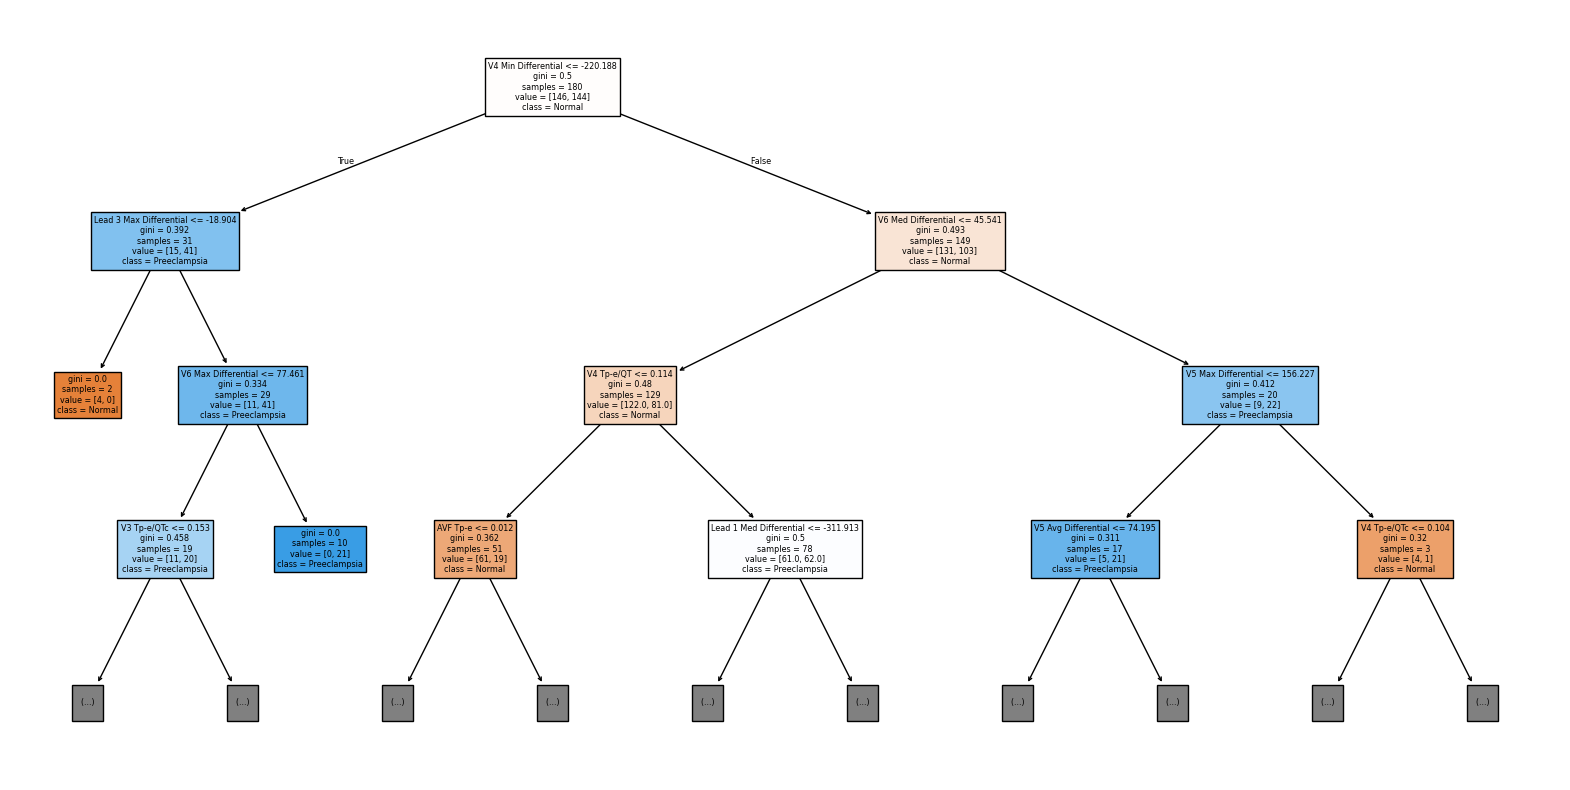

['rf_neuro_115_balanced.joblib']

In [7]:
groups = aligned_df['Pat_Obfus_MRN']
y = aligned_df['PatLabel'].values
x = aligned_df.drop(columns=columns_kept)

nans_mask = x.isna().any(axis=1)
x = x[~nans_mask].reset_index(drop=True)
y = y[~nans_mask]
groups = groups[~nans_mask].reset_index(drop=True)

kf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=7)

aucs = []
auprcs = []
specificities = []
sensitivities = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

model = RandomForestClassifier(random_state=7)

for train_index, test_index in kf.split(x, y, groups=groups):
  X_train, X_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y[train_index], y[test_index]
  rus = imblearn.under_sampling.RandomUnderSampler(random_state=7)
  train_x_rus, train_y_rus = rus.fit_resample(X_train, y_train)
  train_y_rus = pd.Series(train_y_rus)

  model.fit(train_x_rus, train_y_rus)

  # Model predictions
  y_pred = model.predict(X_test)
  y_probs = model.predict_proba(X_test)[:, 1]

  # Obtain AUC
  fpr, tpr, t = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  aucs.append(roc_auc)

  # Obtain AUPRC
  precision_values, recall_values, _ = precision_recall_curve(y_test, y_probs)
  auprc = auc(recall_values, precision_values)
  auprcs.append(auprc)

  # Obtain specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn/(tn + fp)
  specificities.append(specificity)

  # Obtain sensitivity
  sensitivity = tp/(tp+fn)
  sensitivities.append(sensitivity)

  # Obtain accuracy
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  accuracies.append(accuracy)

  # Obtain precision
  precision = tp/(tp+fp)
  precisions.append(precision)

  # Obtain recall
  recall = tp/(tp+fn)
  recalls.append(recall)

  # Obtain f1 score
  f1_score = (2 * precision * recall)/(precision + recall)
  f1_scores.append(f1_score)


# Print metrics
print('AUROC: ', np.mean(aucs), np.std(aucs), aucs)
print('AUPRC: ', np.mean(auprcs), np.std(auprcs), auprcs)
print('Specificity: ', np.mean(specificities), np.std(specificities), specificities)
print('Sensitivity: ', np.mean(sensitivities), np.std(sensitivities), sensitivities)
print('Accuracy: ', np.mean(accuracies), np.std(accuracies), accuracies)
print('F1 Score: ', np.mean(f1_scores), np.std(f1_scores), f1_scores)
print('Precision: ', np.mean(precisions), np.std(precisions), precisions)

plt.figure(figsize=(20, 10))
plot_tree(model.estimators_[0],
          feature_names=x.columns,
          class_names=['Normal', 'Preeclampsia'],
          filled=True,
          max_depth=3)
plt.show()

joblib.dump(model, 'rf_neuro_115_balanced.joblib')

### Balanced MUSE RF

Ground truth

In [8]:
muse_values = pd.read_csv(muse_data)
muse_values['ECGTestID'] = muse_values['ECGTestID'].astype(int).astype(str) # have to convert float to int then string for format
muse_values = muse_values[~muse_values['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse_values['PatLabel'] = muse_values['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
ground_truth = muse_values['PatLabel']
muse_values

,ECGTestID,Pat_Obfus_MRN,Preg_Obfus_ID,WeekDifference,WeeksPreg,PregECGTrimester,PatLabel,PLM_I_PAmpAtPOnset,PLM_I_PAmp,PLM_I_P_Duration,...,GM_pr_interval,GM_ventricular_rate,GM_avg_rr,REM_AtrialRate,REM_PAxis,REM_RAxis,REM_TAxis,REM_ECGSampleBase,REM_ECGSampleExponent,REM_QTcFrederica
0,1023185,1.979188e+09,-5.032235e+08,32.0,35,3.0,1,39.0,92.0,116.0,...,164.0,97.0,612.0,97.0,29.0,19.0,-2.0,500.0,0.0,382.0
1,1026129,-1.959447e+09,1.754852e+08,39.0,39,3.0,1,53.0,78.0,88.0,...,136.0,126.0,472.0,126.0,25.0,41.0,23.0,500.0,0.0,384.0
2,1038502,-5.939042e+08,-1.989144e+08,32.0,32,3.0,1,-20.0,126.0,80.0,...,106.0,145.0,414.0,145.0,44.0,78.0,45.0,500.0,0.0,397.0
3,1038520,-5.939042e+08,-1.989144e+08,32.0,32,3.0,1,0.0,156.0,88.0,...,114.0,122.0,492.0,122.0,38.0,71.0,58.0,500.0,0.0,448.0
4,1038542,-5.939042e+08,-1.989144e+08,32.0,32,3.0,1,9.0,117.0,78.0,...,108.0,121.0,494.0,121.0,57.0,98.0,31.0,500.0,0.0,361.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,1290488,-9.543971e+08,1.315620e+08,40.0,40,3.0,0,34.0,107.0,84.0,...,104.0,102.0,584.0,102.0,54.0,48.0,16.0,500.0,0.0,386.0
358,1806030,-1.748342e+09,-1.559425e+09,40.0,40,3.0,0,14.0,48.0,90.0,...,172.0,61.0,980.0,61.0,55.0,33.0,31.0,500.0,0.0,442.0
359,1806031,-1.748342e+09,-1.559425e+09,40.0,40,3.0,0,19.0,43.0,90.0,...,170.0,63.0,954.0,63.0,48.0,31.0,29.0,500.0,0.0,447.0
360,1898994,-2.141033e+09,1.462356e+09,34.0,39,3.0,0,-35.0,-97.0,86.0,...,148.0,82.0,734.0,82.0,NaN,142.0,148.0,500.0,0.0,397.0


Results

In [10]:
groups = muse_values['Pat_Obfus_MRN']
x = muse_values.drop(columns=['ECGTestID', 'Pat_Obfus_MRN', 'Preg_Obfus_ID', 'PatLabel', 'WeekDifference', 'WeeksPreg', 'PregECGTrimester'])
y = ground_truth

nans_mask = x.isna().any(axis=1)
x = x[~nans_mask].reset_index(drop=True)
y = y[~nans_mask].reset_index(drop=True)
groups = groups[~nans_mask].reset_index(drop=True)
kf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=7)

aucs = []
auprcs = []
specificities = []
sensitivities = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

model = RandomForestClassifier(random_state=7)

for train_index, test_index in kf.split(x, y, groups=groups):
  X_train, X_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y[train_index], y[test_index]
  rus = imblearn.under_sampling.RandomUnderSampler(random_state=7)
  train_x_rus, train_y_rus = rus.fit_resample(X_train, y_train)
  train_y_rus = pd.Series(train_y_rus)

  model.fit(train_x_rus, train_y_rus)

  # Model predictions
  y_pred = model.predict(X_test)
  y_probs = model.predict_proba(X_test)[:, 1]

  # Obtain AUC
  fpr, tpr, t = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  aucs.append(roc_auc)

  # Obtain AUPRC
  precision_values, recall_values, _ = precision_recall_curve(y_test, y_probs)
  auprc = auc(recall_values, precision_values)
  auprcs.append(auprc)

  # Obtain specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn/(tn + fp)
  specificities.append(specificity)

  # Obtain sensitivity
  sensitivity = tp/(tp+fn)
  sensitivities.append(sensitivity)

  # Obtain accuracy
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  accuracies.append(accuracy)

  # Obtain precision
  precision = tp/(tp+fp)
  precisions.append(precision)

  # Obtain recall
  recall = tp/(tp+fn)
  recalls.append(recall)

  # Obtain f1 score
  f1_score = (2 * precision * recall)/(precision + recall)
  f1_scores.append(f1_score)


# Print metrics
print('AUROC: ', np.mean(aucs), np.std(aucs), aucs)
print('AUPRC: ', np.mean(auprcs), np.std(auprcs), auprcs)
print('Specificity: ', np.mean(specificities), np.std(specificities), specificities)
print('Sensitivity: ', np.mean(sensitivities), np.std(sensitivities), sensitivities)
print('Accuracy: ', np.mean(accuracies), np.std(accuracies), accuracies)
print('F1 Score: ', np.mean(f1_scores), np.std(f1_scores), f1_scores)
print('Precision: ', np.mean(precisions), np.std(precisions), precisions)

joblib.dump(model, 'rf_MUSE_csv_balanced.joblib')

AUROC:  0.7323302469135802 0.07874751089157037 [0.7031746031746032, 0.8071428571428572, 0.7330246913580246, 0.6007936507936509, 0.8175154320987653]
AUPRC:  0.7571627903386726 0.07255061268615912 [0.7105223047456107, 0.8232801743662086, 0.791080034706147, 0.6377422943611017, 0.8231891435142955]
Specificity:  0.7292063492063492 0.05343904866666876 [np.float64(0.7142857142857143), np.float64(0.8285714285714286), np.float64(0.7222222222222222), np.float64(0.7142857142857143), np.float64(0.6666666666666666)]
Sensitivity:  0.6333333333333334 0.07535922203472518 [np.float64(0.6388888888888888), np.float64(0.5833333333333334), np.float64(0.5833333333333334), np.float64(0.5833333333333334), np.float64(0.7777777777777778)]
Accuracy:  0.6806338028169014 0.02882846170115814 [np.float64(0.676056338028169), np.float64(0.704225352112676), np.float64(0.6527777777777778), np.float64(0.647887323943662), np.float64(0.7222222222222222)]
F1 Score:  0.6647813563760145 0.04018720845664714 [np.float64(0.66666

['rf_MUSE_csv_balanced.joblib']

### Unbalanced MUSE RF


Ground truth

In [19]:
available_ecgs = pd.read_csv(muse_data_with_csv)
available_ecgs['ECGTestID'] = available_ecgs['ECGTestID'].astype(int).astype(str)
valid_ids = available_ecgs['ECGTestID']
muse_values = pd.read_csv(muse_data_unbalanced)
muse_values['ECGTestID'] = muse_values['ECGTestID'].astype(int).astype(str) # have to convert float to int then string for format
muse_values = muse_values[muse_values['ECGTestID'].isin(valid_ids)].reset_index(drop=True)
muse_values = muse_values[~muse_values['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse_values['PatLabel'] = muse_values['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
ground_truth = muse_values['PatLabel']
muse_values

,ECGTestID,Pat_Obfus_MRN,Preg_Obfus_ID,WeekDifference,WeeksPreg,PregECGTrimester,PatLabel,PLM_I_PAmpAtPOnset,PLM_I_PAmp,PLM_I_P_Duration,...,GM_pr_interval,GM_ventricular_rate,GM_avg_rr,REM_AtrialRate,REM_PAxis,REM_RAxis,REM_TAxis,REM_ECGSampleBase,REM_ECGSampleExponent,REM_QTcFrederica
0,960040,4.506023e+08,1.345198e+09,-7.0,39,0.0,0,48.0,83.0,118.0,...,168.0,45.0,1334.0,45.0,14.0,46.0,42.0,500.0,0.0,408.0
1,971235,7.676249e+08,-1.446412e+09,-2.0,28,0.0,0,4.0,53.0,104.0,...,202.0,66.0,910.0,66.0,62.0,79.0,59.0,500.0,0.0,460.0
2,971233,7.676249e+08,-1.446412e+09,-2.0,28,0.0,0,24.0,53.0,102.0,...,200.0,78.0,764.0,78.0,63.0,78.0,57.0,500.0,0.0,471.0
3,971226,7.676249e+08,-1.446412e+09,-2.0,28,0.0,0,19.0,53.0,116.0,...,176.0,97.0,616.0,97.0,69.0,84.0,72.0,500.0,0.0,457.0
4,974717,-1.359967e+09,-1.869437e+09,2.0,39,1.0,0,9.0,87.0,96.0,...,178.0,69.0,868.0,69.0,35.0,3.0,16.0,500.0,0.0,406.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,2268197,2.068865e+09,1.803590e+08,41.0,39,4.0,1,9.0,92.0,104.0,...,152.0,89.0,674.0,89.0,56.0,72.0,61.0,500.0,0.0,421.0
2155,2268180,2.068865e+09,1.803590e+08,41.0,39,4.0,1,14.0,68.0,94.0,...,132.0,57.0,1052.0,57.0,41.0,76.0,71.0,500.0,0.0,424.0
2156,2270336,2.068865e+09,1.803590e+08,42.0,39,4.0,1,14.0,68.0,98.0,...,134.0,65.0,923.0,65.0,59.0,77.0,60.0,500.0,0.0,422.0
2157,2273679,1.618018e+09,-2.033320e+09,39.0,27,4.0,1,34.0,102.0,92.0,...,126.0,96.0,625.0,96.0,35.0,53.0,15.0,500.0,0.0,416.0


Results

In [20]:
groups = muse_values['Pat_Obfus_MRN']
x = muse_values.drop(columns=['ECGTestID', 'Pat_Obfus_MRN', 'Preg_Obfus_ID', 'PatLabel', 'WeekDifference', 'WeeksPreg', 'PregECGTrimester'])
y = ground_truth

nans_mask = x.isna().any(axis=1)
x = x[~nans_mask].reset_index(drop=True)
y = y[~nans_mask].reset_index(drop=True)
groups = groups[~nans_mask].reset_index(drop=True)
kf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=7)

aucs = []
auprcs = []
specificities = []
sensitivities = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

model = RandomForestClassifier(random_state=7)

for train_index, test_index in kf.split(x, y, groups=groups):
  X_train, X_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y[train_index], y[test_index]
  rus = imblearn.under_sampling.RandomUnderSampler(random_state=7)
  train_x_rus, train_y_rus = rus.fit_resample(X_train, y_train)
  train_y_rus = pd.Series(train_y_rus)

  model.fit(train_x_rus, train_y_rus)

  # Model predictions
  y_pred = model.predict(X_test)
  y_probs = model.predict_proba(X_test)[:, 1]

  # Obtain AUC
  fpr, tpr, t = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  aucs.append(roc_auc)

  # Obtain AUPRC
  precision_values, recall_values, _ = precision_recall_curve(y_test, y_probs)
  auprc = auc(recall_values, precision_values)
  auprcs.append(auprc)

  # Obtain specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn/(tn + fp)
  specificities.append(specificity)

  # Obtain sensitivity
  sensitivity = tp/(tp+fn)
  sensitivities.append(sensitivity)

  # Obtain accuracy
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  accuracies.append(accuracy)

  # Obtain precision
  precision = tp/(tp+fp)
  precisions.append(precision)

  # Obtain f1 score
  f1_score = (2 * precision * recall)/(precision + recall)
  f1_scores.append(f1_score)


# Print metrics
print('AUROC: ', np.mean(aucs), np.std(aucs), aucs)
print('AUPRC: ', np.mean(auprcs), np.std(auprcs), auprcs)
print('Specificity: ', np.mean(specificities), np.std(specificities), specificities)
print('Sensitivity: ', np.mean(sensitivities), np.std(sensitivities), sensitivities)
print('Accuracy: ', np.mean(accuracies), np.std(accuracies), accuracies)
print('F1 Score: ', np.mean(f1_scores), np.std(f1_scores), f1_scores)
print('Precision: ', np.mean(precisions), np.std(precisions), precisions)

joblib.dump(model, 'rf_MUSE_csv_unbalanced.joblib')

AUROC:  0.7043975230678832 0.042317732677593006 [0.6909678502476287, 0.6525463456211378, 0.744459833795014, 0.7626251864479012, 0.6713883992277344]
AUPRC:  0.33446358259941356 0.05911770554050775 [0.42357437561138517, 0.251796156655198, 0.3385281068438339, 0.3654598131577823, 0.29295946072886847]
Specificity:  0.7368421052631579 0.04801122225660564 [np.float64(0.8227146814404432), np.float64(0.7091412742382271), np.float64(0.7479224376731302), np.float64(0.7229916897506925), np.float64(0.6814404432132964)]
Sensitivity:  0.5823776223776224 0.06658113084122208 [np.float64(0.5757575757575758), np.float64(0.49230769230769234), np.float64(0.6060606060606061), np.float64(0.6923076923076923), np.float64(0.5454545454545454)]
Accuracy:  0.7130652769073457 0.04346222955231984 [np.float64(0.7845433255269321), np.float64(0.676056338028169), np.float64(0.7259953161592506), np.float64(0.7183098591549296), np.float64(0.6604215456674473)]
F1 Score:  0.42203856243138976 0.05407782284945911 [np.float64(

['rf_MUSE_csv_unbalanced.joblib']

### Unbalanced RF

Ground truth

In [21]:
available_ecgs = pd.read_csv(muse_data_with_csv)
available_ecgs['ECGTestID'] = available_ecgs['ECGTestID'].astype(int).astype(str)
valid_ids = available_ecgs['ECGTestID']
muse_values = pd.read_csv(muse_data_unbalanced)
muse_values['ECGTestID'] = muse_values['ECGTestID'].astype(int).astype(str)
muse_values = muse_values[muse_values['ECGTestID'].isin(valid_ids)].reset_index(drop=True)
muse_values = muse_values[~muse_values['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse_values['PatLabel'] = muse_values['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
# for ground truth
columns_kept = ['ECGTestID', 'PatLabel', 'Pat_Obfus_MRN']
ground_truth_prog = muse_values[columns_kept]
features_DF = pd.read_csv(f"{base}/PreEfeatures_unbalanced.csv")
features_DF['ECGTestID'] = features_DF['ECGTestID'].astype(int).astype(str)
aligned_df = pd.merge(features_DF, ground_truth_prog, on='ECGTestID', how='inner')
aligned_df
#muse_values

,ECGTestID,Pmax,Pmin,P-wave Dispersion,QT Dispersion,AVF Tp-e,AVL Tp-e,AVR Tp-e,I Tp-e,II Tp-e,...,V5 Max Differential,V5 Min Differential,V6 ST Elevation,V6 ST Depression,V6 Avg Differential,V6 Med Differential,V6 Max Differential,V6 Min Differential,PatLabel,Pat_Obfus_MRN
0,1000799,0.102,0.022,0.080,0.274,0.019000,0.034833,0.042833,0.046667,0.028833,...,63.248115,21.036131,0,0,31.669814,34.371701,60.599090,6.616139,0,-1.677806e+09
1,1005958,0.162,0.022,0.140,0.320,0.034167,0.027143,0.045077,0.037231,0.045667,...,90.126136,-26.793748,0,0,13.162620,23.736562,74.486274,-168.399372,0,-1.802709e+09
2,1011994,0.120,0.012,0.108,0.256,0.011333,0.036800,0.041200,0.041400,0.020000,...,51.337438,-61.051506,0,0,-25.287509,-20.169205,43.381557,-95.914613,0,3.588379e+08
3,1013265,0.166,0.030,0.136,0.318,0.055111,0.044667,0.048222,0.043778,0.056667,...,72.246054,8.164046,0,0,37.860586,43.269892,56.181457,6.347756,0,4.964046e+08
4,1013613,0.102,0.026,0.076,0.290,0.016000,0.039273,0.052364,0.035818,0.049091,...,82.502005,2.975278,0,0,7.225751,11.210147,26.309523,-21.177984,0,1.398471e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,977225,0.116,0.022,0.094,0.262,0.016778,0.040111,0.044111,0.043222,0.023556,...,99.260617,-43.654410,0,0,21.002408,21.849083,69.491613,-27.568593,0,1.052714e+09
2155,986675,0.106,0.026,0.080,0.230,0.019067,0.039600,0.051600,0.038533,0.023733,...,72.556119,-75.508580,0,0,-0.968731,-2.979286,54.275000,-99.259448,0,9.786605e+08
2156,988992,0.124,0.020,0.104,0.220,0.050571,0.040286,0.045143,0.034571,0.052571,...,90.862478,30.266865,0,0,46.330145,51.054198,60.587944,14.313265,0,-1.957039e+09
2157,988993,0.116,0.020,0.096,0.288,0.050000,0.044857,0.046000,0.034286,0.050000,...,60.681442,36.192486,0,0,38.752839,38.504335,54.345934,25.193907,0,-1.957039e+09


Results

In [22]:
groups = aligned_df['Pat_Obfus_MRN']
y = aligned_df['PatLabel'].values
x = aligned_df.drop(columns=columns_kept)

nans_mask = x.isna().any(axis=1)
x = x[~nans_mask].reset_index(drop=True)
y = y[~nans_mask]
groups = groups[~nans_mask].reset_index(drop=True)

kf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=7)

aucs = []
auprcs = []
specificities = []
sensitivities = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

model = RandomForestClassifier(random_state=7)

for train_index, test_index in kf.split(x, y, groups=groups):
  X_train, X_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y[train_index], y[test_index]
  rus = imblearn.under_sampling.RandomUnderSampler(random_state=7)
  train_x_rus, train_y_rus = rus.fit_resample(X_train, y_train)
  train_y_rus = pd.Series(train_y_rus)

  model.fit(train_x_rus, train_y_rus)

  # Model predictions
  y_pred = model.predict(X_test)
  y_probs = model.predict_proba(X_test)[:, 1]

  # Obtain AUC
  fpr, tpr, t = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  aucs.append(roc_auc)

  # Obtain AUPRC
  precision_values, recall_values, _ = precision_recall_curve(y_test, y_probs)
  auprc = auc(recall_values, precision_values)
  auprcs.append(auprc)

  # Obtain specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn/(tn + fp)
  specificities.append(specificity)

  # Obtain sensitivity
  sensitivity = tp/(tp+fn)
  sensitivities.append(sensitivity)

  # Obtain accuracy
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  accuracies.append(accuracy)

  # Obtain precision
  precision = tp/(tp+fp)
  precisions.append(precision)

  # Obtain recall
  recall = tp/(tp+fn)
  recalls.append(recall)

  # Obtain f1 score
  f1_score = (2 * precision * recall)/(precision + recall)
  f1_scores.append(f1_score)


# Print metrics
print('AUROC: ', np.mean(aucs), np.std(aucs), aucs)
print('AUPRC: ', np.mean(auprcs), np.std(auprcs), auprcs)
print('Specificity: ', np.mean(specificities), np.std(specificities), specificities)
print('Sensitivity: ', np.mean(sensitivities), np.std(sensitivities), sensitivities)
print('Accuracy: ', np.mean(accuracies), np.std(accuracies), accuracies)
print('F1 Score: ', np.mean(f1_scores), np.std(f1_scores), f1_scores)
print('Precision: ', np.mean(precisions), np.std(precisions), precisions)

joblib.dump(model, 'rf_neuro_115_unbalanced.joblib')

AUROC:  0.6534944017730904 0.024937345768922647 [0.6428009604239113, 0.6384335154826958, 0.6282497102169234, 0.699370756747806, 0.6586170659941154]
AUPRC:  0.24407635282344914 0.01711708677196893 [0.2252972386219956, 0.22917442308025404, 0.2381988447482314, 0.2578031071521023, 0.26990815051466227]
Specificity:  0.674863387978142 0.0293254816721284 [np.float64(0.6502732240437158), np.float64(0.6830601092896175), np.float64(0.726775956284153), np.float64(0.6693989071038251), np.float64(0.644808743169399)]
Sensitivity:  0.5533799533799534 0.09139610152641303 [np.float64(0.5151515151515151), np.float64(0.5), np.float64(0.4393939393939394), np.float64(0.696969696969697), np.float64(0.6153846153846154)]
Accuracy:  0.6563149866804159 0.019860263030378193 [np.float64(0.6296296296296297), np.float64(0.6550925925925926), np.float64(0.6828703703703703), np.float64(0.6736111111111112), np.float64(0.6403712296983759)]
F1 Score:  0.32758671459593014 0.037104982854106704 [np.float64(0.298245614035087

['rf_neuro_115_unbalanced.joblib']

# Chi^2 testing

### MUSE Balanced

In [ ]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

muse_values = pd.read_csv(muse_data)
muse_values['ECGTestID'] = muse_values['ECGTestID'].astype(int).astype(str) # have to convert float to int then string for format
muse_values = muse_values[~muse_values['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse_values['PatLabel'] = muse_values['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
ground_truth = muse_values['PatLabel']

x = muse_values.drop(columns=['ECGTestID', 'Pat_Obfus_MRN', 'Preg_Obfus_ID', 'PatLabel', 'WeekDifference', 'WeeksPreg', 'PregECGTrimester'])
y = ground_truth

nans_X = x.isna().any(axis=1)
x = x[~nans_X]
y = y[~nans_X]

x.index = range(len(x))
y.index = range(len(y))

y = y.values.ravel()
y = y.astype(int)
columns_to_use = x.columns
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x[columns_to_use])
chi2_vals, pvals = chi2(x_scaled, y)
cols_to_pvals = zip(pvals, columns_to_use)
cols_sorted = sorted(cols_to_pvals)

for p, col in cols_sorted[:10]:
    print(f"{col}: {p:.5f}")

PLM_II_STEToTPrimePeak: 0.00381
PLM_II_TPrimeDuration: 0.00833
PLM_I_TPrimeDuration: 0.01715
PLM_I_STEToTPrimePeak: 0.02746
PLM_III_QOnsetToSPrimePeak: 0.02969
PLM_III_SPrimeDuration: 0.03614
PLM_V2_QOnsetToRPrimePeak: 0.03876
PLM_V1_BITFLGS: 0.07949
PLM_V1_RPrimeArea: 0.09231
PLM_III_SPrimeArea: 0.09835


## MUSE Unbalanced

In [ ]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

available_ecgs = pd.read_csv(muse_data_with_csv)
available_ecgs['ECGTestID'] = available_ecgs['ECGTestID'].astype(int).astype(str)
valid_ids = available_ecgs['ECGTestID']
muse_values = muse_values[muse_values['ECGTestID'].isin(valid_ids)].reset_index(drop=True)
muse_values['ECGTestID'] = muse_values['ECGTestID'].astype(int).astype(str) # have to convert float to int then string for format
muse_values = muse_values[~muse_values['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse_values['PatLabel'] = muse_values['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
ground_truth = muse_values['PatLabel']

x = muse_values.drop(columns=['ECGTestID', 'Pat_Obfus_MRN', 'Preg_Obfus_ID', 'PatLabel', 'WeekDifference', 'WeeksPreg', 'PregECGTrimester'])
y = ground_truth

nans_X = x.isna().any(axis=1)
x = x[~nans_X]
y = y[~nans_X]

x.index = range(len(x))
y.index = range(len(y))

y = y.values.ravel()
y = y.astype(int)
columns_to_use = x.columns
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x[columns_to_use])
chi2_vals, pvals = chi2(x_scaled, y)
cols_to_pvals = zip(pvals, columns_to_use)
cols_sorted = sorted(cols_to_pvals)

for p, col in cols_sorted[:10]:
    print(f"{col}: {p:.5f}")


PLM_V2_QOnsetToQPeak: 0.00000
PLM_V2_QAmp: 0.00001
PLM_V2_QOnsetToRPrimePeak: 0.00001
PLM_V2_Q_Duration: 0.00001
PLM_V2_QArea: 0.00002
PLM_V3_BITFLGS: 0.00014
PLM_V3_QArea: 0.00025
PLM_V2_RPrimeDuration: 0.00145
PLM_V1_QOnsetToRPrimePeak: 0.00164
PLM_I_TPrimeDuration: 0.00192


## Balanced Featurization

In [ ]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

muse_values = pd.read_csv(muse_data)
muse_values['ECGTestID'] = muse_values['ECGTestID'].astype(int).astype(str) # have to convert float to int then string for format
muse_values = muse_values[~muse_values['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse_values['PatLabel'] = muse_values['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
# for ground truth
columns_kept = ['ECGTestID', 'PatLabel', 'Pat_Obfus_MRN']
ground_truth_prog = muse_values[columns_kept]
features_DF = pd.read_csv(f"{base}/PreEfeatures_balanced.csv")
features_DF['ECGTestID'] = features_DF['ECGTestID'].astype(int).astype(str)
aligned_df = pd.merge(features_DF, ground_truth_prog, on='ECGTestID', how='inner')

x = aligned_df.drop(columns=columns_kept)
#x = muse_values.drop(columns=['ECGTestID', 'Pat_Obfus_MRN', 'Preg_Obfus_ID', 'PatLabel', 'WeekDifference', 'WeeksPreg', 'PregECGTrimester'])
y = aligned_df['PatLabel']

nans_X = x.isna().any(axis=1)
x = x[~nans_X]
y = y[~nans_X]

x.index = range(len(x))
y.index = range(len(y))

y = y.values.ravel()
y = y.astype(int)
columns_to_use = x.columns
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x[columns_to_use])
chi2_vals, pvals = chi2(x_scaled, y)
cols_to_pvals = zip(pvals, columns_to_use)
cols_sorted = sorted(cols_to_pvals)

for p, col in cols_sorted[:10]:
    print(f"{col}: {p:.5f}")

V4 ST Depression: 0.04311
AVL ST Depression: 0.05271
AVL ST Elevation: 0.14037
Lead 3 ST Elevation: 0.15730
Lead 1 ST Depression: 0.20018
AVR ST Elevation: 0.21000
V3 ST Depression: 0.26488
AVF ST Elevation: 0.31731
V5 ST Depression: 0.34578
V3 Tp-e: 0.37133


## Unbalanced Featurization

In [ ]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

available_ecgs = pd.read_csv(muse_data_with_csv)
available_ecgs['ECGTestID'] = available_ecgs['ECGTestID'].astype(int).astype(str)
valid_ids = available_ecgs['ECGTestID']
muse_values = pd.read_csv(muse_data_unbalanced)
muse_values['ECGTestID'] = muse_values['ECGTestID'].astype(int).astype(str)
muse_values = muse_values[muse_values['ECGTestID'].isin(valid_ids)].reset_index(drop=True)
muse_values = muse_values[~muse_values['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse_values['PatLabel'] = muse_values['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
# for ground truth
columns_kept = ['ECGTestID', 'PatLabel', 'Pat_Obfus_MRN']
ground_truth_prog = muse_values[columns_kept]
features_DF = pd.read_csv(f"{base}/PreEfeatures_unbalanced.csv")
features_DF['ECGTestID'] = features_DF['ECGTestID'].astype(int).astype(str)
aligned_df = pd.merge(features_DF, ground_truth_prog, on='ECGTestID', how='inner')

x = aligned_df.drop(columns=columns_kept)
#x = muse_values.drop(columns=['ECGTestID', 'Pat_Obfus_MRN', 'Preg_Obfus_ID', 'PatLabel', 'WeekDifference', 'WeeksPreg', 'PregECGTrimester'])
y = aligned_df['PatLabel']

nans_X = x.isna().any(axis=1)
x = x[~nans_X]
y = y[~nans_X]

x.index = range(len(x))
y.index = range(len(y))

y = y.values.ravel()
y = y.astype(int)
columns_to_use = x.columns
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x[columns_to_use])
chi2_vals, pvals = chi2(x_scaled, y)
cols_to_pvals = zip(pvals, columns_to_use)
cols_sorted = sorted(cols_to_pvals)

for p, col in cols_sorted[:10]:
    print(f"{col}: {p:.5f}")



AVL ST Depression: 0.00000
V4 ST Depression: 0.00096
AVR ST Elevation: 0.00375
V3 ST Elevation: 0.01062
Lead 3 ST Elevation: 0.02104
Lead 2 ST Depression: 0.04179
Lead 1 ST Depression: 0.04696
AVL ST Elevation: 0.05552
V2 ST Elevation: 0.05932
V3 ST Depression: 0.06459


## Test chi squared top 10

In [ ]:
muse_values = pd.read_csv(muse_data)
muse_values['ECGTestID'] = muse_values['ECGTestID'].astype(int).astype(str) # have to convert float to int then string for format
muse_values = muse_values[~muse_values['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse_values['PatLabel'] = muse_values['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
ground_truth = muse_values['PatLabel']

x = muse_values[['PLM_II_STEToTPrimePeak', 'PLM_II_TPrimeDuration', 'PLM_I_TPrimeDuration', 'PLM_I_STEToTPrimePeak',
                 'PLM_aVR_QOnsetToRPrimePeak', 'PLM_V2_QOnsetTo']]
y = ground_truth

nans_X = x.isna().any(axis=1)
x = x[~nans_X]
y = y[~nans_X]

x.index = range(len(x))
y.index = range(len(y))

y = y.values.ravel()
y = y.astype(int)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

aucs = []
auprcs = []
specificities = []
sensitivities = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

model = RandomForestClassifier(random_state=7)

for train_index, test_index in kf.split(x, y):
  X_train, X_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y[train_index], y[test_index]
  rus = imblearn.under_sampling.RandomUnderSampler(random_state=7)
  train_x_rus, train_y_rus = rus.fit_resample(X_train, y_train)
  train_y_rus = pd.Series(train_y_rus)

  model.fit(train_x_rus, train_y_rus)

  # Model predictions
  y_pred = model.predict(X_test)
  y_probs = model.predict_proba(X_test)[:, 1]

  # Obtain AUC
  fpr, tpr, t = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  aucs.append(roc_auc)

  # Obtain AUPRC
  precision_values, recall_values, _ = precision_recall_curve(y_test, y_probs)
  auprc = auc(recall_values, precision_values)
  auprcs.append(auprc)

  # Obtain specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn/(tn + fp)
  specificities.append(specificity)

  # Obtain sensitivity
  sensitivity = tp/(tp+fn)
  sensitivities.append(sensitivity)

  # Obtain accuracy
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  accuracies.append(accuracy)

  # Obtain precision
  precision = tp/(tp+fp)
  precisions.append(precision)

  # Obtain recall
  recall = tp/(tp+fn)
  recalls.append(recall)

  # Obtain f1 score
  f1_score = (2 * precision * recall)/(precision + recall)
  f1_scores.append(f1_score)


# Print metrics
print('AUROC: ', np.mean(aucs), np.std(aucs), aucs)
print('AUPRC: ', np.mean(auprcs), np.std(auprcs), auprcs)
print('Specificity: ', np.mean(specificities), np.std(specificities), specificities)
print('Sensitivity: ', np.mean(sensitivities), np.std(sensitivities), sensitivities)
print('Accuracy: ', np.mean(accuracies), np.std(accuracies), accuracies)
print('F1 Score: ', np.mean(f1_scores), np.std(f1_scores), f1_scores)
print('Precision: ', np.mean(precisions), np.std(precisions), precisions)
print('Recall: ', np.mean(recalls), np.std(recalls), recalls)

AUROC:  0.5831831831831832 0.03366897408642334 [0.6032282282282282, 0.5645645645645646, 0.5266516516516517, 0.6006006006006006, 0.6208708708708709]
AUPRC:  0.6686975986246241 0.041430817581877055 [0.6739547391081918, 0.6339308372759076, 0.6163879877419831, 0.6844804431760954, 0.7347339858209424]
Specificity:  0.9280780780780781 0.013984130873123194 [np.float64(0.9166666666666666), np.float64(0.9166666666666666), np.float64(0.9444444444444444), np.float64(0.9166666666666666), np.float64(0.9459459459459459)]
Sensitivity:  0.19594594594594597 0.05092282076058587 [np.float64(0.21621621621621623), np.float64(0.13513513513513514), np.float64(0.13513513513513514), np.float64(0.24324324324324326), np.float64(0.25)]
Accuracy:  0.558904109589041 0.029252269183647418 [np.float64(0.5616438356164384), np.float64(0.5205479452054794), np.float64(0.5342465753424658), np.float64(0.5753424657534246), np.float64(0.6027397260273972)]
F1 Score:  0.30663078900160967 0.06877643769754362 [np.float64(0.3333333

# MUSE Features Week of 4/26-5/3

### Dataset: Balanced MUSE
    Featurization

In [ ]:
muse_df = pd.read_csv(muse_data)
muse_featurizations = pd.DataFrame()

muse_featurizations['ECGTestID'] = muse_df['ECGTestID'].astype(int).astype(str)

# Pmin, Pmax, P-wave Dispersion
columns_p = ['PLM_I_P_Duration', 'PLM_II_P_Duration', 'PLM_III_P_Duration',
           'PLM_V1_P_Duration', 'PLM_V2_P_Duration', 'PLM_V3_P_Duration',
           'PLM_V4_P_Duration', 'PLM_V5_P_Duration', 'PLM_V6_P_Duration',
           'PLM_aVR_P_Duration', 'PLM_aVL_P_Duration', 'PLM_aVF_P_Duration']
muse_featurizations['Pmin'] = muse_df[columns_p].min(axis=1)
muse_featurizations['Pmax'] = muse_df[columns_p].max(axis=1)
muse_featurizations['P-wave Dispersion'] = muse_featurizations['Pmax'] - muse_featurizations['Pmin']

# QT Dispersion
muse_featurizations['QT I'] = (muse_df['PLM_I_Q_Duration'] + muse_df['PLM_I_R_Duration'] + muse_df['PLM_I_S_Duration']
                               + muse_df['PLM_I_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_I_RPrimeDuration']
                               + muse_df['PLM_I_SPrimeDuration'] + muse_df['PLM_I_TPrimeDuration'])
muse_featurizations['QT II'] = (muse_df['PLM_II_Q_Duration'] + muse_df['PLM_II_R_Duration'] + muse_df['PLM_II_S_Duration']
                               + muse_df['PLM_II_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_II_RPrimeDuration']
                               + muse_df['PLM_II_SPrimeDuration'] + muse_df['PLM_II_TPrimeDuration'])
muse_featurizations['QT III'] = (muse_df['PLM_III_Q_Duration'] + muse_df['PLM_III_R_Duration'] + muse_df['PLM_III_S_Duration']
                               + muse_df['PLM_III_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_III_RPrimeDuration']
                               + muse_df['PLM_III_SPrimeDuration'] + muse_df['PLM_III_TPrimeDuration'])
muse_featurizations['QT V1'] = (muse_df['PLM_V1_Q_Duration'] + muse_df['PLM_V1_R_Duration'] + muse_df['PLM_V1_S_Duration']
                               + muse_df['PLM_V1_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_V1_RPrimeDuration']
                               + muse_df['PLM_V1_SPrimeDuration'] + muse_df['PLM_V1_TPrimeDuration'])
muse_featurizations['QT V2'] = (muse_df['PLM_V2_Q_Duration'] + muse_df['PLM_V2_R_Duration'] + muse_df['PLM_V2_S_Duration']
                               + muse_df['PLM_V2_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_V2_RPrimeDuration']
                               + muse_df['PLM_V2_SPrimeDuration'] + muse_df['PLM_V2_TPrimeDuration'])
muse_featurizations['QT V3'] = (muse_df['PLM_V3_Q_Duration'] + muse_df['PLM_V3_R_Duration'] + muse_df['PLM_V3_S_Duration']
                               + muse_df['PLM_V3_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_V3_RPrimeDuration']
                               + muse_df['PLM_V3_SPrimeDuration'] + muse_df['PLM_V3_TPrimeDuration'])
muse_featurizations['QT V4'] = (muse_df['PLM_V4_Q_Duration'] + muse_df['PLM_V4_R_Duration'] + muse_df['PLM_V4_S_Duration']
                               + muse_df['PLM_V4_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_V4_RPrimeDuration']
                               + muse_df['PLM_V4_SPrimeDuration'] + muse_df['PLM_V4_TPrimeDuration'])
muse_featurizations['QT V5'] = (muse_df['PLM_V5_Q_Duration'] + muse_df['PLM_V5_R_Duration'] + muse_df['PLM_V5_S_Duration']
                               + muse_df['PLM_V5_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_V5_RPrimeDuration']
                               + muse_df['PLM_V5_SPrimeDuration'] + muse_df['PLM_V5_TPrimeDuration'])
muse_featurizations['QT V6'] = (muse_df['PLM_V6_Q_Duration'] + muse_df['PLM_V6_R_Duration'] + muse_df['PLM_V6_S_Duration']
                               + muse_df['PLM_V6_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_V6_RPrimeDuration']
                               + muse_df['PLM_V6_SPrimeDuration'] + muse_df['PLM_V6_TPrimeDuration'])
muse_featurizations['QT aVL'] = (muse_df['PLM_aVL_Q_Duration'] + muse_df['PLM_aVL_R_Duration'] + muse_df['PLM_aVL_S_Duration']
                               + muse_df['PLM_aVL_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_aVL_RPrimeDuration']
                               + muse_df['PLM_aVL_SPrimeDuration'] + muse_df['PLM_aVL_TPrimeDuration'])
muse_featurizations['QT aVR'] = (muse_df['PLM_aVR_Q_Duration'] + muse_df['PLM_aVR_R_Duration'] + muse_df['PLM_aVR_S_Duration']
                               + muse_df['PLM_aVR_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_aVR_RPrimeDuration']
                               + muse_df['PLM_aVR_SPrimeDuration'] + muse_df['PLM_aVR_TPrimeDuration'])
muse_featurizations['QT aVF'] = (muse_df['PLM_aVF_Q_Duration'] + muse_df['PLM_aVF_R_Duration'] + muse_df['PLM_aVF_S_Duration']
                               + muse_df['PLM_aVF_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_aVF_RPrimeDuration']
                               + muse_df['PLM_aVF_SPrimeDuration'] + muse_df['PLM_aVF_TPrimeDuration'])
columns_qt = ['QT I', 'QT II', 'QT III', 'QT V1', 'QT V2', 'QT V3', 'QT V4', 'QT V5',
              'QT V6', 'QT aVL', 'QT aVR', 'QT aVF']
muse_featurizations['QT Dispersion'] = muse_featurizations[columns_qt].max(axis=1) - muse_featurizations[columns_qt].min(axis=1)

# Tp-e Intervals, Tp-e/QT, Tp-e/QTc
muse_featurizations['AVF Tp-e'] = muse_df['PLM_aVF_T_Duration'] + muse_df['PLM_aVF_TPrimeDuration'] - muse_df['PLM_aVF_STEToTPeak']
muse_featurizations['AVL Tp-e'] = muse_df['PLM_aVL_T_Duration'] + muse_df['PLM_aVL_TPrimeDuration'] - muse_df['PLM_aVF_STEToTPeak']
muse_featurizations['AVR Tp-e'] = muse_df['PLM_aVR_T_Duration'] + muse_df['PLM_aVR_TPrimeDuration'] - muse_df['PLM_aVR_STEToTPeak']
muse_featurizations['I Tp-e'] = muse_df['PLM_I_T_Duration'] + muse_df['PLM_I_TPrimeDuration'] - muse_df['PLM_I_STEToTPeak']
muse_featurizations['II Tp-e'] = muse_df['PLM_II_T_Duration'] + muse_df['PLM_II_TPrimeDuration'] - muse_df['PLM_II_STEToTPeak']
muse_featurizations['III Tp-e'] = muse_df['PLM_III_T_Duration'] + muse_df['PLM_III_TPrimeDuration'] - muse_df['PLM_III_STEToTPeak']
muse_featurizations['V1 Tp-e'] = muse_df['PLM_V1_T_Duration'] + muse_df['PLM_V1_TPrimeDuration'] - muse_df['PLM_V1_STEToTPeak']
muse_featurizations['V2 Tp-e'] = muse_df['PLM_V2_T_Duration'] + muse_df['PLM_V2_TPrimeDuration'] - muse_df['PLM_V2_STEToTPeak']
muse_featurizations['V3 Tp-e'] = muse_df['PLM_V3_T_Duration'] + muse_df['PLM_V3_TPrimeDuration'] - muse_df['PLM_V3_STEToTPeak']
muse_featurizations['V4 Tp-e'] = muse_df['PLM_V4_T_Duration'] + muse_df['PLM_V4_TPrimeDuration'] - muse_df['PLM_V4_STEToTPeak']
muse_featurizations['V5 Tp-e'] = muse_df['PLM_V5_T_Duration'] + muse_df['PLM_V5_TPrimeDuration'] - muse_df['PLM_V5_STEToTPeak']
muse_featurizations['V6 Tp-e'] = muse_df['PLM_V6_T_Duration'] + muse_df['PLM_V6_TPrimeDuration'] - muse_df['PLM_V6_STEToTPeak']
muse_featurizations['AVF Tp-e/QT'] = muse_featurizations['AVF Tp-e'] / muse_featurizations['QT aVF']
muse_featurizations['AVL Tp-e/QT'] = muse_featurizations['AVL Tp-e'] / muse_featurizations['QT aVL']
muse_featurizations['AVR Tp-e/QT'] = muse_featurizations['AVR Tp-e'] / muse_featurizations['QT aVR']
muse_featurizations['I Tp-e/QT'] = muse_featurizations['I Tp-e'] / muse_featurizations['QT I']
muse_featurizations['II Tp-e/QT'] = muse_featurizations['II Tp-e'] / muse_featurizations['QT II']
muse_featurizations['III Tp-e/QT'] = muse_featurizations['III Tp-e'] / muse_featurizations['QT III']
muse_featurizations['V1 Tp-e/QT'] = muse_featurizations['V1 Tp-e'] / muse_featurizations['QT V1']
muse_featurizations['V2 Tp-e/QT'] = muse_featurizations['V2 Tp-e'] / muse_featurizations['QT V2']
muse_featurizations['V3 Tp-e/QT'] = muse_featurizations['V3 Tp-e'] / muse_featurizations['QT V3']
muse_featurizations['V4 Tp-e/QT'] = muse_featurizations['V4 Tp-e'] / muse_featurizations['QT V4']
muse_featurizations['V5 Tp-e/QT'] = muse_featurizations['V5 Tp-e'] / muse_featurizations['QT V5']
muse_featurizations['V6 Tp-e/QT'] = muse_featurizations['V6 Tp-e'] / muse_featurizations['QT V6']
muse_featurizations['AVF Tp-e/QTc'] = muse_featurizations['AVF Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['AVL Tp-e/QTc'] = muse_featurizations['AVL Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['AVR Tp-e/QTc'] = muse_featurizations['AVR Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['I Tp-e/QTc'] = muse_featurizations['I Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['II Tp-e/QTc'] = muse_featurizations['II Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['III Tp-e/QTc'] = muse_featurizations['III Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['V1 Tp-e/QTc'] = muse_featurizations['V1 Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['V2 Tp-e/QTc'] = muse_featurizations['V2 Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['V3 Tp-e/QTc'] = muse_featurizations['V3 Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['V4 Tp-e/QTc'] = muse_featurizations['V4 Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['V5 Tp-e/QTc'] = muse_featurizations['V5 Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['V6 Tp-e/QTc'] = muse_featurizations['V6 Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)

# ST-T
muse_featurizations['AVF ST Elevation'] = ((muse_df['PLM_aVF_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['AVF ST Depression'] = ((muse_df['PLM_aVF_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['AVL ST Elevation'] = ((muse_df['PLM_aVL_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['AVL ST Depression'] = ((muse_df['PLM_aVL_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['AVR ST Elevation'] = ((muse_df['PLM_aVR_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['AVR ST Depression'] = ((muse_df['PLM_aVR_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['I ST Elevation'] = ((muse_df['PLM_I_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['I ST Depression'] = ((muse_df['PLM_I_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['II ST Elevation'] = ((muse_df['PLM_II_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['II ST Depression'] = ((muse_df['PLM_II_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['III ST Elevation'] = ((muse_df['PLM_III_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['III ST Depression'] = ((muse_df['PLM_III_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['V1 ST Elevation'] = ((muse_df['PLM_V1_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['V1 ST Depression'] = ((muse_df['PLM_V1_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['V2 ST Elevation'] = ((muse_df['PLM_V2_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['V2 ST Depression'] = ((muse_df['PLM_V2_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['V3 ST Elevation'] = ((muse_df['PLM_V3_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['V3 ST Depression'] = ((muse_df['PLM_V3_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['V4 ST Elevation'] = ((muse_df['PLM_V4_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['V4 ST Depression'] = ((muse_df['PLM_V4_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['V5 ST Elevation'] = ((muse_df['PLM_V5_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['V5 ST Depression'] = ((muse_df['PLM_V5_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['V6 ST Elevation'] = ((muse_df['PLM_V6_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['V6 ST Depression'] = ((muse_df['PLM_V6_BITFLGS'].astype(int) & 4) != 0).astype(int)

# QRS/T Axes and Frontal QRS-T Angle
muse_featurizations['QRS Axis'] = muse_df['REM_RAxis']
muse_featurizations['T Axis'] = muse_df['REM_TAxis']
muse_featurizations['Frontal QRS-T Angle'] = abs(muse_featurizations['QRS Axis'] - muse_featurizations['T Axis'])

muse_featurizations = muse_featurizations.drop(columns=columns_qt)
muse_featurizations = muse_featurizations[~muse_featurizations['ECGTestID'].isin(drop_list)]
muse_featurizations = muse_featurizations.reset_index(drop=True)

muse_featurizations

,ECGTestID,Pmin,Pmax,P-wave Dispersion,QT Dispersion,AVF Tp-e,AVL Tp-e,AVR Tp-e,I Tp-e,II Tp-e,...,V3 ST Depression,V4 ST Elevation,V4 ST Depression,V5 ST Elevation,V5 ST Depression,V6 ST Elevation,V6 ST Depression,QRS Axis,T Axis,Frontal QRS-T Angle
0,1023185,56.0,116.0,60.0,42.0,38.0,80.0,76.0,76.0,68.0,...,0,0,0,0,1,0,1,19.0,-2.0,21.0
1,1026129,0.0,88.0,88.0,0.0,80.0,80.0,72.0,72.0,72.0,...,0,0,0,0,0,0,0,41.0,23.0,18.0
2,1038502,16.0,80.0,64.0,86.0,74.0,48.0,78.0,86.0,74.0,...,0,0,0,0,0,0,0,78.0,45.0,33.0
3,1038520,32.0,88.0,56.0,212.0,0.0,118.0,68.0,62.0,76.0,...,0,0,0,0,0,0,0,71.0,58.0,13.0
4,1038542,29.0,78.0,49.0,79.0,92.0,57.0,66.0,66.0,66.0,...,1,0,0,0,0,0,0,98.0,31.0,67.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,1290488,35.0,84.0,49.0,74.0,-20.0,44.0,68.0,76.0,38.0,...,0,0,0,0,0,0,0,48.0,16.0,32.0
358,1806030,0.0,90.0,90.0,38.0,94.0,56.0,106.0,104.0,106.0,...,0,0,0,0,1,0,1,33.0,31.0,2.0
359,1806031,28.0,90.0,62.0,11.0,90.0,90.0,110.0,120.0,104.0,...,0,0,1,0,1,0,1,31.0,29.0,2.0
360,1898994,31.0,86.0,55.0,182.0,92.0,92.0,90.0,92.0,104.0,...,0,0,1,0,1,0,1,142.0,148.0,6.0


Ground truth

In [24]:
muse_values = pd.read_csv(muse_data)
muse_values['ECGTestID'] = muse_values['ECGTestID'].astype(int).astype(str) # have to convert float to int then string for format
muse_values = muse_values[~muse_values['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse_values['PatLabel'] = muse_values['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
# for ground truth
columns_kept = ['ECGTestID', 'PatLabel', 'Pat_Obfus_MRN']
ground_truth_prog = muse_values[columns_kept]
features_DF = pd.read_csv(f"{base}/PreEMusefeatures_balanced.csv")
features_DF['ECGTestID'] = features_DF['ECGTestID'].astype(int).astype(str)
aligned_df = pd.merge(features_DF, ground_truth_prog, on='ECGTestID', how='inner')
aligned_df

,ECGTestID,Pmin,Pmax,P-wave Dispersion,QT Dispersion,AVF Tp-e,AVL Tp-e,AVR Tp-e,I Tp-e,II Tp-e,...,V4 ST Depression,V5 ST Elevation,V5 ST Depression,V6 ST Elevation,V6 ST Depression,QRS Axis,T Axis,Frontal QRS-T Angle,PatLabel,Pat_Obfus_MRN
0,1023185,56.0,116.0,60.0,42.0,38.0,80.0,76.0,76.0,68.0,...,0,0,1,0,1,19.0,-2.0,21.0,1,1.979188e+09
1,1026129,0.0,88.0,88.0,0.0,80.0,80.0,72.0,72.0,72.0,...,0,0,0,0,0,41.0,23.0,18.0,1,-1.959447e+09
2,1038502,16.0,80.0,64.0,86.0,74.0,48.0,78.0,86.0,74.0,...,0,0,0,0,0,78.0,45.0,33.0,1,-5.939042e+08
3,1038520,32.0,88.0,56.0,212.0,0.0,118.0,68.0,62.0,76.0,...,0,0,0,0,0,71.0,58.0,13.0,1,-5.939042e+08
4,1038542,29.0,78.0,49.0,79.0,92.0,57.0,66.0,66.0,66.0,...,0,0,0,0,0,98.0,31.0,67.0,1,-5.939042e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,1290488,35.0,84.0,49.0,74.0,-20.0,44.0,68.0,76.0,38.0,...,0,0,0,0,0,48.0,16.0,32.0,0,-9.543971e+08
358,1806030,0.0,90.0,90.0,38.0,94.0,56.0,106.0,104.0,106.0,...,0,0,1,0,1,33.0,31.0,2.0,0,-1.748342e+09
359,1806031,28.0,90.0,62.0,11.0,90.0,90.0,110.0,120.0,104.0,...,1,0,1,0,1,31.0,29.0,2.0,0,-1.748342e+09
360,1898994,31.0,86.0,55.0,182.0,92.0,92.0,90.0,92.0,104.0,...,1,0,1,0,1,142.0,148.0,6.0,0,-2.141033e+09


Results

In [25]:
groups = aligned_df['Pat_Obfus_MRN']
y = aligned_df['PatLabel'].values
x = aligned_df.drop(columns=columns_kept)

nans_mask = x.isna().any(axis=1)
x = x[~nans_mask].reset_index(drop=True)
y = y[~nans_mask]
groups = groups[~nans_mask].reset_index(drop=True)

kf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=7)

aucs = []
auprcs = []
specificities = []
sensitivities = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

model = RandomForestClassifier(random_state=7)

for train_index, test_index in kf.split(x, y, groups=groups):
  X_train, X_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y[train_index], y[test_index]
  rus = imblearn.under_sampling.RandomUnderSampler(random_state=7)
  train_x_rus, train_y_rus = rus.fit_resample(X_train, y_train)
  train_y_rus = pd.Series(train_y_rus)

  model.fit(train_x_rus, train_y_rus)

  # Model predictions
  y_pred = model.predict(X_test)
  y_probs = model.predict_proba(X_test)[:, 1]

  # Obtain AUC
  fpr, tpr, t = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  aucs.append(roc_auc)

  # Obtain AUPRC
  precision_values, recall_values, _ = precision_recall_curve(y_test, y_probs)
  auprc = auc(recall_values, precision_values)
  auprcs.append(auprc)

  # Obtain specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn/(tn + fp)
  specificities.append(specificity)

  # Obtain sensitivity
  sensitivity = tp/(tp+fn)
  sensitivities.append(sensitivity)

  # Obtain accuracy
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  accuracies.append(accuracy)

  # Obtain precision
  precision = tp/(tp+fp)
  precisions.append(precision)

  # Obtain recall
  recall = tp/(tp+fn)
  recalls.append(recall)

  # Obtain f1 score
  f1_score = (2 * precision * recall)/(precision + recall)
  f1_scores.append(f1_score)


# Print metrics
print('AUROC: ', np.mean(aucs), np.std(aucs), aucs)
print('AUPRC: ', np.mean(auprcs), np.std(auprcs), auprcs)
print('Specificity: ', np.mean(specificities), np.std(specificities), specificities)
print('Sensitivity: ', np.mean(sensitivities), np.std(sensitivities), sensitivities)
print('Accuracy: ', np.mean(accuracies), np.std(accuracies), accuracies)
print('F1 Score: ', np.mean(f1_scores), np.std(f1_scores), f1_scores)
print('Precision: ', np.mean(precisions), np.std(precisions), precisions)

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
chi2_vals, pvals = chi2(x_scaled, y)
results = pd.DataFrame({
    'Feature': x.columns,
    'p_value': pvals
})
results_sorted = results.sort_values(by='p_value', ascending=True)
print("Chi-Squared Test:")
for i, row in enumerate(results_sorted.head(10).itertuples(), 1):
    print(f"{i}. {row.Feature}: {row.p_value:.5f}")

joblib.dump(model, 'rf_MUSE_67_balanced')

AUROC:  0.6247393226559893 0.03861954718547013 [0.6182432432432433, 0.623070987654321, 0.5814564564564565, 0.6045524691358024, 0.6963734567901235]
AUPRC:  0.6565558679998081 0.053807161665672086 [0.6374692150894843, 0.6236202641755909, 0.694574272944725, 0.5877833065424601, 0.7393322812467803]
Specificity:  0.6027027027027028 0.06791269879175545 [np.float64(0.5135135135135135), np.float64(0.5833333333333334), np.float64(0.6666666666666666), np.float64(0.5555555555555556), np.float64(0.6944444444444444)]
Sensitivity:  0.5972972972972973 0.06197873737346485 [np.float64(0.6666666666666666), np.float64(0.6388888888888888), np.float64(0.4864864864864865), np.float64(0.5833333333333334), np.float64(0.6111111111111112)]
Accuracy:  0.5995433789954339 0.030231247586852073 [np.float64(0.589041095890411), np.float64(0.6111111111111112), np.float64(0.5753424657534246), np.float64(0.5694444444444444), np.float64(0.6527777777777778)]
F1 Score:  0.5974686590031545 0.03641321724065876 [np.float64(0.61

['rf_MUSE_67_balanced']

### Dataset: Neurokit featurizations balanced

In [26]:
muse_balanced_features = pd.read_csv(f"{base}/PreEfeatures_balanced.csv")

unneeded_columns = ['AVF Avg Differential', 'AVF Med Differential', 'AVF Max Differential', 'AVF Min Differential',
                    'AVL Avg Differential', 'AVL Med Differential', 'AVL Max Differential', 'AVL Min Differential',
                    'AVR Avg Differential', 'AVR Med Differential', 'AVR Max Differential', 'AVR Min Differential',
                    'Lead 1 Avg Differential', 'Lead 1 Med Differential', 'Lead 1 Max Differential', 'Lead 1 Min Differential',
                    'Lead 2 Avg Differential', 'Lead 2 Med Differential', 'Lead 2 Max Differential', 'Lead 2 Min Differential',
                    'Lead 3 Avg Differential', 'Lead 3 Med Differential', 'Lead 3 Max Differential', 'Lead 3 Min Differential',
                    'V1 Avg Differential', 'V1 Med Differential', 'V1 Max Differential', 'V1 Min Differential',
                    'V2 Avg Differential', 'V2 Med Differential', 'V2 Max Differential', 'V2 Min Differential',
                    'V3 Avg Differential', 'V3 Med Differential', 'V3 Max Differential', 'V3 Min Differential',
                    'V4 Avg Differential', 'V4 Med Differential', 'V4 Max Differential', 'V4 Min Differential',
                    'V5 Avg Differential', 'V5 Med Differential', 'V5 Max Differential', 'V5 Min Differential',
                    'V6 Avg Differential', 'V6 Med Differential', 'V6 Max Differential', 'V6 Min Differential']
muse_balanced_features = muse_balanced_features.drop(columns=unneeded_columns)
muse_balanced_features

,ECGTestID,Pmax,Pmin,P-wave Dispersion,QT Dispersion,AVF Tp-e,AVL Tp-e,AVR Tp-e,I Tp-e,II Tp-e,...,V2 ST Elevation,V2 ST Depression,V3 ST Elevation,V3 ST Depression,V4 ST Elevation,V4 ST Depression,V5 ST Elevation,V5 ST Depression,V6 ST Elevation,V6 ST Depression
0,1014507,0.144,0.024,0.120,0.320,0.045846,0.032000,0.045538,0.034769,0.053231,...,0,0,0,1,0,0,0,0,0,0
1,1014508,0.156,0.016,0.140,0.368,0.046667,0.032667,0.046333,0.034333,0.054000,...,0,1,0,1,0,0,0,0,0,0
2,1023185,0.108,0.024,0.084,0.264,0.023200,0.034933,0.046933,0.037067,0.054933,...,0,0,0,0,0,0,0,0,0,0
3,1026129,0.124,0.020,0.104,0.184,0.020400,0.050800,0.045600,0.043000,0.046200,...,0,1,0,1,0,0,0,0,0,0
4,1038502,0.164,0.010,0.154,0.218,0.017238,0.034091,0.040435,0.039333,0.015091,...,0,1,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,2282968,0.104,0.020,0.084,0.322,0.033000,0.034833,0.051500,0.044500,0.050167,...,0,0,0,0,0,0,0,0,0,0
358,2286418,0.102,0.018,0.084,0.296,0.038286,0.037286,0.045429,0.038667,0.053000,...,0,1,0,0,0,0,0,0,0,0
359,2286844,0.114,0.018,0.096,0.300,0.028533,0.032429,0.042400,0.038000,0.033333,...,0,0,0,1,0,0,0,0,0,0
360,2286845,0.128,0.020,0.108,0.280,0.034364,0.035091,0.046727,0.041273,0.046000,...,0,0,0,1,0,0,0,0,0,0


Ground truth

In [27]:
muse_values = pd.read_csv(muse_data)
muse_values['ECGTestID'] = muse_values['ECGTestID'].astype(int).astype(str) # have to convert float to int then string for format
muse_values = muse_values[~muse_values['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse_values['PatLabel'] = muse_values['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
# for ground truth
columns_kept = ['ECGTestID', 'PatLabel', 'Pat_Obfus_MRN']
ground_truth_prog = muse_values[columns_kept]
features_DF = pd.read_csv(f"{base}/PreENeurofeatures_balanced.csv")
features_DF['ECGTestID'] = features_DF['ECGTestID'].astype(int).astype(str)
aligned_df = pd.merge(features_DF, ground_truth_prog, on='ECGTestID', how='inner')
aligned_df

,ECGTestID,Pmax,Pmin,P-wave Dispersion,QT Dispersion,AVF Tp-e,AVL Tp-e,AVR Tp-e,I Tp-e,II Tp-e,...,V3 ST Elevation,V3 ST Depression,V4 ST Elevation,V4 ST Depression,V5 ST Elevation,V5 ST Depression,V6 ST Elevation,V6 ST Depression,PatLabel,Pat_Obfus_MRN
0,1014507,0.144,0.024,0.120,0.320,0.045846,0.032000,0.045538,0.034769,0.053231,...,0,1,0,0,0,0,0,0,0,-4.062627e+07
1,1014508,0.156,0.016,0.140,0.368,0.046667,0.032667,0.046333,0.034333,0.054000,...,0,1,0,0,0,0,0,0,0,-4.062627e+07
2,1023185,0.108,0.024,0.084,0.264,0.023200,0.034933,0.046933,0.037067,0.054933,...,0,0,0,0,0,0,0,0,1,1.979188e+09
3,1026129,0.124,0.020,0.104,0.184,0.020400,0.050800,0.045600,0.043000,0.046200,...,0,1,0,0,0,0,0,0,1,-1.959447e+09
4,1038502,0.164,0.010,0.154,0.218,0.017238,0.034091,0.040435,0.039333,0.015091,...,0,1,0,1,0,0,0,0,1,-5.939042e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,2282968,0.104,0.020,0.084,0.322,0.033000,0.034833,0.051500,0.044500,0.050167,...,0,0,0,0,0,0,0,0,0,1.727538e+09
358,2286418,0.102,0.018,0.084,0.296,0.038286,0.037286,0.045429,0.038667,0.053000,...,0,0,0,0,0,0,0,0,0,-9.178245e+08
359,2286844,0.114,0.018,0.096,0.300,0.028533,0.032429,0.042400,0.038000,0.033333,...,0,1,0,0,0,0,0,0,0,6.388222e+08
360,2286845,0.128,0.020,0.108,0.280,0.034364,0.035091,0.046727,0.041273,0.046000,...,0,1,0,0,0,0,0,0,0,6.388222e+08


Results

In [28]:
groups = aligned_df['Pat_Obfus_MRN']
y = aligned_df['PatLabel'].values
x = aligned_df.drop(columns=columns_kept)

nans_mask = x.isna().any(axis=1)
x = x[~nans_mask].reset_index(drop=True)
y = y[~nans_mask]
groups = groups[~nans_mask].reset_index(drop=True)

kf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=7)

aucs = []
auprcs = []
specificities = []
sensitivities = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

model = RandomForestClassifier(random_state=7)

for train_index, test_index in kf.split(x, y, groups=groups):
  X_train, X_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y[train_index], y[test_index]
  rus = imblearn.under_sampling.RandomUnderSampler(random_state=7)
  train_x_rus, train_y_rus = rus.fit_resample(X_train, y_train)
  train_y_rus = pd.Series(train_y_rus)

  model.fit(train_x_rus, train_y_rus)

  # Model predictions
  y_pred = model.predict(X_test)
  y_probs = model.predict_proba(X_test)[:, 1]

  # Obtain AUC
  fpr, tpr, t = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  aucs.append(roc_auc)

  # Obtain AUPRC
  precision_values, recall_values, _ = precision_recall_curve(y_test, y_probs)
  auprc = auc(recall_values, precision_values)
  auprcs.append(auprc)

  # Obtain specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn/(tn + fp)
  specificities.append(specificity)

  # Obtain sensitivity
  sensitivity = tp/(tp+fn)
  sensitivities.append(sensitivity)

  # Obtain accuracy
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  accuracies.append(accuracy)

  # Obtain precision
  precision = tp/(tp+fp)
  precisions.append(precision)

  # Obtain recall
  recall = tp/(tp+fn)
  recalls.append(recall)

  # Obtain f1 score
  f1_score = (2 * precision * recall)/(precision + recall)
  f1_scores.append(f1_score)


# Print metrics
print('AUROC: ', np.mean(aucs), np.std(aucs), aucs)
print('AUPRC: ', np.mean(auprcs), np.std(auprcs), auprcs)
print('Specificity: ', np.mean(specificities), np.std(specificities), specificities)
print('Sensitivity: ', np.mean(sensitivities), np.std(sensitivities), sensitivities)
print('Accuracy: ', np.mean(accuracies), np.std(accuracies), accuracies)
print('F1 Score: ', np.mean(f1_scores), np.std(f1_scores), f1_scores)
print('Precision: ', np.mean(precisions), np.std(precisions), precisions)

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
chi2_vals, pvals = chi2(x_scaled, y)
results = pd.DataFrame({
    'Feature': x.columns,
    'p_value': pvals
})
results_sorted = results.sort_values(by='p_value', ascending=True)
print("Chi-Squared Test:")
for i, row in enumerate(results_sorted.head(10).itertuples(), 1):
    print(f"{i}. {row.Feature}: {row.p_value:.5f}")

joblib.dump(model, 'rf_neuro_67_balanced')

AUROC:  0.6621955288621956 0.058591565193192884 [0.7139639639639639, 0.6126543209876544, 0.6602852852852853, 0.5844907407407408, 0.7395833333333334]
AUPRC:  0.6753314345692336 0.06569147943867275 [0.7684252722803181, 0.6167197648078967, 0.6719465783602874, 0.5927750058216865, 0.7267905515759799]
Specificity:  0.6626126126126126 0.06091841589977598 [np.float64(0.7297297297297297), np.float64(0.6388888888888888), np.float64(0.6944444444444444), np.float64(0.5555555555555556), np.float64(0.6944444444444444)]
Sensitivity:  0.574924924924925 0.07940714504295607 [np.float64(0.5833333333333334), np.float64(0.5), np.float64(0.5135135135135135), np.float64(0.5555555555555556), np.float64(0.7222222222222222)]
Accuracy:  0.6187214611872146 0.05693907588145535 [np.float64(0.6575342465753424), np.float64(0.5694444444444444), np.float64(0.6027397260273972), np.float64(0.5555555555555556), np.float64(0.7083333333333334)]
F1 Score:  0.5998455212521865 0.06375343503917566 [np.float64(0.626865671641791)

['rf_neuro_67_balanced']

### Dataset: Unbalanced MUSE
    Featurization

In [ ]:
available_ecgs = pd.read_csv(muse_data_with_csv)
available_ecgs['ECGTestID'] = available_ecgs['ECGTestID'].astype(int).astype(str)
valid_ids = available_ecgs['ECGTestID']
muse_df = pd.read_csv(muse_data_unbalanced)
muse_df['ECGTestID'] = muse_df['ECGTestID'].astype(int).astype(str)
muse_df = muse_df[muse_df['ECGTestID'].isin(valid_ids)].reset_index(drop=True)
muse_df = muse_df[~muse_df['ECGTestID'].isin(drop_list)].reset_index(drop=True)

muse_featurizations = pd.DataFrame()

muse_featurizations['ECGTestID'] = muse_df['ECGTestID']

# Pmin, Pmax, P-wave Dispersion
columns_p = ['PLM_I_P_Duration', 'PLM_II_P_Duration', 'PLM_III_P_Duration',
           'PLM_V1_P_Duration', 'PLM_V2_P_Duration', 'PLM_V3_P_Duration',
           'PLM_V4_P_Duration', 'PLM_V5_P_Duration', 'PLM_V6_P_Duration',
           'PLM_aVR_P_Duration', 'PLM_aVL_P_Duration', 'PLM_aVF_P_Duration']
muse_featurizations['Pmin'] = muse_df[columns_p].min(axis=1)
muse_featurizations['Pmax'] = muse_df[columns_p].max(axis=1)
muse_featurizations['P-wave Dispersion'] = muse_featurizations['Pmax'] - muse_featurizations['Pmin']

# QT Dispersion
muse_featurizations['QT I'] = (muse_df['PLM_I_Q_Duration'] + muse_df['PLM_I_R_Duration'] + muse_df['PLM_I_S_Duration']
                               + muse_df['PLM_I_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_I_RPrimeDuration']
                               + muse_df['PLM_I_SPrimeDuration'] + muse_df['PLM_I_TPrimeDuration'])
muse_featurizations['QT II'] = (muse_df['PLM_II_Q_Duration'] + muse_df['PLM_II_R_Duration'] + muse_df['PLM_II_S_Duration']
                               + muse_df['PLM_II_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_II_RPrimeDuration']
                               + muse_df['PLM_II_SPrimeDuration'] + muse_df['PLM_II_TPrimeDuration'])
muse_featurizations['QT III'] = (muse_df['PLM_III_Q_Duration'] + muse_df['PLM_III_R_Duration'] + muse_df['PLM_III_S_Duration']
                               + muse_df['PLM_III_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_III_RPrimeDuration']
                               + muse_df['PLM_III_SPrimeDuration'] + muse_df['PLM_III_TPrimeDuration'])
muse_featurizations['QT V1'] = (muse_df['PLM_V1_Q_Duration'] + muse_df['PLM_V1_R_Duration'] + muse_df['PLM_V1_S_Duration']
                               + muse_df['PLM_V1_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_V1_RPrimeDuration']
                               + muse_df['PLM_V1_SPrimeDuration'] + muse_df['PLM_V1_TPrimeDuration'])
muse_featurizations['QT V2'] = (muse_df['PLM_V2_Q_Duration'] + muse_df['PLM_V2_R_Duration'] + muse_df['PLM_V2_S_Duration']
                               + muse_df['PLM_V2_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_V2_RPrimeDuration']
                               + muse_df['PLM_V2_SPrimeDuration'] + muse_df['PLM_V2_TPrimeDuration'])
muse_featurizations['QT V3'] = (muse_df['PLM_V3_Q_Duration'] + muse_df['PLM_V3_R_Duration'] + muse_df['PLM_V3_S_Duration']
                               + muse_df['PLM_V3_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_V3_RPrimeDuration']
                               + muse_df['PLM_V3_SPrimeDuration'] + muse_df['PLM_V3_TPrimeDuration'])
muse_featurizations['QT V4'] = (muse_df['PLM_V4_Q_Duration'] + muse_df['PLM_V4_R_Duration'] + muse_df['PLM_V4_S_Duration']
                               + muse_df['PLM_V4_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_V4_RPrimeDuration']
                               + muse_df['PLM_V4_SPrimeDuration'] + muse_df['PLM_V4_TPrimeDuration'])
muse_featurizations['QT V5'] = (muse_df['PLM_V5_Q_Duration'] + muse_df['PLM_V5_R_Duration'] + muse_df['PLM_V5_S_Duration']
                               + muse_df['PLM_V5_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_V5_RPrimeDuration']
                               + muse_df['PLM_V5_SPrimeDuration'] + muse_df['PLM_V5_TPrimeDuration'])
muse_featurizations['QT V6'] = (muse_df['PLM_V6_Q_Duration'] + muse_df['PLM_V6_R_Duration'] + muse_df['PLM_V6_S_Duration']
                               + muse_df['PLM_V6_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_V6_RPrimeDuration']
                               + muse_df['PLM_V6_SPrimeDuration'] + muse_df['PLM_V6_TPrimeDuration'])
muse_featurizations['QT aVL'] = (muse_df['PLM_aVL_Q_Duration'] + muse_df['PLM_aVL_R_Duration'] + muse_df['PLM_aVL_S_Duration']
                               + muse_df['PLM_aVL_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_aVL_RPrimeDuration']
                               + muse_df['PLM_aVL_SPrimeDuration'] + muse_df['PLM_aVL_TPrimeDuration'])
muse_featurizations['QT aVR'] = (muse_df['PLM_aVR_Q_Duration'] + muse_df['PLM_aVR_R_Duration'] + muse_df['PLM_aVR_S_Duration']
                               + muse_df['PLM_aVR_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_aVR_RPrimeDuration']
                               + muse_df['PLM_aVR_SPrimeDuration'] + muse_df['PLM_aVR_TPrimeDuration'])
muse_featurizations['QT aVF'] = (muse_df['PLM_aVF_Q_Duration'] + muse_df['PLM_aVF_R_Duration'] + muse_df['PLM_aVF_S_Duration']
                               + muse_df['PLM_aVF_T_Duration'] + (1/8 * muse_df['GM_avg_rr']) + muse_df['PLM_aVF_RPrimeDuration']
                               + muse_df['PLM_aVF_SPrimeDuration'] + muse_df['PLM_aVF_TPrimeDuration'])
columns_qt = ['QT I', 'QT II', 'QT III', 'QT V1', 'QT V2', 'QT V3', 'QT V4', 'QT V5',
              'QT V6', 'QT aVL', 'QT aVR', 'QT aVF']
muse_featurizations['QT Dispersion'] = muse_featurizations[columns_qt].max(axis=1) - muse_featurizations[columns_qt].min(axis=1)

# Tp-e Intervals, Tp-e/QT, Tp-e/QTc
muse_featurizations['AVF Tp-e'] = muse_df['PLM_aVF_T_Duration'] + muse_df['PLM_aVF_TPrimeDuration'] - muse_df['PLM_aVF_STEToTPeak']
muse_featurizations['AVL Tp-e'] = muse_df['PLM_aVL_T_Duration'] + muse_df['PLM_aVL_TPrimeDuration'] - muse_df['PLM_aVF_STEToTPeak']
muse_featurizations['AVR Tp-e'] = muse_df['PLM_aVR_T_Duration'] + muse_df['PLM_aVR_TPrimeDuration'] - muse_df['PLM_aVR_STEToTPeak']
muse_featurizations['I Tp-e'] = muse_df['PLM_I_T_Duration'] + muse_df['PLM_I_TPrimeDuration'] - muse_df['PLM_I_STEToTPeak']
muse_featurizations['II Tp-e'] = muse_df['PLM_II_T_Duration'] + muse_df['PLM_II_TPrimeDuration'] - muse_df['PLM_II_STEToTPeak']
muse_featurizations['III Tp-e'] = muse_df['PLM_III_T_Duration'] + muse_df['PLM_III_TPrimeDuration'] - muse_df['PLM_III_STEToTPeak']
muse_featurizations['V1 Tp-e'] = muse_df['PLM_V1_T_Duration'] + muse_df['PLM_V1_TPrimeDuration'] - muse_df['PLM_V1_STEToTPeak']
muse_featurizations['V2 Tp-e'] = muse_df['PLM_V2_T_Duration'] + muse_df['PLM_V2_TPrimeDuration'] - muse_df['PLM_V2_STEToTPeak']
muse_featurizations['V3 Tp-e'] = muse_df['PLM_V3_T_Duration'] + muse_df['PLM_V3_TPrimeDuration'] - muse_df['PLM_V3_STEToTPeak']
muse_featurizations['V4 Tp-e'] = muse_df['PLM_V4_T_Duration'] + muse_df['PLM_V4_TPrimeDuration'] - muse_df['PLM_V4_STEToTPeak']
muse_featurizations['V5 Tp-e'] = muse_df['PLM_V5_T_Duration'] + muse_df['PLM_V5_TPrimeDuration'] - muse_df['PLM_V5_STEToTPeak']
muse_featurizations['V6 Tp-e'] = muse_df['PLM_V6_T_Duration'] + muse_df['PLM_V6_TPrimeDuration'] - muse_df['PLM_V6_STEToTPeak']
muse_featurizations['AVF Tp-e/QT'] = muse_featurizations['AVF Tp-e'] / muse_featurizations['QT aVF']
muse_featurizations['AVL Tp-e/QT'] = muse_featurizations['AVL Tp-e'] / muse_featurizations['QT aVL']
muse_featurizations['AVR Tp-e/QT'] = muse_featurizations['AVR Tp-e'] / muse_featurizations['QT aVR']
muse_featurizations['I Tp-e/QT'] = muse_featurizations['I Tp-e'] / muse_featurizations['QT I']
muse_featurizations['II Tp-e/QT'] = muse_featurizations['II Tp-e'] / muse_featurizations['QT II']
muse_featurizations['III Tp-e/QT'] = muse_featurizations['III Tp-e'] / muse_featurizations['QT III']
muse_featurizations['V1 Tp-e/QT'] = muse_featurizations['V1 Tp-e'] / muse_featurizations['QT V1']
muse_featurizations['V2 Tp-e/QT'] = muse_featurizations['V2 Tp-e'] / muse_featurizations['QT V2']
muse_featurizations['V3 Tp-e/QT'] = muse_featurizations['V3 Tp-e'] / muse_featurizations['QT V3']
muse_featurizations['V4 Tp-e/QT'] = muse_featurizations['V4 Tp-e'] / muse_featurizations['QT V4']
muse_featurizations['V5 Tp-e/QT'] = muse_featurizations['V5 Tp-e'] / muse_featurizations['QT V5']
muse_featurizations['V6 Tp-e/QT'] = muse_featurizations['V6 Tp-e'] / muse_featurizations['QT V6']
muse_featurizations['AVF Tp-e/QTc'] = muse_featurizations['AVF Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['AVL Tp-e/QTc'] = muse_featurizations['AVL Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['AVR Tp-e/QTc'] = muse_featurizations['AVR Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['I Tp-e/QTc'] = muse_featurizations['I Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['II Tp-e/QTc'] = muse_featurizations['II Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['III Tp-e/QTc'] = muse_featurizations['III Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['V1 Tp-e/QTc'] = muse_featurizations['V1 Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['V2 Tp-e/QTc'] = muse_featurizations['V2 Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['V3 Tp-e/QTc'] = muse_featurizations['V3 Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['V4 Tp-e/QTc'] = muse_featurizations['V4 Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['V5 Tp-e/QTc'] = muse_featurizations['V5 Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)
muse_featurizations['V6 Tp-e/QTc'] = muse_featurizations['V6 Tp-e/QT'] * np.sqrt(muse_df['GM_avg_rr']/1000)

# ST-T
muse_featurizations['AVF ST Elevation'] = ((muse_df['PLM_aVF_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['AVF ST Depression'] = ((muse_df['PLM_aVF_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['AVL ST Elevation'] = ((muse_df['PLM_aVL_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['AVL ST Depression'] = ((muse_df['PLM_aVL_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['AVR ST Elevation'] = ((muse_df['PLM_aVR_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['AVR ST Depression'] = ((muse_df['PLM_aVR_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['I ST Elevation'] = ((muse_df['PLM_I_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['I ST Depression'] = ((muse_df['PLM_I_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['II ST Elevation'] = ((muse_df['PLM_II_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['II ST Depression'] = ((muse_df['PLM_II_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['III ST Elevation'] = ((muse_df['PLM_III_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['III ST Depression'] = ((muse_df['PLM_III_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['V1 ST Elevation'] = ((muse_df['PLM_V1_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['V1 ST Depression'] = ((muse_df['PLM_V1_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['V2 ST Elevation'] = ((muse_df['PLM_V2_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['V2 ST Depression'] = ((muse_df['PLM_V2_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['V3 ST Elevation'] = ((muse_df['PLM_V3_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['V3 ST Depression'] = ((muse_df['PLM_V3_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['V4 ST Elevation'] = ((muse_df['PLM_V4_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['V4 ST Depression'] = ((muse_df['PLM_V4_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['V5 ST Elevation'] = ((muse_df['PLM_V5_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['V5 ST Depression'] = ((muse_df['PLM_V5_BITFLGS'].astype(int) & 4) != 0).astype(int)
muse_featurizations['V6 ST Elevation'] = ((muse_df['PLM_V6_BITFLGS'].astype(int) & 8) != 0).astype(int)
muse_featurizations['V6 ST Depression'] = ((muse_df['PLM_V6_BITFLGS'].astype(int) & 4) != 0).astype(int)

# QRS/T Axes and Frontal QRS-T Angle
muse_featurizations['QRS Axis'] = muse_df['REM_RAxis']
muse_featurizations['T Axis'] = muse_df['REM_TAxis']
muse_featurizations['Frontal QRS-T Angle'] = abs(muse_featurizations['QRS Axis'] - muse_featurizations['T Axis'])

muse_featurizations = muse_featurizations.drop(columns=columns_qt)
muse_featurizations = muse_featurizations[~muse_featurizations['ECGTestID'].isin(drop_list)]
muse_featurizations = muse_featurizations.reset_index(drop=True)

muse_featurizations

,ECGTestID,Pmin,Pmax,P-wave Dispersion,QT Dispersion,AVF Tp-e,AVL Tp-e,AVR Tp-e,I Tp-e,II Tp-e,...,V3 ST Depression,V4 ST Elevation,V4 ST Depression,V5 ST Elevation,V5 ST Depression,V6 ST Elevation,V6 ST Depression,QRS Axis,T Axis,Frontal QRS-T Angle
0,960040,32.0,118.0,86.0,35.0,94.0,94.0,94.0,98.0,94.0,...,0,0,0,0,0,0,0,46.0,42.0,4.0
1,971235,28.0,104.0,76.0,51.0,94.0,43.0,94.0,106.0,94.0,...,1,0,1,0,1,0,1,79.0,59.0,20.0
2,971233,26.0,102.0,76.0,94.0,106.0,30.0,106.0,108.0,106.0,...,0,0,1,0,1,0,1,78.0,57.0,21.0
3,971226,17.0,116.0,99.0,159.0,44.0,-38.0,78.0,140.0,64.0,...,0,0,0,0,0,0,0,84.0,72.0,12.0
4,974717,37.0,96.0,59.0,51.0,86.0,114.0,100.0,100.0,114.0,...,0,0,1,0,0,0,1,3.0,16.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,2268197,52.0,104.0,52.0,59.0,94.0,35.0,106.0,126.0,106.0,...,0,0,0,0,0,0,1,72.0,61.0,11.0
2155,2268180,44.0,94.0,50.0,34.0,110.0,110.0,108.0,108.0,110.0,...,0,0,0,0,0,0,1,76.0,71.0,5.0
2156,2270336,34.0,98.0,64.0,124.0,104.0,-20.0,104.0,108.0,104.0,...,0,0,0,0,0,0,0,77.0,60.0,17.0
2157,2273679,39.0,92.0,53.0,56.0,168.0,168.0,78.0,80.0,74.0,...,0,0,1,0,1,0,1,53.0,15.0,38.0


Ground truth

In [29]:
available_ecgs = pd.read_csv(muse_data_with_csv)
available_ecgs['ECGTestID'] = available_ecgs['ECGTestID'].astype(int).astype(str)
valid_ids = available_ecgs['ECGTestID']
muse_values = pd.read_csv(muse_data_unbalanced)
muse_values['ECGTestID'] = muse_values['ECGTestID'].astype(int).astype(str)
muse_values = muse_values[muse_values['ECGTestID'].isin(valid_ids)].reset_index(drop=True)
muse_values = muse_values[~muse_values['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse_values['PatLabel'] = muse_values['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
columns_kept = ['ECGTestID', 'PatLabel', 'Pat_Obfus_MRN']
ground_truth_prog = muse_values[columns_kept]
features_DF = pd.read_csv(f"{base}/PreEMusefeatures_unbalanced.csv")
features_DF['ECGTestID'] = features_DF['ECGTestID'].astype(int).astype(str)
aligned_df = pd.merge(features_DF, ground_truth_prog, on='ECGTestID', how='inner')
aligned_df

,ECGTestID,Pmin,Pmax,P-wave Dispersion,QT Dispersion,AVF Tp-e,AVL Tp-e,AVR Tp-e,I Tp-e,II Tp-e,...,V4 ST Depression,V5 ST Elevation,V5 ST Depression,V6 ST Elevation,V6 ST Depression,QRS Axis,T Axis,Frontal QRS-T Angle,PatLabel,Pat_Obfus_MRN
0,960040,32.0,118.0,86.0,35.0,94.0,94.0,94.0,98.0,94.0,...,0,0,0,0,0,46.0,42.0,4.0,0,4.506023e+08
1,971235,28.0,104.0,76.0,51.0,94.0,43.0,94.0,106.0,94.0,...,1,0,1,0,1,79.0,59.0,20.0,0,7.676249e+08
2,971233,26.0,102.0,76.0,94.0,106.0,30.0,106.0,108.0,106.0,...,1,0,1,0,1,78.0,57.0,21.0,0,7.676249e+08
3,971226,17.0,116.0,99.0,159.0,44.0,-38.0,78.0,140.0,64.0,...,0,0,0,0,0,84.0,72.0,12.0,0,7.676249e+08
4,974717,37.0,96.0,59.0,51.0,86.0,114.0,100.0,100.0,114.0,...,1,0,0,0,1,3.0,16.0,13.0,0,-1.359967e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,2268197,52.0,104.0,52.0,59.0,94.0,35.0,106.0,126.0,106.0,...,0,0,0,0,1,72.0,61.0,11.0,1,2.068865e+09
2155,2268180,44.0,94.0,50.0,34.0,110.0,110.0,108.0,108.0,110.0,...,0,0,0,0,1,76.0,71.0,5.0,1,2.068865e+09
2156,2270336,34.0,98.0,64.0,124.0,104.0,-20.0,104.0,108.0,104.0,...,0,0,0,0,0,77.0,60.0,17.0,1,2.068865e+09
2157,2273679,39.0,92.0,53.0,56.0,168.0,168.0,78.0,80.0,74.0,...,1,0,1,0,1,53.0,15.0,38.0,1,1.618018e+09


Results

In [30]:
groups = aligned_df['Pat_Obfus_MRN']
y = aligned_df['PatLabel'].values
x = aligned_df.drop(columns=columns_kept)

nans_mask = x.isna().any(axis=1)
x = x[~nans_mask].reset_index(drop=True)
y = y[~nans_mask]
groups = groups[~nans_mask].reset_index(drop=True)

kf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=7)

aucs = []
auprcs = []
specificities = []
sensitivities = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

model = RandomForestClassifier(random_state=7)

for train_index, test_index in kf.split(x, y, groups=groups):
  X_train, X_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y[train_index], y[test_index]
  rus = imblearn.under_sampling.RandomUnderSampler(random_state=7)
  train_x_rus, train_y_rus = rus.fit_resample(X_train, y_train)
  train_y_rus = pd.Series(train_y_rus)

  model.fit(train_x_rus, train_y_rus)

  # Model predictions
  y_pred = model.predict(X_test)
  y_probs = model.predict_proba(X_test)[:, 1]

  # Obtain AUC
  fpr, tpr, t = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  aucs.append(roc_auc)

  # Obtain AUPRC
  precision_values, recall_values, _ = precision_recall_curve(y_test, y_probs)
  auprc = auc(recall_values, precision_values)
  auprcs.append(auprc)

  # Obtain specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn/(tn + fp)
  specificities.append(specificity)

  # Obtain sensitivity
  sensitivity = tp/(tp+fn)
  sensitivities.append(sensitivity)

  # Obtain accuracy
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  accuracies.append(accuracy)

  # Obtain precision
  precision = tp/(tp+fp)
  precisions.append(precision)

  # Obtain recall
  recall = tp/(tp+fn)
  recalls.append(recall)

  # Obtain f1 score
  f1_score = (2 * precision * recall)/(precision + recall)
  f1_scores.append(f1_score)


# Print metrics
print('AUROC: ', np.mean(aucs), np.std(aucs), aucs)
print('AUPRC: ', np.mean(auprcs), np.std(auprcs), auprcs)
print('Specificity: ', np.mean(specificities), np.std(specificities), specificities)
print('Sensitivity: ', np.mean(sensitivities), np.std(sensitivities), sensitivities)
print('Accuracy: ', np.mean(accuracies), np.std(accuracies), accuracies)
print('F1 Score: ', np.mean(f1_scores), np.std(f1_scores), f1_scores)
print('Precision: ', np.mean(precisions), np.std(precisions), precisions)

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
chi2_vals, pvals = chi2(x_scaled, y)
results = pd.DataFrame({
    'Feature': x.columns,
    'p_value': pvals
})
results_sorted = results.sort_values(by='p_value', ascending=True)
print("Chi-Squared Test:")
for i, row in enumerate(results_sorted.head(10).itertuples(), 1):
    print(f"{i}. {row.Feature}: {row.p_value:.5f}")

joblib.dump(model, 'rf_MUSE_67_unbalanced')

AUROC:  0.6424833454341652 0.03909094170927045 [0.6791273389634045, 0.6272768670309654, 0.5728183474085113, 0.6716136777612188, 0.6615804960067256]
AUPRC:  0.2467954015973441 0.022431963995131917 [0.2600101837362976, 0.2662314989333261, 0.20355449365648012, 0.24774747755329807, 0.2564333541073186]
Specificity:  0.6475409836065574 0.03910064222950452 [np.float64(0.6229508196721312), np.float64(0.587431693989071), np.float64(0.6830601092896175), np.float64(0.6939890710382514), np.float64(0.6502732240437158)]
Sensitivity:  0.5533799533799534 0.06705593234704614 [np.float64(0.6363636363636364), np.float64(0.5606060606060606), np.float64(0.4696969696969697), np.float64(0.48484848484848486), np.float64(0.6153846153846154)]
Accuracy:  0.6331689868522815 0.0276514670395187 [np.float64(0.625), np.float64(0.5833333333333334), np.float64(0.6504629629629629), np.float64(0.6620370370370371), np.float64(0.6450116009280742)]
F1 Score:  0.31439827075295357 0.02340490220418698 [np.float64(0.34146341463

['rf_MUSE_67_unbalanced']

### Dataset: Neurokit features unbalanced

In [37]:
muse_unbalanced_features = pd.read_csv(f"{base}/PreEfeatures_unbalanced.csv")

unneeded_columns = ['AVF Avg Differential', 'AVF Med Differential', 'AVF Max Differential', 'AVF Min Differential',
                    'AVL Avg Differential', 'AVL Med Differential', 'AVL Max Differential', 'AVL Min Differential',
                    'AVR Avg Differential', 'AVR Med Differential', 'AVR Max Differential', 'AVR Min Differential',
                    'Lead 1 Avg Differential', 'Lead 1 Med Differential', 'Lead 1 Max Differential', 'Lead 1 Min Differential',
                    'Lead 2 Avg Differential', 'Lead 2 Med Differential', 'Lead 2 Max Differential', 'Lead 2 Min Differential',
                    'Lead 3 Avg Differential', 'Lead 3 Med Differential', 'Lead 3 Max Differential', 'Lead 3 Min Differential',
                    'V1 Avg Differential', 'V1 Med Differential', 'V1 Max Differential', 'V1 Min Differential',
                    'V2 Avg Differential', 'V2 Med Differential', 'V2 Max Differential', 'V2 Min Differential',
                    'V3 Avg Differential', 'V3 Med Differential', 'V3 Max Differential', 'V3 Min Differential',
                    'V4 Avg Differential', 'V4 Med Differential', 'V4 Max Differential', 'V4 Min Differential',
                    'V5 Avg Differential', 'V5 Med Differential', 'V5 Max Differential', 'V5 Min Differential',
                    'V6 Avg Differential', 'V6 Med Differential', 'V6 Max Differential', 'V6 Min Differential']
muse_unbalanced_features = muse_unbalanced_features.drop(columns=unneeded_columns)

muse_unbalanced_features

,ECGTestID,Pmax,Pmin,P-wave Dispersion,QT Dispersion,AVF Tp-e,AVL Tp-e,AVR Tp-e,I Tp-e,II Tp-e,...,V2 ST Elevation,V2 ST Depression,V3 ST Elevation,V3 ST Depression,V4 ST Elevation,V4 ST Depression,V5 ST Elevation,V5 ST Depression,V6 ST Elevation,V6 ST Depression
0,1000799,0.102,0.022,0.080,0.274,0.019000,0.034833,0.042833,0.046667,0.028833,...,0,0,0,1,0,0,0,0,0,0
1,1005958,0.162,0.022,0.140,0.320,0.034167,0.027143,0.045077,0.037231,0.045667,...,0,0,0,1,0,0,0,0,0,0
2,1011994,0.120,0.012,0.108,0.256,0.011333,0.036800,0.041200,0.041400,0.020000,...,0,1,0,1,0,0,0,0,0,0
3,1013265,0.166,0.030,0.136,0.318,0.055111,0.044667,0.048222,0.043778,0.056667,...,0,0,0,0,0,0,0,0,0,0
4,1013613,0.102,0.026,0.076,0.290,0.016000,0.039273,0.052364,0.035818,0.049091,...,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,977225,0.116,0.022,0.094,0.262,0.016778,0.040111,0.044111,0.043222,0.023556,...,0,0,0,0,0,0,0,0,0,0
2155,986675,0.106,0.026,0.080,0.230,0.019067,0.039600,0.051600,0.038533,0.023733,...,0,1,0,0,0,0,0,0,0,0
2156,988992,0.124,0.020,0.104,0.220,0.050571,0.040286,0.045143,0.034571,0.052571,...,0,0,1,0,0,0,0,0,0,0
2157,988993,0.116,0.020,0.096,0.288,0.050000,0.044857,0.046000,0.034286,0.050000,...,0,0,1,0,0,0,0,0,0,0


Ground truth

In [38]:
available_ecgs = pd.read_csv(muse_data_with_csv)
available_ecgs['ECGTestID'] = available_ecgs['ECGTestID'].astype(int).astype(str)
valid_ids = available_ecgs['ECGTestID']
muse_values = pd.read_csv(muse_data_unbalanced)
muse_values['ECGTestID'] = muse_values['ECGTestID'].astype(int).astype(str)
muse_values = muse_values[muse_values['ECGTestID'].isin(valid_ids)].reset_index(drop=True)
muse_values = muse_values[~muse_values['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse_values['PatLabel'] = muse_values['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
columns_kept = ['ECGTestID', 'PatLabel', 'Pat_Obfus_MRN']
ground_truth_prog = muse_values[columns_kept]
features_DF = pd.read_csv(f"{base}/PreENeurofeatures_unbalanced.csv")
features_DF['ECGTestID'] = features_DF['ECGTestID'].astype(int).astype(str)
aligned_df = pd.merge(features_DF, ground_truth_prog, on='ECGTestID', how='inner')
aligned_df

,ECGTestID,Pmax,Pmin,P-wave Dispersion,QT Dispersion,AVF Tp-e,AVL Tp-e,AVR Tp-e,I Tp-e,II Tp-e,...,V3 ST Elevation,V3 ST Depression,V4 ST Elevation,V4 ST Depression,V5 ST Elevation,V5 ST Depression,V6 ST Elevation,V6 ST Depression,PatLabel,Pat_Obfus_MRN
0,1000799,0.102,0.022,0.080,0.274,0.019000,0.034833,0.042833,0.046667,0.028833,...,0,1,0,0,0,0,0,0,0,-1.677806e+09
1,1005958,0.162,0.022,0.140,0.320,0.034167,0.027143,0.045077,0.037231,0.045667,...,0,1,0,0,0,0,0,0,0,-1.802709e+09
2,1011994,0.120,0.012,0.108,0.256,0.011333,0.036800,0.041200,0.041400,0.020000,...,0,1,0,0,0,0,0,0,0,3.588379e+08
3,1013265,0.166,0.030,0.136,0.318,0.055111,0.044667,0.048222,0.043778,0.056667,...,0,0,0,0,0,0,0,0,0,4.964046e+08
4,1013613,0.102,0.026,0.076,0.290,0.016000,0.039273,0.052364,0.035818,0.049091,...,0,1,0,0,0,0,0,0,0,1.398471e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,977225,0.116,0.022,0.094,0.262,0.016778,0.040111,0.044111,0.043222,0.023556,...,0,0,0,0,0,0,0,0,0,1.052714e+09
2155,986675,0.106,0.026,0.080,0.230,0.019067,0.039600,0.051600,0.038533,0.023733,...,0,0,0,0,0,0,0,0,0,9.786605e+08
2156,988992,0.124,0.020,0.104,0.220,0.050571,0.040286,0.045143,0.034571,0.052571,...,1,0,0,0,0,0,0,0,0,-1.957039e+09
2157,988993,0.116,0.020,0.096,0.288,0.050000,0.044857,0.046000,0.034286,0.050000,...,1,0,0,0,0,0,0,0,0,-1.957039e+09


Results

In [39]:
groups = aligned_df['Pat_Obfus_MRN']
y = aligned_df['PatLabel'].values
x = aligned_df.drop(columns=columns_kept)

nans_mask = x.isna().any(axis=1)
x = x[~nans_mask].reset_index(drop=True)
y = y[~nans_mask]
groups = groups[~nans_mask].reset_index(drop=True)

kf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=7)

aucs = []
auprcs = []
specificities = []
sensitivities = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

model = RandomForestClassifier(random_state=7)

for train_index, test_index in kf.split(x, y, groups=groups):
  X_train, X_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y[train_index], y[test_index]
  rus = imblearn.under_sampling.RandomUnderSampler(random_state=7)
  train_x_rus, train_y_rus = rus.fit_resample(X_train, y_train)
  train_y_rus = pd.Series(train_y_rus)

  model.fit(train_x_rus, train_y_rus)

  # Model predictions
  y_pred = model.predict(X_test)
  y_probs = model.predict_proba(X_test)[:, 1]

  # Obtain AUC
  fpr, tpr, t = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  aucs.append(roc_auc)

  # Obtain AUPRC
  precision_values, recall_values, _ = precision_recall_curve(y_test, y_probs)
  auprc = auc(recall_values, precision_values)
  auprcs.append(auprc)

  # Obtain specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn/(tn + fp)
  specificities.append(specificity)

  # Obtain sensitivity
  sensitivity = tp/(tp+fn)
  sensitivities.append(sensitivity)

  # Obtain accuracy
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  accuracies.append(accuracy)

  # Obtain precision
  precision = tp/(tp+fp)
  precisions.append(precision)

  # Obtain recall
  recall = tp/(tp+fn)
  recalls.append(recall)

  # Obtain f1 score
  f1_score = (2 * precision * recall)/(precision + recall)
  f1_scores.append(f1_score)


# Print metrics
print('AUROC: ', np.mean(aucs), np.std(aucs), aucs)
print('AUPRC: ', np.mean(auprcs), np.std(auprcs), auprcs)
print('Specificity: ', np.mean(specificities), np.std(specificities), specificities)
print('Sensitivity: ', np.mean(sensitivities), np.std(sensitivities), sensitivities)
print('Accuracy: ', np.mean(accuracies), np.std(accuracies), accuracies)
print('F1 Score: ', np.mean(f1_scores), np.std(f1_scores), f1_scores)
print('Precision: ', np.mean(precisions), np.std(precisions), precisions)

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
chi2_vals, pvals = chi2(x_scaled, y)
results = pd.DataFrame({
    'Feature': x.columns,
    'p_value': pvals
})
results_sorted = results.sort_values(by='p_value', ascending=True)
print("Chi-Squared Test:")
for i, row in enumerate(results_sorted.head(10).itertuples(), 1):
    print(f"{i}. {row.Feature}: {row.p_value:.5f}")

joblib.dump(model, 'rf_neuro_67_unbalanced')

AUROC:  0.631916708064249 0.046638578146086365 [0.7137150190428879, 0.5876800794833581, 0.5852997184964398, 0.6338176850471932, 0.6390710382513661]
AUPRC:  0.2262015729342047 0.028726042983799268 [0.27806494464613274, 0.20518515945048255, 0.1988769403108187, 0.21344973613856705, 0.23543108412502253]
Specificity:  0.6382513661202186 0.02276794170054605 [np.float64(0.674863387978142), np.float64(0.6311475409836066), np.float64(0.6530054644808743), np.float64(0.6147540983606558), np.float64(0.6174863387978142)]
Sensitivity:  0.5473193473193473 0.08709842534755614 [np.float64(0.6363636363636364), np.float64(0.5151515151515151), np.float64(0.3939393939393939), np.float64(0.5757575757575758), np.float64(0.6153846153846154)]
Accuracy:  0.6243598006359028 0.022468282278981337 [np.float64(0.6689814814814815), np.float64(0.6134259259259259), np.float64(0.6134259259259259), np.float64(0.6087962962962963), np.float64(0.617169373549884)]
F1 Score:  0.3067166742486152 0.043623752217004645 [np.float6

['rf_neuro_67_unbalanced']

### Dataset: OG MUSE + Neurokit balanced

In [40]:
og_muse = pd.read_csv(muse_data)
og_muse['ECGTestID'] = og_muse['ECGTestID'].astype(int).astype(str)
neuro = pd.read_csv(f"{base}/PreENeurofeatures_balanced.csv")
neuro['ECGTestID'] = neuro['ECGTestID'].astype(int).astype(str)
cols_to_multiply = ['Pmax', 'Pmin', 'P-wave Dispersion', 'QT Dispersion',
       'AVF Tp-e', 'AVL Tp-e', 'AVR Tp-e', 'I Tp-e', 'II Tp-e', 'III Tp-e',
       'V1 Tp-e', 'V2 Tp-e', 'V3 Tp-e', 'V4 Tp-e', 'V5 Tp-e', 'V6 Tp-e']
neuro[cols_to_multiply] = neuro[cols_to_multiply] * 1000    # need to convert to ms to match MUSE
aligned_df = pd.merge(og_muse, neuro, on='ECGTestID', how='inner')
aligned_df['PatLabel'] = aligned_df['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
ground_truth = aligned_df['PatLabel']
aligned_df


,ECGTestID,Pat_Obfus_MRN,Preg_Obfus_ID,WeekDifference,WeeksPreg,PregECGTrimester,PatLabel,PLM_I_PAmpAtPOnset,PLM_I_PAmp,PLM_I_P_Duration,...,V2 ST Elevation,V2 ST Depression,V3 ST Elevation,V3 ST Depression,V4 ST Elevation,V4 ST Depression,V5 ST Elevation,V5 ST Depression,V6 ST Elevation,V6 ST Depression
0,1023185,1.979188e+09,-5.032235e+08,32.0,35,3.0,1,39.0,92.0,116.0,...,0,0,0,0,0,0,0,0,0,0
1,1026129,-1.959447e+09,1.754852e+08,39.0,39,3.0,1,53.0,78.0,88.0,...,0,1,0,1,0,0,0,0,0,0
2,1038502,-5.939042e+08,-1.989144e+08,32.0,32,3.0,1,-20.0,126.0,80.0,...,0,1,0,1,0,1,0,0,0,0
3,1038520,-5.939042e+08,-1.989144e+08,32.0,32,3.0,1,0.0,156.0,88.0,...,0,1,0,0,0,1,0,1,0,1
4,1038542,-5.939042e+08,-1.989144e+08,32.0,32,3.0,1,9.0,117.0,78.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,1290488,-9.543971e+08,1.315620e+08,40.0,40,3.0,0,34.0,107.0,84.0,...,0,0,0,0,0,0,0,0,0,0
358,1806030,-1.748342e+09,-1.559425e+09,40.0,40,3.0,0,14.0,48.0,90.0,...,0,0,0,0,0,0,0,0,0,0
359,1806031,-1.748342e+09,-1.559425e+09,40.0,40,3.0,0,19.0,43.0,90.0,...,0,0,1,0,0,0,0,0,0,0
360,1898994,-2.141033e+09,1.462356e+09,34.0,39,3.0,0,-35.0,-97.0,86.0,...,0,0,0,0,0,0,0,0,0,0


In [41]:
groups = aligned_df['Pat_Obfus_MRN']
x = aligned_df.drop(columns=['ECGTestID', 'Pat_Obfus_MRN', 'Preg_Obfus_ID', 'PatLabel', 'WeekDifference', 'WeeksPreg', 'PregECGTrimester'])
y = ground_truth

nans_mask = x.isna().any(axis=1)
x = x[~nans_mask].reset_index(drop=True)
y = y[~nans_mask].reset_index(drop=True)
groups = groups[~nans_mask].reset_index(drop=True)
kf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=7)

aucs = []
auprcs = []
specificities = []
sensitivities = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

model = RandomForestClassifier(random_state=7)

for train_index, test_index in kf.split(x, y, groups=groups):
  X_train, X_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y[train_index], y[test_index]
  rus = imblearn.under_sampling.RandomUnderSampler(random_state=7)
  train_x_rus, train_y_rus = rus.fit_resample(X_train, y_train)
  train_y_rus = pd.Series(train_y_rus)

  model.fit(train_x_rus, train_y_rus)

  # Model predictions
  y_pred = model.predict(X_test)
  y_probs = model.predict_proba(X_test)[:, 1]

  # Obtain AUC
  fpr, tpr, t = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  aucs.append(roc_auc)

  # Obtain AUPRC
  precision_values, recall_values, _ = precision_recall_curve(y_test, y_probs)
  auprc = auc(recall_values, precision_values)
  auprcs.append(auprc)

  # Obtain specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn/(tn + fp)
  specificities.append(specificity)

  # Obtain sensitivity
  sensitivity = tp/(tp+fn)
  sensitivities.append(sensitivity)

  # Obtain accuracy
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  accuracies.append(accuracy)

  # Obtain precision
  precision = tp/(tp+fp)
  precisions.append(precision)

  # Obtain recall
  recall = tp/(tp+fn)
  recalls.append(recall)

  # Obtain f1 score
  f1_score = (2 * precision * recall)/(precision + recall)
  f1_scores.append(f1_score)


# Print metrics
print('AUROC: ', np.mean(aucs), np.std(aucs), aucs)
print('AUPRC: ', np.mean(auprcs), np.std(auprcs), auprcs)
print('Specificity: ', np.mean(specificities), np.std(specificities), specificities)
print('Sensitivity: ', np.mean(sensitivities), np.std(sensitivities), sensitivities)
print('Accuracy: ', np.mean(accuracies), np.std(accuracies), accuracies)
print('F1 Score: ', np.mean(f1_scores), np.std(f1_scores), f1_scores)
print('Precision: ', np.mean(precisions), np.std(precisions), precisions)

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
chi2_vals, pvals = chi2(x_scaled, y)
results = pd.DataFrame({
    'Feature': x.columns,
    'p_value': pvals
})
results_sorted = results.sort_values(by='p_value', ascending=True)
print("Chi-Squared Test:")
for i, row in enumerate(results_sorted.head(100).itertuples(), 1):
    print(f"{i}. {row.Feature}: {row.p_value:.5f}")

joblib.dump(model, 'rf_MUSE_csv_neuro_balanced')

AUROC:  0.7036640211640212 0.055593898875132504 [0.7265873015873017, 0.7619047619047619, 0.663966049382716, 0.6154761904761904, 0.7503858024691358]
AUPRC:  0.7293701385023272 0.05925106699695626 [0.7143243426776258, 0.7905581509659658, 0.7277490140503382, 0.6277704343880757, 0.7864487504296306]
Specificity:  0.6792063492063493 0.09740704815869422 [np.float64(0.7428571428571429), np.float64(0.8), np.float64(0.6111111111111112), np.float64(0.7142857142857143), np.float64(0.5277777777777778)]
Sensitivity:  0.638888888888889 0.0464811125852264 [np.float64(0.6388888888888888), np.float64(0.6388888888888888), np.float64(0.6111111111111112), np.float64(0.5833333333333334), np.float64(0.7222222222222222)]
Accuracy:  0.6584898278560251 0.040147098263114 [np.float64(0.6901408450704225), np.float64(0.7183098591549296), np.float64(0.6111111111111112), np.float64(0.647887323943662), np.float64(0.625)]
F1 Score:  0.6539289832118318 0.031448053171948986 [np.float64(0.676470588235294), np.float64(0.69

['rf_MUSE_csv_neuro_balanced']

### Dataset: OG MUSE + MUSE balanced

In [42]:
og_muse = pd.read_csv(muse_data)
og_muse['ECGTestID'] = og_muse['ECGTestID'].astype(int).astype(str)
muse = pd.read_csv(f"{base}/PreEMusefeatures_balanced.csv")
muse['ECGTestID'] = muse['ECGTestID'].astype(int).astype(str)
aligned_df = pd.merge(og_muse, muse, on='ECGTestID', how='inner')
aligned_df['PatLabel'] = aligned_df['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
duplicated = ['QRS Axis', 'T Axis']
aligned_df = aligned_df.drop(columns=duplicated)
ground_truth = aligned_df['PatLabel']
aligned_df

,ECGTestID,Pat_Obfus_MRN,Preg_Obfus_ID,WeekDifference,WeeksPreg,PregECGTrimester,PatLabel,PLM_I_PAmpAtPOnset,PLM_I_PAmp,PLM_I_P_Duration,...,V2 ST Depression,V3 ST Elevation,V3 ST Depression,V4 ST Elevation,V4 ST Depression,V5 ST Elevation,V5 ST Depression,V6 ST Elevation,V6 ST Depression,Frontal QRS-T Angle
0,1023185,1.979188e+09,-5.032235e+08,32.0,35,3.0,1,39.0,92.0,116.0,...,0,0,0,0,0,0,1,0,1,21.0
1,1026129,-1.959447e+09,1.754852e+08,39.0,39,3.0,1,53.0,78.0,88.0,...,0,0,0,0,0,0,0,0,0,18.0
2,1038502,-5.939042e+08,-1.989144e+08,32.0,32,3.0,1,-20.0,126.0,80.0,...,1,0,0,0,0,0,0,0,0,33.0
3,1038520,-5.939042e+08,-1.989144e+08,32.0,32,3.0,1,0.0,156.0,88.0,...,0,0,0,0,0,0,0,0,0,13.0
4,1038542,-5.939042e+08,-1.989144e+08,32.0,32,3.0,1,9.0,117.0,78.0,...,0,0,1,0,0,0,0,0,0,67.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,1290488,-9.543971e+08,1.315620e+08,40.0,40,3.0,0,34.0,107.0,84.0,...,0,0,0,0,0,0,0,0,0,32.0
358,1806030,-1.748342e+09,-1.559425e+09,40.0,40,3.0,0,14.0,48.0,90.0,...,0,0,0,0,0,0,1,0,1,2.0
359,1806031,-1.748342e+09,-1.559425e+09,40.0,40,3.0,0,19.0,43.0,90.0,...,0,0,0,0,1,0,1,0,1,2.0
360,1898994,-2.141033e+09,1.462356e+09,34.0,39,3.0,0,-35.0,-97.0,86.0,...,0,0,0,0,1,0,1,0,1,6.0


In [43]:
groups = aligned_df['Pat_Obfus_MRN']
x = aligned_df.drop(columns=['ECGTestID', 'Pat_Obfus_MRN', 'Preg_Obfus_ID', 'PatLabel', 'WeekDifference', 'WeeksPreg', 'PregECGTrimester'])
y = ground_truth

nans_mask = x.isna().any(axis=1)
x = x[~nans_mask].reset_index(drop=True)
y = y[~nans_mask].reset_index(drop=True)
groups = groups[~nans_mask].reset_index(drop=True)
kf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=7)

aucs = []
auprcs = []
specificities = []
sensitivities = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

model = RandomForestClassifier(random_state=7)

for train_index, test_index in kf.split(x, y, groups=groups):
  X_train, X_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y[train_index], y[test_index]
  rus = imblearn.under_sampling.RandomUnderSampler(random_state=7)
  train_x_rus, train_y_rus = rus.fit_resample(X_train, y_train)
  train_y_rus = pd.Series(train_y_rus)

  model.fit(train_x_rus, train_y_rus)

  # Model predictions
  y_pred = model.predict(X_test)
  y_probs = model.predict_proba(X_test)[:, 1]

  # Obtain AUC
  fpr, tpr, t = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  aucs.append(roc_auc)

  # Obtain AUPRC
  precision_values, recall_values, _ = precision_recall_curve(y_test, y_probs)
  auprc = auc(recall_values, precision_values)
  auprcs.append(auprc)

  # Obtain specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn/(tn + fp)
  specificities.append(specificity)

  # Obtain sensitivity
  sensitivity = tp/(tp+fn)
  sensitivities.append(sensitivity)

  # Obtain accuracy
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  accuracies.append(accuracy)

  # Obtain precision
  precision = tp/(tp+fp)
  precisions.append(precision)

  # Obtain recall
  recall = tp/(tp+fn)
  recalls.append(recall)

  # Obtain f1 score
  f1_score = (2 * precision * recall)/(precision + recall)
  f1_scores.append(f1_score)


# Print metrics
print('AUROC: ', np.mean(aucs), np.std(aucs), aucs)
print('AUPRC: ', np.mean(auprcs), np.std(auprcs), auprcs)
print('Specificity: ', np.mean(specificities), np.std(specificities), specificities)
print('Sensitivity: ', np.mean(sensitivities), np.std(sensitivities), sensitivities)
print('Accuracy: ', np.mean(accuracies), np.std(accuracies), accuracies)
print('F1 Score: ', np.mean(f1_scores), np.std(f1_scores), f1_scores)
print('Precision: ', np.mean(precisions), np.std(precisions), precisions)

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
chi2_vals, pvals = chi2(x_scaled, y)
results = pd.DataFrame({
    'Feature': x.columns,
    'p_value': pvals
})
results_sorted = results.sort_values(by='p_value', ascending=True)
print("Chi-Squared Test:")
for i, row in enumerate(results_sorted.head(100).itertuples(), 1):
    print(f"{i}. {row.Feature}: {row.p_value:.5f}")

joblib.dump(model, 'rf_MUSE_csv_MUSE_extracted_balanced')

AUROC:  0.7203020282186949 0.07539797035445718 [0.703968253968254, 0.8178571428571428, 0.6496913580246914, 0.6325396825396825, 0.7974537037037038]
AUPRC:  0.7389622645270001 0.0700344939717093 [0.7107635910551344, 0.8114159885635018, 0.7103273895138836, 0.6375105903489118, 0.8247937631535689]
Specificity:  0.7009523809523809 0.05340131721476645 [np.float64(0.7142857142857143), np.float64(0.8), np.float64(0.6666666666666666), np.float64(0.6571428571428571), np.float64(0.6666666666666666)]
Sensitivity:  0.6277777777777779 0.054433105395181716 [np.float64(0.6111111111111112), np.float64(0.6388888888888888), np.float64(0.6111111111111112), np.float64(0.5555555555555556), np.float64(0.7222222222222222)]
Accuracy:  0.663849765258216 0.03979348311211667 [np.float64(0.6619718309859155), np.float64(0.7183098591549296), np.float64(0.6388888888888888), np.float64(0.6056338028169014), np.float64(0.6944444444444444)]
F1 Score:  0.6527075891781775 0.04296460216280329 [np.float64(0.6470588235294118),

['rf_MUSE_csv_MUSE_extracted_balanced']

### Dataset: OG MUSE + Neurokit unbalanced

In [44]:
available_ecgs = pd.read_csv(muse_data_with_csv)
available_ecgs['ECGTestID'] = available_ecgs['ECGTestID'].astype(int).astype(str)
valid_ids = available_ecgs['ECGTestID']
og_muse = pd.read_csv(muse_data_unbalanced)
og_muse['ECGTestID'] = og_muse['ECGTestID'].astype(int).astype(str)
og_muse = og_muse[og_muse['ECGTestID'].isin(valid_ids)].reset_index(drop=True)
og_muse = og_muse[~og_muse['ECGTestID'].isin(drop_list)].reset_index(drop=True)
neuro = pd.read_csv(f"{base}/PreENeurofeatures_unbalanced.csv")
neuro['ECGTestID'] = neuro['ECGTestID'].astype(int).astype(str)
cols_to_multiply = ['Pmax', 'Pmin', 'P-wave Dispersion', 'QT Dispersion',
       'AVF Tp-e', 'AVL Tp-e', 'AVR Tp-e', 'I Tp-e', 'II Tp-e', 'III Tp-e',
       'V1 Tp-e', 'V2 Tp-e', 'V3 Tp-e', 'V4 Tp-e', 'V5 Tp-e', 'V6 Tp-e']
neuro[cols_to_multiply] = neuro[cols_to_multiply] * 1000    # need to convert to ms to match MUSE
aligned_df = pd.merge(og_muse, neuro, on='ECGTestID', how='inner')
aligned_df['PatLabel'] = aligned_df['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
ground_truth = aligned_df['PatLabel']
aligned_df

,ECGTestID,Pat_Obfus_MRN,Preg_Obfus_ID,WeekDifference,WeeksPreg,PregECGTrimester,PatLabel,PLM_I_PAmpAtPOnset,PLM_I_PAmp,PLM_I_P_Duration,...,V2 ST Elevation,V2 ST Depression,V3 ST Elevation,V3 ST Depression,V4 ST Elevation,V4 ST Depression,V5 ST Elevation,V5 ST Depression,V6 ST Elevation,V6 ST Depression
0,960040,4.506023e+08,1.345198e+09,-7.0,39,0.0,0,48.0,83.0,118.0,...,0,0,0,0,0,0,0,0,0,0
1,971235,7.676249e+08,-1.446412e+09,-2.0,28,0.0,0,4.0,53.0,104.0,...,0,0,0,0,0,0,0,0,0,0
2,971233,7.676249e+08,-1.446412e+09,-2.0,28,0.0,0,24.0,53.0,102.0,...,0,0,0,0,0,0,0,0,0,0
3,971226,7.676249e+08,-1.446412e+09,-2.0,28,0.0,0,19.0,53.0,116.0,...,0,0,0,1,0,0,0,0,0,0
4,974717,-1.359967e+09,-1.869437e+09,2.0,39,1.0,0,9.0,87.0,96.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,2268197,2.068865e+09,1.803590e+08,41.0,39,4.0,1,9.0,92.0,104.0,...,0,0,0,1,0,0,0,0,0,0
2155,2268180,2.068865e+09,1.803590e+08,41.0,39,4.0,1,14.0,68.0,94.0,...,0,0,0,0,0,0,0,0,0,0
2156,2270336,2.068865e+09,1.803590e+08,42.0,39,4.0,1,14.0,68.0,98.0,...,0,0,0,0,0,1,0,0,0,0
2157,2273679,1.618018e+09,-2.033320e+09,39.0,27,4.0,1,34.0,102.0,92.0,...,0,1,0,1,0,0,0,0,0,0


In [45]:
groups = aligned_df['Pat_Obfus_MRN']
x = aligned_df.drop(columns=['ECGTestID', 'Pat_Obfus_MRN', 'Preg_Obfus_ID', 'PatLabel', 'WeekDifference', 'WeeksPreg', 'PregECGTrimester'])
y = ground_truth

nans_mask = x.isna().any(axis=1)
x = x[~nans_mask].reset_index(drop=True)
y = y[~nans_mask].reset_index(drop=True)
groups = groups[~nans_mask].reset_index(drop=True)
kf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=7)

aucs = []
auprcs = []
specificities = []
sensitivities = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

model = RandomForestClassifier(random_state=7)

for train_index, test_index in kf.split(x, y, groups=groups):
  X_train, X_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y[train_index], y[test_index]
  rus = imblearn.under_sampling.RandomUnderSampler(random_state=7)
  train_x_rus, train_y_rus = rus.fit_resample(X_train, y_train)
  train_y_rus = pd.Series(train_y_rus)

  model.fit(train_x_rus, train_y_rus)

  # Model predictions
  y_pred = model.predict(X_test)
  y_probs = model.predict_proba(X_test)[:, 1]

  # Obtain AUC
  fpr, tpr, t = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  aucs.append(roc_auc)

  # Obtain AUPRC
  precision_values, recall_values, _ = precision_recall_curve(y_test, y_probs)
  auprc = auc(recall_values, precision_values)
  auprcs.append(auprc)

  # Obtain specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn/(tn + fp)
  specificities.append(specificity)

  # Obtain sensitivity
  sensitivity = tp/(tp+fn)
  sensitivities.append(sensitivity)

  # Obtain accuracy
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  accuracies.append(accuracy)

  # Obtain precision
  precision = tp/(tp+fp)
  precisions.append(precision)

  # Obtain recall
  recall = tp/(tp+fn)
  recalls.append(recall)

  # Obtain f1 score
  f1_score = (2 * precision * recall)/(precision + recall)
  f1_scores.append(f1_score)


# Print metrics
print('AUROC: ', np.mean(aucs), np.std(aucs), aucs)
print('AUPRC: ', np.mean(auprcs), np.std(auprcs), auprcs)
print('Specificity: ', np.mean(specificities), np.std(specificities), specificities)
print('Sensitivity: ', np.mean(sensitivities), np.std(sensitivities), sensitivities)
print('Accuracy: ', np.mean(accuracies), np.std(accuracies), accuracies)
print('F1 Score: ', np.mean(f1_scores), np.std(f1_scores), f1_scores)
print('Precision: ', np.mean(precisions), np.std(precisions), precisions)

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
chi2_vals, pvals = chi2(x_scaled, y)
results = pd.DataFrame({
    'Feature': x.columns,
    'p_value': pvals
})
results_sorted = results.sort_values(by='p_value', ascending=True)
print("Chi-Squared Test:")
for i, row in enumerate(results_sorted.head(100).itertuples(), 1):
    print(f"{i}. {row.Feature}: {row.p_value:.5f}")

joblib.dump(model, 'rf_MUSE_csv_neuro_unbalanced.joblib')

AUROC:  0.6993289812680394 0.03303862447641094 [0.6557332326030387, 0.6764542936288088, 0.7373877276924369, 0.737843596846367, 0.6892260555695459]
AUPRC:  0.3255001204095554 0.03707724282370726 [0.37283907267577576, 0.31087985647899574, 0.35182803881177155, 0.3274607096442607, 0.2644929244369732]
Specificity:  0.7373961218836564 0.032559967323911594 [np.float64(0.7922437673130194), np.float64(0.7340720221606648), np.float64(0.7479224376731302), np.float64(0.7174515235457064), np.float64(0.6952908587257618)]
Sensitivity:  0.5611655011655011 0.08601058735807633 [np.float64(0.4393939393939394), np.float64(0.5076923076923077), np.float64(0.6363636363636364), np.float64(0.676923076923077), np.float64(0.5454545454545454)]
Accuracy:  0.7102626689096327 0.023409877982014327 [np.float64(0.7377049180327869), np.float64(0.6995305164319249), np.float64(0.7306791569086651), np.float64(0.7112676056338029), np.float64(0.6721311475409836)]
F1 Score:  0.37203549236058125 0.038860879979329514 [np.float6

['rf_MUSE_csv_neuro_unbalanced']

### Dataset OG MUSE + MUSE unbalanced

In [46]:
available_ecgs = pd.read_csv(muse_data_with_csv)
available_ecgs['ECGTestID'] = available_ecgs['ECGTestID'].astype(int).astype(str)
valid_ids = available_ecgs['ECGTestID']
og_muse = pd.read_csv(muse_data_unbalanced)
og_muse['ECGTestID'] = og_muse['ECGTestID'].astype(int).astype(str)
og_muse = og_muse[og_muse['ECGTestID'].isin(valid_ids)].reset_index(drop=True)
og_muse = og_muse[~og_muse['ECGTestID'].isin(drop_list)].reset_index(drop=True)
muse = pd.read_csv(f"{base}/PreEMusefeatures_unbalanced.csv")
muse['ECGTestID'] = muse['ECGTestID'].astype(int).astype(str)
aligned_df = pd.merge(og_muse, muse, on='ECGTestID', how='inner')
aligned_df['PatLabel'] = aligned_df['PatLabel'].replace({
    "Preeclampsia or Other Hypertensive Disorders of Pregnancy": 1,
    "Normal_All": 0
})
duplicated = ['QRS Axis', 'T Axis']
aligned_df = aligned_df.drop(columns=duplicated)
ground_truth = aligned_df['PatLabel']
aligned_df

,ECGTestID,Pat_Obfus_MRN,Preg_Obfus_ID,WeekDifference,WeeksPreg,PregECGTrimester,PatLabel,PLM_I_PAmpAtPOnset,PLM_I_PAmp,PLM_I_P_Duration,...,V2 ST Depression,V3 ST Elevation,V3 ST Depression,V4 ST Elevation,V4 ST Depression,V5 ST Elevation,V5 ST Depression,V6 ST Elevation,V6 ST Depression,Frontal QRS-T Angle
0,960040,4.506023e+08,1.345198e+09,-7.0,39,0.0,0,48.0,83.0,118.0,...,1,0,0,0,0,0,0,0,0,4.0
1,971235,7.676249e+08,-1.446412e+09,-2.0,28,0.0,0,4.0,53.0,104.0,...,0,0,1,0,1,0,1,0,1,20.0
2,971233,7.676249e+08,-1.446412e+09,-2.0,28,0.0,0,24.0,53.0,102.0,...,0,0,0,0,1,0,1,0,1,21.0
3,971226,7.676249e+08,-1.446412e+09,-2.0,28,0.0,0,19.0,53.0,116.0,...,0,0,0,0,0,0,0,0,0,12.0
4,974717,-1.359967e+09,-1.869437e+09,2.0,39,1.0,0,9.0,87.0,96.0,...,0,0,0,0,1,0,0,0,1,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,2268197,2.068865e+09,1.803590e+08,41.0,39,4.0,1,9.0,92.0,104.0,...,0,0,0,0,0,0,0,0,1,11.0
2155,2268180,2.068865e+09,1.803590e+08,41.0,39,4.0,1,14.0,68.0,94.0,...,0,0,0,0,0,0,0,0,1,5.0
2156,2270336,2.068865e+09,1.803590e+08,42.0,39,4.0,1,14.0,68.0,98.0,...,0,0,0,0,0,0,0,0,0,17.0
2157,2273679,1.618018e+09,-2.033320e+09,39.0,27,4.0,1,34.0,102.0,92.0,...,0,0,0,0,1,0,1,0,1,38.0


In [47]:
groups = aligned_df['Pat_Obfus_MRN']
x = aligned_df.drop(columns=['ECGTestID', 'Pat_Obfus_MRN', 'Preg_Obfus_ID', 'PatLabel', 'WeekDifference', 'WeeksPreg', 'PregECGTrimester'])
y = ground_truth

nans_mask = x.isna().any(axis=1)
x = x[~nans_mask].reset_index(drop=True)
y = y[~nans_mask].reset_index(drop=True)
groups = groups[~nans_mask].reset_index(drop=True)
kf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=7)

aucs = []
auprcs = []
specificities = []
sensitivities = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

model = RandomForestClassifier(random_state=7)

for train_index, test_index in kf.split(x, y, groups=groups):
  X_train, X_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y[train_index], y[test_index]
  rus = imblearn.under_sampling.RandomUnderSampler(random_state=7)
  train_x_rus, train_y_rus = rus.fit_resample(X_train, y_train)
  train_y_rus = pd.Series(train_y_rus)

  model.fit(train_x_rus, train_y_rus)

  # Model predictions
  y_pred = model.predict(X_test)
  y_probs = model.predict_proba(X_test)[:, 1]

  # Obtain AUC
  fpr, tpr, t = roc_curve(y_test, y_probs)
  roc_auc = auc(fpr, tpr)
  aucs.append(roc_auc)

  # Obtain AUPRC
  precision_values, recall_values, _ = precision_recall_curve(y_test, y_probs)
  auprc = auc(recall_values, precision_values)
  auprcs.append(auprc)

  # Obtain specificity
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  specificity = tn/(tn + fp)
  specificities.append(specificity)

  # Obtain sensitivity
  sensitivity = tp/(tp+fn)
  sensitivities.append(sensitivity)

  # Obtain accuracy
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  accuracies.append(accuracy)

  # Obtain precision
  precision = tp/(tp+fp)
  precisions.append(precision)

  # Obtain recall
  recall = tp/(tp+fn)
  recalls.append(recall)

  # Obtain f1 score
  f1_score = (2 * precision * recall)/(precision + recall)
  f1_scores.append(f1_score)


# Print metrics
print('AUROC: ', np.mean(aucs), np.std(aucs), aucs)
print('AUPRC: ', np.mean(auprcs), np.std(auprcs), auprcs)
print('Specificity: ', np.mean(specificities), np.std(specificities), specificities)
print('Sensitivity: ', np.mean(sensitivities), np.std(sensitivities), sensitivities)
print('Accuracy: ', np.mean(accuracies), np.std(accuracies), accuracies)
print('F1 Score: ', np.mean(f1_scores), np.std(f1_scores), f1_scores)
print('Precision: ', np.mean(precisions), np.std(precisions), precisions)

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
chi2_vals, pvals = chi2(x_scaled, y)
results = pd.DataFrame({
    'Feature': x.columns,
    'p_value': pvals
})
results_sorted = results.sort_values(by='p_value', ascending=True)
print("Chi-Squared Test:")
for i, row in enumerate(results_sorted.head(100).itertuples(), 1):
    print(f"{i}. {row.Feature}: {row.p_value:.5f}")

joblib.dump(model, 'rf_MUSE_csv_MUSE_extracted_unbalanced.joblib')

AUROC:  0.697846308815838 0.034194676652241476 [0.7134013262822128, 0.661687619859365, 0.7291614202971544, 0.7328574472618796, 0.6521237303785781]
AUPRC:  0.34116921597594985 0.07155997116201145 [0.47233413795443585, 0.30716148137230515, 0.32698861124181866, 0.3421057900593548, 0.2572560592518346]
Specificity:  0.7318559556786703 0.034925024958392226 [np.float64(0.8005540166204986), np.float64(0.7119113573407202), np.float64(0.7257617728531855), np.float64(0.7146814404432132), np.float64(0.7063711911357341)]
Sensitivity:  0.5732400932400932 0.05832676493947882 [np.float64(0.5303030303030303), np.float64(0.5076923076923077), np.float64(0.6212121212121212), np.float64(0.6615384615384615), np.float64(0.5454545454545454)]
Accuracy:  0.7074413695286472 0.028378460918349852 [np.float64(0.7587822014051522), np.float64(0.6807511737089202), np.float64(0.7096018735362998), np.float64(0.7065727699530516), np.float64(0.6814988290398126)]
F1 Score:  0.37663039753872607 0.0335245376845807 [np.float6

['rf_MUSE_csv_MUSE_extracted_unbalanced.joblib']

### How different MUSE features are to Neurokit

Balanced

In [48]:
muse_balanced = pd.read_csv(f'{base}/PreEMusefeatures_balanced.csv')
neuro_balanced = pd.read_csv(f'{base}/PreENeurofeatures_balanced.csv')
neuro_balanced = neuro_balanced.rename(columns={'Lead 1 ST Elevation': 'I ST Elevation',
                                              'Lead 1 ST Depression': 'I ST Depression',
                                              'Lead 2 ST Elevation': 'II ST Elevation',
                                              'Lead 2 ST Depression': 'II ST Depression',
                                              'Lead 3 ST Elevation': 'III ST Elevation',
                                              'Lead 3 ST Depression': 'III ST Depression',})
cols_to_multiply = ['Pmax', 'Pmin', 'P-wave Dispersion', 'QT Dispersion',
       'AVF Tp-e', 'AVL Tp-e', 'AVR Tp-e', 'I Tp-e', 'II Tp-e', 'III Tp-e',
       'V1 Tp-e', 'V2 Tp-e', 'V3 Tp-e', 'V4 Tp-e', 'V5 Tp-e', 'V6 Tp-e']
neuro_balanced[cols_to_multiply] = neuro_balanced[cols_to_multiply] * 1000    # need to convert to ms to match MUSE

muse_balanced = muse_balanced.sort_values(by='ECGTestID').reset_index(drop=True)
neuro_balanced = neuro_balanced.sort_values(by='ECGTestID').reset_index(drop=True)

columns_nonbinary = ['Pmin', 'Pmax', 'P-wave Dispersion', 'QT Dispersion', 'AVF Tp-e',
                     'AVL Tp-e', 'AVR Tp-e', 'I Tp-e', 'II Tp-e', 'III Tp-e', 'V1 Tp-e',
                     'V2 Tp-e', 'V3 Tp-e', 'V4 Tp-e', 'V5 Tp-e', 'V6 Tp-e', 'AVF Tp-e/QT',
                     'AVL Tp-e/QT', 'AVR Tp-e/QT', 'I Tp-e/QT', 'II Tp-e/QT', 'III Tp-e/QT',
                     'V1 Tp-e/QT', 'V2 Tp-e/QT', 'V3 Tp-e/QT', 'V4 Tp-e/QT', 'V5 Tp-e/QT',
                     'V6 Tp-e/QT', 'AVF Tp-e/QTc', 'AVL Tp-e/QTc', 'AVR Tp-e/QTc', 'I Tp-e/QTc',
                     'II Tp-e/QTc', 'III Tp-e/QTc', 'V1 Tp-e/QTc', 'V2 Tp-e/QTc', 'V3 Tp-e/QTc',
                     'V4 Tp-e/QTc', 'V5 Tp-e/QTc', 'V6 Tp-e/QTc', 'QRS Axis', 'T Axis',
                     'Frontal QRS-T Angle']
columns_binary = ['AVF ST Elevation', 'AVF ST Depression', 'AVL ST Elevation', 'AVL ST Depression',
                  'AVR ST Elevation', 'AVR ST Depression', 'I ST Elevation', 'I ST Depression',
                  'II ST Elevation', 'II ST Depression', 'III ST Elevation', 'III ST Depression',
                  'V1 ST Elevation', 'V1 ST Depression', 'V2 ST Elevation', 'V2 ST Depression',
                  'V3 ST Elevation', 'V3 ST Depression', 'V4 ST Elevation', 'V4 ST Depression',
                  'V5 ST Elevation', 'V5 ST Depression', 'V6 ST Elevation', 'V6 ST Depression']

results_nonbinary = {}
results_binary = {}

for col in columns_nonbinary:
    if col in muse_balanced.columns and col in neuro_balanced.columns:
        muse_mean = muse_balanced[col].mean()
        if muse_mean != 0:
            pct_diff = ((neuro_balanced[col].mean() - muse_mean) / abs(muse_mean)) * 100
            results_nonbinary[col] = f'{pct_diff:+.2f}%'

for col in columns_binary:
    if col in muse_balanced.columns and col in neuro_balanced.columns:
        diff_count = (muse_balanced[col] != neuro_balanced[col]).sum()
        results_binary[col] = diff_count

pd.DataFrame([results_nonbinary]).to_csv(f'{base}/neuro_vs_muse_nonbinary.csv', index=False)
pd.DataFrame([results_binary]).to_csv(f'{base}/neuro_vs_muse_binary.csv', index=False)
